# 15 — Feature Similarity

**Origin:** Consolidates Existing Notebooks 12, 18, and 25  
**Refactor status:** Finished         
**Validation status:** Finished       
**Completion gate passed:** Yes     
**Output root:** `outputs/15_feature_similarity/`  
**Depends on:** Notebook 02 geometry handoff and Notebooks 08–12

## Purpose

Compute one normalized long-form feature-similarity table using two complementary general-purpose visual encoders:

- CLIP ViT-B/32;
- DINOv2 ViT-S/14.

For each completed and technically valid restoration candidate, the notebook compares:

1. the damaged input with the clean reference;
2. the restored candidate with the clean reference.

Restoration improvement is defined as:

`restored-clean cosine similarity - damaged-clean cosine similarity`

A positive value means that the restoration moved closer to the clean reference in the selected feature space.

Canonical feature evidence is restricted to:

- `content_region` for contextual evaluation;
- `mask_bbox_crop` for local repair evaluation.

`full_image` is excluded because unchanged canvas pixels can dilute restoration effects. Sparse masks and boundary pixels are excluded because CLIP and DINOv2 require ordered image-like inputs. Sliding-window semantic localization is deferred to a downstream notebook.

The approved candidate universe contains:

- 410 OpenCV Telea candidates;
- 410 LaMa candidates;
- 1,330 Stable Diffusion candidates;
- 10 technically validated SDXL candidates;
- 2,160 candidates in total.

The notebook retains reusable normalized embeddings while deduplicating:

- clean content embeddings by painting;
- clean mask-crop embeddings by case;
- damaged embeddings by case and region;
- restored embeddings by candidate and region.

CLIP and DINOv2 are diagnostic general-purpose representation models. Their scores do not establish conservation quality, historical plausibility, colour fidelity, seam quality, or texture correctness.

## Canonical outputs

- `metrics/feature_metrics.csv`
- `data/embeddings.npz`
- `manifests/embeddings.csv`
- `figures/feature_similarity_distributions.png`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

In [1]:
from pathlib import Path
import json
import os
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import torch
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.evaluation_inputs import (
    EVALUATION_INPUTS_MODULE_VERSION,
    EVALUATION_WORKLIST_SCHEMA_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.metrics_feature_similarity import (
    FEATURE_ACTIVE_REGIONS,
    FEATURE_EMBEDDING_SCHEMA_VERSION,
    FEATURE_METRICS_SCHEMA_VERSION,
    FEATURE_METRIC_VERSION,
    FEATURE_MODEL_IDS,
    FEATURE_SIMILARITY_MODULE_VERSION,
    feature_model_specs,
    get_package_version,
    load_feature_similarity_config,
    resolve_feature_device,
    validate_feature_similarity_runtime_dependencies,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    resolve_repo_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    CASE_REGISTRY_SCHEMA,
    FEATURE_EMBEDDING_MANIFEST_SCHEMA,
    FEATURE_METRICS_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    PROMPT_POLICY_SCHEMA,
    REGION_POLICY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity and owned output directories
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "15"
NOTEBOOK_STEM = "15_feature_similarity"
SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}
RUN_STARTED_AT_UTC = utc_now_iso()

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "metrics",
        "data",
        "figures",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

print("Notebook 15 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook output root:", NOTEBOOK_OUTPUT_ROOT)
print(
    "Feature helper version:",
    FEATURE_SIMILARITY_MODULE_VERSION,
)
print("Feature metric version:", FEATURE_METRIC_VERSION)
print(
    "Feature metric schema:",
    FEATURE_METRICS_SCHEMA_VERSION,
)
print(
    "Embedding manifest schema:",
    FEATURE_EMBEDDING_SCHEMA_VERSION,
)
print("Run started at UTC:", RUN_STARTED_AT_UTC)

Notebook 15 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity
Feature helper version: 3.0.1
Feature metric version: feature_cosine_similarity.v1
Feature metric schema: feature_metrics.v1
Embedding manifest schema: feature_embedding_manifest.v1
Run started at UTC: 2026-08-27T21:50:33.049201Z


In [2]:
# ---------------------------------------------------------------------------
# Governing paths
# ---------------------------------------------------------------------------

FEATURE_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "feature_similarity.yaml"
)

NOTEBOOK_ROADMAP_PATH = (
    PROJECT_ROOT
    / "docs"
    / "final_notebook_roadmap.md"
)

IMPLEMENTATION_GUIDELINES_PATH = (
    PROJECT_ROOT
    / "docs"
    / "refactoring_implementation_guidelines.md"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "15_feature_similarity.ipynb"
)

HELPER_PATHS = {
    "evaluation_inputs_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "evaluation_inputs.py"
    ),
    "feature_similarity_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_feature_similarity.py"
    ),
    "regions_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "regions.py"
    ),
    "schemas_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
}


# ---------------------------------------------------------------------------
# Approved feature-similarity configuration
# ---------------------------------------------------------------------------

feature_similarity_config = (
    load_feature_similarity_config(
        FEATURE_CONFIG_PATH
    )
)

FEATURE_CONFIG = feature_similarity_config[
    "feature_similarity"
]

CONFIGURED_INPUTS = FEATURE_CONFIG["inputs"]
CONFIGURED_OUTPUTS = FEATURE_CONFIG["output"]
EXPECTED_COUNTS = FEATURE_CONFIG["expected_counts"]
MODEL_CONFIGS = FEATURE_CONFIG["models"]
MODEL_SPECS = feature_model_specs(
    feature_similarity_config
)

if FEATURE_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 15."
    )

if (
    CONFIGURED_OUTPUTS["root"]
    != f"outputs/{NOTEBOOK_STEM}"
):
    raise ValueError(
        "Configured output root disagrees with "
        "Notebook 15 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "inventory_run": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_run_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "project_paths_registry": resolve_repo_path(
        CONFIGURED_INPUTS["project_paths_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_geometry": resolve_repo_path(
        CONFIGURED_INPUTS["geometry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS[
            "geometry_run_manifest_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "case_registry": resolve_repo_path(
        CONFIGURED_INPUTS["case_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "model_eligibility": resolve_repo_path(
        CONFIGURED_INPUTS[
            "model_eligibility_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "region_policy": resolve_repo_path(
        CONFIGURED_INPUTS["region_policy_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "schema_registry": resolve_repo_path(
        CONFIGURED_INPUTS[
            "schema_registry_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS[
            "contracts_run_manifest_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_artifacts": resolve_repo_path(
        CONFIGURED_INPUTS[
            "contracts_artifacts_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "evaluation_contract_config": resolve_repo_path(
        CONFIGURED_INPUTS[
            "evaluation_contract_config_path"
        ],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "stable_diffusion_prompt_policy": (
        resolve_repo_path(
            CONFIGURED_INPUTS[
                "stable_diffusion_prompt_policy_path"
            ],
            PROJECT_ROOT,
            must_exist=True,
        )
    ),
}

SOURCE_CONFIGS = {
    item["source_table_id"]: item
    for item in CONFIGURED_INPUTS[
        "upstream_sources"
    ]
}

SOURCE_BY_MODEL = {
    item["model_id"]: item
    for item in CONFIGURED_INPUTS[
        "upstream_sources"
    ]
}

for source_id, source_config in (
    SOURCE_CONFIGS.items()
):
    INPUTS[
        f"{source_id}_table"
    ] = resolve_repo_path(
        source_config["path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    INPUTS[
        f"{source_id}_run_manifest"
    ] = resolve_repo_path(
        source_config["run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

CONFIGURATION_PATHS = {
    "feature_similarity": FEATURE_CONFIG_PATH,
    "evaluation_contract": (
        INPUTS["evaluation_contract_config"]
    ),
}

GOVERNING_PATHS = {
    "notebook_roadmap": NOTEBOOK_ROADMAP_PATH,
    "implementation_guidelines": (
        IMPLEMENTATION_GUIDELINES_PATH
    ),
    "notebook": NOTEBOOK_PATH,
}


# ---------------------------------------------------------------------------
# Canonical output paths
# ---------------------------------------------------------------------------

OUTPUTS = {
    "feature_metrics": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["metrics_path"]
    ),
    "embeddings": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["embeddings_path"]
    ),
    "embedding_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "embedding_manifest_path"
        ]
    ),
    "feature_distributions": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "distributions_figure_path"
        ]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_PATHS = {
    "checkpoint_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "checkpoint_manifest_path"
        ]
    ),
    "checkpoint_matrix_directory": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS[
            "checkpoint_matrix_directory"
        ]
    ),
}


# ---------------------------------------------------------------------------
# Inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["project_inventory"],
    low_memory=False,
)

with INPUTS["inventory_run"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

registry_artifacts = {
    record["artifact_key"]: record
    for record in project_paths_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_PATHS = {
    "notebook_02": (
        INPUTS["preprocessing_run_manifest"]
    ),
    "notebook_08": (
        INPUTS["contracts_run_manifest"]
    ),
}

for source_id in SOURCE_CONFIGS:
    UPSTREAM_MANIFEST_PATHS[
        source_id
    ] = INPUTS[
        f"{source_id}_run_manifest"
    ]

upstream_manifests = {}

for producer, manifest_path in (
    UPSTREAM_MANIFEST_PATHS.items()
):
    with manifest_path.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[
            producer
        ] = json.load(handle)

CONFIGURATION_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in (
        CONFIGURATION_PATHS.items()
    )
}

HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}


# ---------------------------------------------------------------------------
# External model-cache provenance
# ---------------------------------------------------------------------------

HF_HOME = Path(
    os.environ.get(
        "HF_HOME",
        Path.home()
        / ".cache"
        / "huggingface",
    )
)

CLIP_MODEL_FILE = (
    HF_HOME
    / "hub"
    / "models--openai--clip-vit-base-patch32"
    / "snapshots"
    / MODEL_SPECS[
        "clip_vit_b32"
    ].model_revision
    / "pytorch_model.bin"
)

TORCH_HUB_DIRECTORY = Path(
    torch.hub.get_dir()
)

DINOV2_REPOSITORY = (
    TORCH_HUB_DIRECTORY
    / "facebookresearch_dinov2_main"
)

DINOV2_MODEL_FILE = (
    TORCH_HUB_DIRECTORY
    / "checkpoints"
    / "dinov2_vits14_pretrain.pth"
)

MODEL_CACHE_PATHS = {
    "clip_vit_b32_model": CLIP_MODEL_FILE,
    "dinov2_repository": DINOV2_REPOSITORY,
    "dinov2_vits14_model": DINOV2_MODEL_FILE,
}

print(
    "Notebook 15 paths and configurations loaded."
)
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print("Inventory rows:", len(inventory_df))
print(
    "Registry artifacts:",
    len(registry_artifacts),
)
print(
    "Upstream run manifests:",
    len(upstream_manifests),
)
print(
    "Declared canonical outputs:",
    len(OUTPUTS),
)

Notebook 15 paths and configurations loaded.
Inventory run ID: inventory_20260827T211559Z_6d76f81c
Inventory rows: 11263
Registry artifacts: 79
Upstream run manifests: 6
Declared canonical outputs: 7


In [3]:
# ---------------------------------------------------------------------------
# Input contract
# ---------------------------------------------------------------------------

def input_contract_record(
    input_key,
    producer,
    path,
    file_format,
    schema_version,
    expected_cardinality,
    role,
):
    return {
        "input_key": input_key,
        "producer": producer,
        "relative_path": to_repo_relative(
            path,
            PROJECT_ROOT,
        ),
        "format": file_format,
        "schema_version": schema_version,
        "expected_cardinality": (
            expected_cardinality
        ),
        "role": role,
        "required": True,
    }


input_contract_records = [
    input_contract_record(
        "project_inventory",
        "tools/build_project_inventory.py",
        INPUTS["project_inventory"],
        "csv",
        "project_file_inventory.v1",
        inventory_run["summary"][
            "file_count"
        ],
        "repository discovery",
    ),
    input_contract_record(
        "inventory_run",
        "tools/build_project_inventory.py",
        INPUTS["inventory_run"],
        "json",
        "inventory_run.v1",
        1,
        "inventory provenance",
    ),
    input_contract_record(
        "project_paths_registry",
        "validated notebook handoffs",
        INPUTS["project_paths_registry"],
        "json",
        "project_paths.v1",
        len(
            project_paths_registry[
                "artifacts"
            ]
        ),
        "artifact discovery",
    ),
    input_contract_record(
        "preprocessing_geometry",
        "Notebook 02",
        INPUTS["preprocessing_geometry"],
        "csv",
        PREPROCESSED_IMAGES_SCHEMA.version,
        50,
        "content geometry and clean checksums",
    ),
    input_contract_record(
        "case_registry",
        "Notebook 08",
        INPUTS["case_registry"],
        "csv",
        CASE_REGISTRY_SCHEMA.version,
        EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        "normalized evaluation cases",
    ),
    input_contract_record(
        "model_eligibility",
        "Notebook 08",
        INPUTS["model_eligibility"],
        "csv",
        MODEL_ELIGIBILITY_SCHEMA.version,
        2100,
        "model/case routing",
    ),
    input_contract_record(
        "region_policy",
        "Notebook 08",
        INPUTS["region_policy"],
        "csv",
        REGION_POLICY_SCHEMA.version,
        143,
        "metric-region compatibility",
    ),
    input_contract_record(
        "schema_registry",
        "Notebook 08",
        INPUTS["schema_registry"],
        "json",
        "schema_registry.v1",
        1,
        "upstream schema discovery",
    ),
    input_contract_record(
        "contracts_artifacts",
        "Notebook 08",
        INPUTS["contracts_artifacts"],
        "csv",
        "artifact_manifest.v1",
        7,
        "upstream artifact evidence",
    ),
    input_contract_record(
        "stable_diffusion_prompt_policy",
        "Notebook 11",
        INPUTS[
            "stable_diffusion_prompt_policy"
        ],
        "csv",
        PROMPT_POLICY_SCHEMA.version,
        6,
        "prompt-ablation definitions",
    ),
    input_contract_record(
        "feature_similarity_config",
        "Repository configuration",
        FEATURE_CONFIG_PATH,
        "yaml",
        feature_similarity_config[
            "config_schema_version"
        ],
        1,
        "feature models and execution policy",
    ),
    input_contract_record(
        "evaluation_contract_config",
        "Repository configuration",
        INPUTS[
            "evaluation_contract_config"
        ],
        "yaml",
        "evaluation_contract_config.v1",
        1,
        "region and eligibility policy",
    ),
]

for producer, manifest_path in (
    UPSTREAM_MANIFEST_PATHS.items()
):
    input_contract_records.append(
        input_contract_record(
            f"{producer}_run_manifest",
            producer,
            manifest_path,
            "json",
            "run_manifest.v1",
            1,
            "completed upstream run evidence",
        )
    )

for source_id, source_config in (
    SOURCE_CONFIGS.items()
):
    model_id = source_config["model_id"]

    input_contract_records.append(
        input_contract_record(
            f"{source_id}_table",
            source_id,
            INPUTS[
                f"{source_id}_table"
            ],
            "csv",
            source_config[
                "schema_version"
            ],
            EXPECTED_COUNTS[
                "candidates_by_model"
            ][model_id],
            f"{model_id} restoration candidates",
        )
    )

input_contract_df = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Output contract
# ---------------------------------------------------------------------------

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": (
                "feature_similarity.metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["feature_metrics"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                FEATURE_METRICS_SCHEMA.version
            ),
            "expected_cardinality": (
                EXPECTED_COUNTS[
                    "total_metric_rows"
                ]
            ),
            "role": (
                "primary long-form feature evidence"
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.embeddings"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["embeddings"],
                PROJECT_ROOT,
            ),
            "format": "npz",
            "schema_version": (
                "feature_embedding_bundle.v1"
            ),
            "expected_cardinality": 2,
            "role": (
                "CLIP and DINOv2 dense matrices"
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.embedding_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "embedding_manifest"
                ],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                FEATURE_EMBEDDING_MANIFEST_SCHEMA.version
            ),
            "expected_cardinality": (
                EXPECTED_COUNTS[
                    "total_embedding_rows"
                ]
            ),
            "role": (
                "embedding identity and NPZ index mapping"
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.distributions"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "feature_distributions"
                ],
                PROJECT_ROOT,
            ),
            "format": "png",
            "schema_version": (
                "figure.feature_similarity_distributions.v1"
            ),
            "expected_cardinality": 1,
            "role": (
                "four-panel diagnostic visualization"
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.run_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "format": "json",
            "schema_version": (
                "run_manifest.v1"
            ),
            "expected_cardinality": 1,
            "role": "run provenance",
        },
        {
            "artifact_key": (
                "feature_similarity.artifacts"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                "artifact_manifest.v1"
            ),
            "expected_cardinality": (
                "five canonical artifact records"
            ),
            "role": "artifact handoff",
        },
        {
            "artifact_key": (
                "feature_similarity.validation"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": (
                "validation_checks.v1"
            ),
            "expected_cardinality": (
                "consolidated checks"
            ),
            "role": "validation evidence",
        },
    ]
)

display(input_contract_df)
display(output_contract_df)

print(
    "Notebook 15 input/output contracts constructed."
)
print(
    "Input contract rows:",
    len(input_contract_df),
)
print(
    "Canonical output contract rows:",
    len(output_contract_df),
)

,input_key,producer,relative_path,format,schema_version,expected_cardinality,role,required
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,11263,repository discovery,True
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,json,inventory_run.v1,1,inventory provenance,True
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,json,project_paths.v1,79,artifact discovery,True
3,preprocessing_geometry,Notebook 02,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,50,content geometry and clean checksums,True
4,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,case_registry.v1,525,normalized evaluation cases,True
5,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,model_eligibility.v1,2100,model/case routing,True
6,region_policy,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,region_policy.v1,143,metric-region compatibility,True
7,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,json,schema_registry.v1,1,upstream schema discovery,True
8,contracts_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,artifact_manifest.v1,7,upstream artifact evidence,True
9,stable_diffusion_prompt_policy,Notebook 11,outputs/11_stable_diffusion_restoration/data/p...,csv,prompt_policy.v1,6,prompt-ablation definitions,True


,artifact_key,relative_path,format,schema_version,expected_cardinality,role
0,feature_similarity.metrics,outputs/15_feature_similarity/metrics/feature_...,csv,feature_metrics.v1,8340,primary long-form feature evidence
1,feature_similarity.embeddings,outputs/15_feature_similarity/data/embeddings.npz,npz,feature_embedding_bundle.v1,2,CLIP and DINOv2 dense matrices
2,feature_similarity.embedding_manifest,outputs/15_feature_similarity/manifests/embedd...,csv,feature_embedding_manifest.v1,10700,embedding identity and NPZ index mapping
3,feature_similarity.distributions,outputs/15_feature_similarity/figures/feature_...,png,figure.feature_similarity_distributions.v1,1,four-panel diagnostic visualization
4,feature_similarity.run_manifest,outputs/15_feature_similarity/manifests/run_ma...,json,run_manifest.v1,1,run provenance
5,feature_similarity.artifacts,outputs/15_feature_similarity/manifests/artifa...,csv,artifact_manifest.v1,five canonical artifact records,artifact handoff
6,feature_similarity.validation,outputs/15_feature_similarity/validation/check...,csv,validation_checks.v1,consolidated checks,validation evidence


Notebook 15 input/output contracts constructed.
Input contract rows: 22
Canonical output contract rows: 7


In [4]:
# ---------------------------------------------------------------------------
# Runtime dependency and device policy
# ---------------------------------------------------------------------------

dependency_status_df = (
    validate_feature_similarity_runtime_dependencies()
)

resolved_device = resolve_feature_device(
    feature_similarity_config
)


# ---------------------------------------------------------------------------
# Exact model and cache provenance
# ---------------------------------------------------------------------------

model_cache_records = []

for feature_model_id, model_file in {
    "clip_vit_b32": CLIP_MODEL_FILE,
    "dinov2_vits14": DINOV2_MODEL_FILE,
}.items():
    spec = MODEL_SPECS[feature_model_id]

    observed_checksum = (
        sha256_file(model_file)
        if model_file.is_file()
        else ""
    )

    model_cache_records.append(
        {
            "feature_model_id": (
                feature_model_id
            ),
            "model_name": spec.model_name,
            "model_revision": (
                spec.model_revision
            ),
            "model_path": str(model_file),
            "model_exists": (
                model_file.is_file()
            ),
            "expected_sha256": (
                spec.model_checksum
            ),
            "observed_sha256": (
                observed_checksum
            ),
            "checksum_matches": (
                observed_checksum
                == spec.model_checksum
            ),
            "embedding_dimension": (
                spec.embedding_dimension
            ),
            "array_name": spec.array_name,
            "preprocessing_id": (
                spec.preprocessing_id
            ),
            "input_size": spec.input_size,
            "package_name": (
                spec.package_name
            ),
            "package_version": (
                get_package_version(
                    spec.package_name
                )
            ),
        }
    )

model_cache_df = pd.DataFrame(
    model_cache_records
)


# ---------------------------------------------------------------------------
# Region and deduplication policy
# ---------------------------------------------------------------------------

active_region_policy_df = pd.DataFrame(
    [
        {
            "region_id": region_id,
            "role": (
                "primary local region"
                if (
                    region_id
                    == FEATURE_CONFIG[
                        "regions"
                    ]["primary_local_region"]
                )
                else "contextual region"
            ),
            "spatial_support": "rectangle",
            "included": True,
        }
        for region_id in FEATURE_CONFIG[
            "regions"
        ]["active_regions"]
    ]
)

excluded_region_policy_df = pd.DataFrame(
    [
        {
            "region_scope": region_scope,
            "included": False,
            "reason": reason,
        }
        for region_scope, reason in (
            FEATURE_CONFIG[
                "regions"
            ]["excluded_regions"].items()
        )
    ]
)

deduplication_policy_df = pd.DataFrame(
    [
        {
            "image_role": "clean",
            "content_region_identity": (
                "painting_id"
            ),
            "mask_bbox_identity": "case_id",
            "expected_embeddings_per_model": (
                EXPECTED_COUNTS[
                    "embeddings_per_model_by_role"
                ]["clean"]
            ),
        },
        {
            "image_role": "damaged",
            "content_region_identity": (
                "case_id"
            ),
            "mask_bbox_identity": "case_id",
            "expected_embeddings_per_model": (
                EXPECTED_COUNTS[
                    "embeddings_per_model_by_role"
                ]["damaged"]
            ),
        },
        {
            "image_role": "restored",
            "content_region_identity": (
                "candidate_id"
            ),
            "mask_bbox_identity": (
                "candidate_id"
            ),
            "expected_embeddings_per_model": (
                EXPECTED_COUNTS[
                    "embeddings_per_model_by_role"
                ]["restored"]
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Expected cardinalities
# ---------------------------------------------------------------------------

expected_count_records = []

for count_key, expected_value in (
    EXPECTED_COUNTS.items()
):
    if isinstance(expected_value, dict):
        continue

    expected_count_records.append(
        {
            "count_scope": "overall",
            "count_key": count_key,
            "expected_value": expected_value,
        }
    )

for model_id, candidate_count in (
    EXPECTED_COUNTS[
        "candidates_by_model"
    ].items()
):
    expected_count_records.append(
        {
            "count_scope": (
                "restoration_model_candidates"
            ),
            "count_key": model_id,
            "expected_value": candidate_count,
        }
    )

for model_id, metric_row_count in (
    EXPECTED_COUNTS[
        "metric_rows_by_restoration_model"
    ].items()
):
    expected_count_records.append(
        {
            "count_scope": (
                "restoration_model_metric_rows"
            ),
            "count_key": model_id,
            "expected_value": metric_row_count,
        }
    )

for image_role, embedding_count in (
    EXPECTED_COUNTS[
        "embeddings_by_role_across_models"
    ].items()
):
    expected_count_records.append(
        {
            "count_scope": (
                "embedding_role_across_models"
            ),
            "count_key": image_role,
            "expected_value": embedding_count,
        }
    )

expected_counts_df = pd.DataFrame(
    expected_count_records
)

display(dependency_status_df)
display(model_cache_df)
display(active_region_policy_df)
display(excluded_region_policy_df)
display(deduplication_policy_df)
display(expected_counts_df)

print(
    "Feature-similarity scientific and "
    "execution policies loaded."
)
print("Resolved device:", resolved_device)
print(
    "Expected candidates:",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
)
print(
    "Candidate-region evaluations:",
    EXPECTED_COUNTS[
        "candidate_region_evaluations"
    ],
)
print(
    "Expected feature metric rows:",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
)
print(
    "Expected retained embeddings:",
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
)
print(
    "Expected scratch-prompt pairs:",
    EXPECTED_COUNTS[
        "scratch_prompt_paired_comparisons"
    ],
)

,component,module,version,required,installed,passed
0,torch,torch,2.5.1+cu121,True,True,True
1,torchvision,torchvision,0.20.1+cu121,True,True,True
2,transformers,transformers,4.48.3,True,True,True
3,PyYAML,yaml,6.0.3,True,True,True
4,Pillow,PIL,9.5.0,True,True,True


,feature_model_id,model_name,model_revision,model_path,model_exists,expected_sha256,observed_sha256,checksum_matches,embedding_dimension,array_name,preprocessing_id,input_size,package_name,package_version
0,clip_vit_b32,openai/clip-vit-base-patch32,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,E:\HFCache\hub\models--openai--clip-vit-base-p...,True,a63082132ba4f97a80bea76823f544493bffa8082296d6...,a63082132ba4f97a80bea76823f544493bffa8082296d6...,True,512,clip_embeddings,clip_processor_native_224.v1,224,transformers,4.48.3
1,dinov2_vits14,dinov2_vits14,facebookresearch_dinov2_main_published_checkpoint,C:\Users\rahul\.cache\torch\hub\checkpoints\di...,True,b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d...,b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d...,True,384,dinov2_embeddings,dinov2_official_eval_224.v1,224,torch,2.5.1+cu121


,region_id,role,spatial_support,included
0,content_region,contextual region,rectangle,True
1,mask_bbox_crop,primary local region,rectangle,True


,region_scope,included,reason
0,full_image,False,Excluded because unchanged pixels and canvas p...
1,sparse_regions,False,Prohibited because feature encoders require or...
2,boundary_regions,False,Reserved for spatial and local-consistency not...
3,patch_window,False,Reserved for downstream semantic-localization ...


,image_role,content_region_identity,mask_bbox_identity,expected_embeddings_per_model
0,clean,painting_id,case_id,410
1,damaged,case_id,case_id,770
2,restored,candidate_id,candidate_id,4170


,count_scope,count_key,expected_value
0,overall,case_registry_rows,525
1,overall,evaluated_unique_cases,410
2,overall,evaluated_candidates,2160
3,overall,zero_control_cases,50
4,overall,zero_control_candidates,150
5,overall,candidate_region_evaluations,4170
6,overall,content_region_evaluations,2160
7,overall,mask_bbox_region_evaluations,2010
8,overall,metric_rows_per_feature_model,4170
9,overall,total_metric_rows,8340


Feature-similarity scientific and execution policies loaded.
Resolved device: cuda
Expected candidates: 2160
Candidate-region evaluations: 4170
Expected feature metric rows: 8340
Expected retained embeddings: 10700
Expected scratch-prompt pairs: 800


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Runtime, helper, and schema checks
# ---------------------------------------------------------------------------

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    "supported_python",
    (
        "Python is one of the approved "
        "3.11 or 3.12 runtimes."
    ),
    sorted(SUPPORTED_PYTHON_MINORS),
    python_minor,
    python_minor in SUPPORTED_PYTHON_MINORS,
)

missing_dependencies = (
    dependency_status_df.loc[
        ~dependency_status_df[
            "installed"
        ].astype(bool),
        "component",
    ]
    .astype(str)
    .tolist()
)

add_batch_1_check(
    "feature_dependencies_installed",
    (
        "All required feature-similarity "
        "dependencies are installed."
    ),
    [],
    missing_dependencies,
    not missing_dependencies,
)

add_batch_1_check(
    "feature_metric_schema_registered",
    (
        "The normalized feature metric "
        "schema is registered."
    ),
    FEATURE_METRICS_SCHEMA_VERSION,
    FEATURE_METRICS_SCHEMA.version,
    (
        FEATURE_METRICS_SCHEMA.version
        == FEATURE_METRICS_SCHEMA_VERSION
    ),
)

add_batch_1_check(
    "embedding_schema_registered",
    (
        "The normalized embedding manifest "
        "schema is registered."
    ),
    FEATURE_EMBEDDING_SCHEMA_VERSION,
    FEATURE_EMBEDDING_MANIFEST_SCHEMA.version,
    (
        FEATURE_EMBEDDING_MANIFEST_SCHEMA.version
        == FEATURE_EMBEDDING_SCHEMA_VERSION
    ),
)

add_batch_1_check(
    "feature_metric_version_frozen",
    (
        "Configuration and helper use the "
        "same feature metric version."
    ),
    FEATURE_METRIC_VERSION,
    FEATURE_CONFIG["metric_version"],
    (
        FEATURE_CONFIG["metric_version"]
        == FEATURE_METRIC_VERSION
    ),
)

add_batch_1_check(
    "feature_models_exact",
    (
        "Exactly the approved CLIP and "
        "DINOv2 feature models are configured."
    ),
    set(FEATURE_MODEL_IDS),
    set(MODEL_SPECS),
    set(MODEL_SPECS) == set(FEATURE_MODEL_IDS),
)

add_batch_1_check(
    "dinov2_repository_available",
    (
        "The cached DINOv2 repository is "
        "available for offline loading."
    ),
    True,
    (
        DINOV2_REPOSITORY
        / "hubconf.py"
    ).is_file(),
    (
        DINOV2_REPOSITORY
        / "hubconf.py"
    ).is_file(),
    details=str(DINOV2_REPOSITORY),
)

for row in model_cache_df.itertuples(
    index=False
):
    add_batch_1_check(
        (
            "model_cache_"
            + row.feature_model_id
        ),
        (
            f"{row.feature_model_id} model "
            "weights exist."
        ),
        True,
        row.model_exists,
        row.model_exists,
        details=row.model_path,
    )

    add_batch_1_check(
        (
            "model_checksum_"
            + row.feature_model_id
        ),
        (
            f"{row.feature_model_id} model "
            "weights match the pinned checksum."
        ),
        row.expected_sha256,
        row.observed_sha256,
        row.checksum_matches,
    )

add_batch_1_check(
    "cuda_available",
    (
        "CUDA is available for the preferred "
        "feature-extraction path."
    ),
    True,
    torch.cuda.is_available(),
    torch.cuda.is_available(),
    details=(
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "Approved CPU fallback will be used."
    ),
    severity="warning",
)

add_batch_1_check(
    "resolved_device",
    (
        "The feature-extraction device "
        "resolves successfully."
    ),
    {"cuda", "cpu"},
    resolved_device,
    resolved_device in {"cuda", "cpu"},
)

add_batch_1_check(
    "notebook_output_root",
    (
        "The configured output root belongs "
        "exclusively to Notebook 15."
    ),
    f"outputs/{NOTEBOOK_STEM}",
    to_repo_relative(
        NOTEBOOK_OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
    (
        to_repo_relative(
            NOTEBOOK_OUTPUT_ROOT,
            PROJECT_ROOT,
        )
        == f"outputs/{NOTEBOOK_STEM}"
    ),
)


# ---------------------------------------------------------------------------
# Inventory validation
# ---------------------------------------------------------------------------

inventory_summary = inventory_run["summary"]

add_batch_1_check(
    "inventory_completed",
    (
        "The refreshed inventory completed "
        "successfully."
    ),
    "completed",
    inventory_run["status"],
    inventory_run["status"] == "completed",
)

add_batch_1_check(
    "inventory_read_errors",
    (
        "The refreshed inventory contains "
        "no read errors."
    ),
    0,
    inventory_summary[
        "read_error_count"
    ],
    (
        inventory_summary[
            "read_error_count"
        ]
        == 0
    ),
)

add_batch_1_check(
    "inventory_row_count",
    (
        "Inventory rows match the "
        "inventory-run manifest."
    ),
    inventory_summary["file_count"],
    len(inventory_df),
    (
        len(inventory_df)
        == inventory_summary["file_count"]
    ),
)

observed_inventory_sha256 = sha256_file(
    INPUTS["project_inventory"]
)

add_batch_1_check(
    "inventory_checksum",
    (
        "The inventory CSV checksum matches "
        "its run manifest."
    ),
    inventory_run["inventory_sha256"],
    observed_inventory_sha256,
    (
        observed_inventory_sha256
        == inventory_run["inventory_sha256"]
    ),
)


# ---------------------------------------------------------------------------
# Declared file existence and inventory coverage
# ---------------------------------------------------------------------------

DECLARED_FILES = {
    **INPUTS,
    **CONFIGURATION_PATHS,
    **GOVERNING_PATHS,
    **HELPER_PATHS,
}

for file_key, file_path in (
    DECLARED_FILES.items()
):
    add_batch_1_check(
        f"declared_file_exists_{file_key}",
        (
            f"Declared file {file_key!r} "
            "exists."
        ),
        True,
        file_path.exists(),
        file_path.exists(),
        details=to_repo_relative(
            file_path,
            PROJECT_ROOT,
        ),
    )

inventory_self_keys = {
    "project_inventory",
    "inventory_run",
}

missing_inventory_files = {
    file_key: to_repo_relative(
        file_path,
        PROJECT_ROOT,
    )
    for file_key, file_path in (
        DECLARED_FILES.items()
    )
    if (
        file_key not in inventory_self_keys
        and to_repo_relative(
            file_path,
            PROJECT_ROOT,
        )
        not in inventory_relative_paths
    )
}

add_batch_1_check(
    "declared_files_in_inventory",
    (
        "Every non-self-referential declared "
        "file appears in the refreshed inventory."
    ),
    {},
    missing_inventory_files,
    not missing_inventory_files,
)


# ---------------------------------------------------------------------------
# Legacy cleanup validation
# ---------------------------------------------------------------------------

legacy_exact_paths = {
    "15_feature_similarity.ipynb",
    "notebooks/18_lama_feature_similarity.ipynb",
    "notebooks/25_stable_diffusion_feature_similarity.ipynb",
    (
        "data/processed/metrics/"
        "metrics_opencv_telea_feature_similarity.csv"
    ),
}

legacy_prefixes = (
    "outputs/25_stable_diffusion_feature_similarity/",
    "outputs/figures/18_lama_feature_similarity/",
    "outputs/figures/opencv_feature_similarity/",
    "outputs/manifests/18_lama_feature_similarity/",
)

legacy_inventory_hits = sorted(
    relative_path
    for relative_path in inventory_relative_paths
    if (
        relative_path in legacy_exact_paths
        or any(
            relative_path.startswith(prefix)
            for prefix in legacy_prefixes
        )
        or (
            relative_path.startswith(
                "outputs/metrics/feature_similarity"
            )
            and "lama" in relative_path.lower()
        )
        or (
            relative_path.startswith(
                "outputs/validation/feature_similarity"
            )
            and "lama" in relative_path.lower()
        )
    )
)

add_batch_1_check(
    "legacy_feature_artifacts_absent",
    (
        "Deleted legacy feature-similarity "
        "notebooks and outputs are absent."
    ),
    [],
    legacy_inventory_hits,
    not legacy_inventory_hits,
)


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

for producer, manifest in (
    upstream_manifests.items()
):
    add_batch_1_check(
        f"{producer}_run_completed",
        f"{producer} completed successfully.",
        "completed",
        manifest.get("run_status"),
        (
            manifest.get("run_status")
            == "completed"
        ),
    )

    add_batch_1_check(
        f"{producer}_completion_gate",
        (
            f"{producer} passed its "
            "completion gate."
        ),
        True,
        manifest.get(
            "completion_gate_passed"
        ),
        (
            manifest.get(
                "completion_gate_passed"
            )
            is True
        ),
    )

    add_batch_1_check(
        f"{producer}_validation_status",
        (
            f"{producer} has passed "
            "validation status."
        ),
        "passed",
        manifest.get("validation_status"),
        (
            manifest.get(
                "validation_status"
            )
            == "passed"
        ),
    )


# ---------------------------------------------------------------------------
# Project-path registry
# ---------------------------------------------------------------------------

project_paths_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

add_batch_1_check(
    "project_paths_registry_valid",
    (
        "The authoritative project-path "
        "registry is structurally valid."
    ),
    [],
    project_paths_errors,
    not project_paths_errors,
)

registry_expectations = {
    "preprocessing.geometry": (
        CONFIGURED_INPUTS["geometry_path"]
    ),
    "experiment_contracts.case_registry": (
        CONFIGURED_INPUTS[
            "case_registry_path"
        ]
    ),
    "experiment_contracts.model_eligibility": (
        CONFIGURED_INPUTS[
            "model_eligibility_path"
        ]
    ),
    "experiment_contracts.region_policy": (
        CONFIGURED_INPUTS[
            "region_policy_path"
        ]
    ),
    "experiment_contracts.schema_registry": (
        CONFIGURED_INPUTS[
            "schema_registry_path"
        ]
    ),
    "opencv_telea.restorations": (
        SOURCE_BY_MODEL[
            "opencv_telea"
        ]["path"]
    ),
    "lama.restorations": (
        SOURCE_BY_MODEL["lama"]["path"]
    ),
    "stable_diffusion.candidates": (
        SOURCE_BY_MODEL[
            "stable_diffusion_inpainting"
        ]["path"]
    ),
    "stable_diffusion.prompt_policy": (
        CONFIGURED_INPUTS[
            "stable_diffusion_prompt_policy_path"
        ]
    ),
    "sdxl.candidates": (
        SOURCE_BY_MODEL[
            "sdxl_inpainting"
        ]["path"]
    ),
}

for artifact_key, expected_path in (
    registry_expectations.items()
):
    record = registry_artifacts.get(
        artifact_key
    )

    observed = {
        "relative_path": (
            record["relative_path"]
            if record
            else ""
        ),
        "validation_status": (
            record["validation_status"]
            if record
            else ""
        ),
    }

    expected = {
        "relative_path": expected_path,
        "validation_status": "passed",
    }

    add_batch_1_check(
        (
            "registry_"
            + artifact_key.replace(
                ".",
                "_",
            )
        ),
        (
            f"Registry artifact {artifact_key!r} "
            "matches the approved path."
        ),
        expected,
        observed,
        (
            record is not None
            and observed == expected
        ),
    )


# ---------------------------------------------------------------------------
# Scientific policy and cardinality checks
# ---------------------------------------------------------------------------

configured_restoration_models = {
    source["model_id"]
    for source in SOURCE_CONFIGS.values()
}

approved_restoration_models = {
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
}

add_batch_1_check(
    "all_four_restoration_models",
    (
        "All four approved restoration "
        "models are configured."
    ),
    approved_restoration_models,
    configured_restoration_models,
    (
        configured_restoration_models
        == approved_restoration_models
    ),
)

add_batch_1_check(
    "active_regions_exact",
    (
        "Only content and mask-bounding-box "
        "crops are canonical."
    ),
    set(FEATURE_ACTIVE_REGIONS),
    set(
        FEATURE_CONFIG[
            "regions"
        ]["active_regions"]
    ),
    (
        tuple(
            FEATURE_CONFIG[
                "regions"
            ]["active_regions"]
        )
        == FEATURE_ACTIVE_REGIONS
    ),
)

add_batch_1_check(
    "full_image_excluded",
    (
        "Full-image feature similarity is "
        "excluded from canonical execution."
    ),
    False,
    (
        "full_image"
        in FEATURE_CONFIG[
            "regions"
        ]["active_regions"]
    ),
    (
        "full_image"
        not in FEATURE_CONFIG[
            "regions"
        ]["active_regions"]
    ),
)

add_batch_1_check(
    "candidate_count",
    (
        "The approved candidate universe "
        "contains 2,160 rows."
    ),
    2160,
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    (
        EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
        == 2160
    ),
)

add_batch_1_check(
    "candidate_region_count",
    (
        "The approved region plan contains "
        "4,170 candidate-region evaluations."
    ),
    4170,
    EXPECTED_COUNTS[
        "candidate_region_evaluations"
    ],
    (
        EXPECTED_COUNTS[
            "candidate_region_evaluations"
        ]
        == 4170
    ),
)

add_batch_1_check(
    "feature_metric_row_count",
    (
        "Two feature encoders produce "
        "8,340 metric rows."
    ),
    8340,
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    (
        EXPECTED_COUNTS[
            "total_metric_rows"
        ]
        == 8340
    ),
)

add_batch_1_check(
    "embedding_row_count",
    (
        "The deduplicated manifest contains "
        "10,700 embedding rows."
    ),
    10700,
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
    (
        EXPECTED_COUNTS[
            "total_embedding_rows"
        ]
        == 10700
    ),
)

add_batch_1_check(
    "embedding_references",
    (
        "Every metric row references clean, "
        "damaged, and restored embeddings."
    ),
    25020,
    EXPECTED_COUNTS[
        "metric_embedding_references"
    ],
    (
        EXPECTED_COUNTS[
            "metric_embedding_references"
        ]
        == (
            EXPECTED_COUNTS[
                "total_metric_rows"
            ]
            * 3
        )
    ),
)

add_batch_1_check(
    "scratch_prompt_pairs",
    (
        "The all-painting scratch-prompt "
        "ablation contains 800 paired rows."
    ),
    800,
    EXPECTED_COUNTS[
        "scratch_prompt_paired_comparisons"
    ],
    (
        EXPECTED_COUNTS[
            "scratch_prompt_paired_comparisons"
        ]
        == 800
    ),
)

add_batch_1_check(
    "batch_size_backoff",
    (
        "Feature extraction uses the approved "
        "CUDA OOM batch-size backoff."
    ),
    [32, 16, 8, 4, 1],
    [
        FEATURE_CONFIG[
            "execution"
        ]["initial_batch_size"],
        *FEATURE_CONFIG[
            "execution"
        ]["oom_batch_size_backoff"],
    ],
    (
        [
            FEATURE_CONFIG[
                "execution"
            ]["initial_batch_size"],
            *FEATURE_CONFIG[
                "execution"
            ]["oom_batch_size_backoff"],
        ]
        == [32, 16, 8, 4, 1]
    ),
)

add_batch_1_check(
    "diagnostic_scope_recorded",
    (
        "Both feature models are explicitly "
        "identified as non-conservation-specific."
    ),
    2,
    sum(
        "not conservation-specific"
        in str(
            MODEL_CONFIGS[
                feature_model_id
            ]["diagnostic_scope"]
        )
        for feature_model_id in FEATURE_MODEL_IDS
    ),
    (
        all(
            "not conservation-specific"
            in str(
                MODEL_CONFIGS[
                    feature_model_id
                ]["diagnostic_scope"]
            )
            for feature_model_id in FEATURE_MODEL_IDS
        )
    ),
)


# ---------------------------------------------------------------------------
# Output ownership
# ---------------------------------------------------------------------------

output_scope_errors = []

for output_key, output_path in {
    **OUTPUTS,
    **WORK_PATHS,
}.items():
    try:
        output_path.resolve().relative_to(
            NOTEBOOK_OUTPUT_ROOT.resolve()
        )
    except ValueError:
        output_scope_errors.append(
            {
                "output_key": output_key,
                "path": str(output_path),
            }
        )

add_batch_1_check(
    "all_outputs_owned_by_notebook",
    (
        "Every canonical and temporary output "
        "remains under Notebook 15."
    ),
    [],
    output_scope_errors,
    not output_scope_errors,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_1_validation_df = (
    VALIDATION.to_dataframe()
)

display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 1 preflight passed.")
print(
    "Validation checks:",
    len(batch_1_validation_df),
)
print(
    "Blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Inventory run ID:",
    inventory_run["inventory_run_id"],
)
print(
    "Resolved feature device:",
    resolved_device,
)
print(
    "CLIP package version:",
    get_package_version("transformers"),
)
print(
    "DINOv2 torch version:",
    torch.__version__,
)
print(
    "Approved candidates:",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
)
print(
    "Approved metric rows:",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
)
print(
    "Approved embedding rows:",
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,Python is one of the approved 3.11 or 3.12 run...,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,feature_dependencies_installed,All required feature-similarity dependencies a...,blocking,[],[],True,
2,batch_1_preflight,feature_metric_schema_registered,The normalized feature metric schema is regist...,blocking,feature_metrics.v1,feature_metrics.v1,True,
3,batch_1_preflight,embedding_schema_registered,The normalized embedding manifest schema is re...,blocking,feature_embedding_manifest.v1,feature_embedding_manifest.v1,True,
4,batch_1_preflight,feature_metric_version_frozen,Configuration and helper use the same feature ...,blocking,feature_cosine_similarity.v1,feature_cosine_similarity.v1,True,
...,...,...,...,...,...,...,...,...
86,batch_1_preflight,embedding_references,"Every metric row references clean, damaged, an...",blocking,25020,25020,True,
87,batch_1_preflight,scratch_prompt_pairs,The all-painting scratch-prompt ablation conta...,blocking,800,800,True,
88,batch_1_preflight,batch_size_backoff,Feature extraction uses the approved CUDA OOM ...,blocking,"[32, 16, 8, 4, 1]","[32, 16, 8, 4, 1]",True,
89,batch_1_preflight,diagnostic_scope_recorded,Both feature models are explicitly identified ...,blocking,2,2,True,


Batch 1 preflight passed.
Validation checks: 91
Blocking failures: 0
Inventory run ID: inventory_20260827T211559Z_6d76f81c
Resolved feature device: cuda
CLIP package version: 4.48.3
DINOv2 torch version: 2.5.1+cu121
Approved candidates: 2160
Approved metric rows: 8340
Approved embedding rows: 10700


## Batch 2 — Input loading, normalized worklist, and embedding plan

This batch:

- validates every declared upstream table against its registered schema;
- combines restoration outputs from Notebooks 09–12 into one model-agnostic worklist;
- attaches clean, damaged, and restored source checksums;
- verifies every referenced image and mask against the refreshed inventory;
- constructs the exact candidate-region execution plan;
- constructs the exact deduplicated CLIP and DINOv2 embedding plan;
- validates the all-painting Stable Diffusion scratch-prompt ablation design.

Expected scope:

- 2,160 restoration candidates;
- 410 unique cases;
- 4,170 candidate-region evaluations;
- 8,340 eventual feature-metric rows;
- 5,350 embeddings per feature model;
- 10,700 total embedding-manifest rows;
- 200 generic-versus-scratch-aware candidate pairs;
- 800 eventual metric-level scratch-prompt comparisons.

No feature model is loaded, no embedding is calculated, and no canonical Notebook 15 artifact is persisted in this batch.

In [6]:
from restoration_eval.evaluation_inputs import (
    EVALUATION_WORKLIST_COLUMNS,
    build_evaluation_worklist,
    validate_evaluation_worklist,
)

from restoration_eval.metrics_feature_similarity import (
    FEATURE_EMBEDDING_PLAN_INTERNAL_COLUMNS,
    FEATURE_EXECUTION_PLAN_COLUMNS,
    build_feature_embedding_plan,
    build_feature_execution_plan,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Notebook 02 and Notebook 08 support tables
# ---------------------------------------------------------------------------

preprocessing_geometry_df = pd.read_csv(
    INPUTS["preprocessing_geometry"],
    low_memory=False,
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry"],
    low_memory=False,
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility"],
    low_memory=False,
)

region_policy_df = pd.read_csv(
    INPUTS["region_policy"],
    low_memory=False,
)

contracts_artifacts_df = pd.read_csv(
    INPUTS["contracts_artifacts"],
    low_memory=False,
)

stable_diffusion_prompt_policy_df = (
    pd.read_csv(
        INPUTS[
            "stable_diffusion_prompt_policy"
        ],
        low_memory=False,
    )
)

with INPUTS["schema_registry"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    schema_registry = json.load(handle)


# ---------------------------------------------------------------------------
# Notebook 09–12 restoration candidate tables
# ---------------------------------------------------------------------------

candidate_tables = {
    source_id: pd.read_csv(
        INPUTS[f"{source_id}_table"],
        low_memory=False,
    )
    for source_id in SOURCE_CONFIGS
}

CANDIDATE_SCHEMA_BY_SOURCE = {
    "notebook_09_opencv_telea": (
        RESTORATIONS_SCHEMA
    ),
    "notebook_10_lama": (
        RESTORATIONS_SCHEMA
    ),
    "notebook_11_stable_diffusion": (
        STABLE_DIFFUSION_CANDIDATES_SCHEMA
    ),
    "notebook_12_sdxl": (
        SDXL_PARTIAL_CANDIDATES_SCHEMA
    ),
}


# ---------------------------------------------------------------------------
# Normalize intentional empty-string SDXL provenance
# ---------------------------------------------------------------------------

sdxl_candidates_df = candidate_tables[
    "notebook_12_sdxl"
].copy()

sdxl_candidates_df[
    "prompt_metadata_fields_used"
] = (
    sdxl_candidates_df[
        "prompt_metadata_fields_used"
    ]
    .fillna("")
    .astype(str)
)

candidate_tables[
    "notebook_12_sdxl"
] = sdxl_candidates_df


# ---------------------------------------------------------------------------
# Compact loading summary
# ---------------------------------------------------------------------------

loaded_table_records = [
    {
        "input_key": "preprocessing_geometry",
        "rows": len(
            preprocessing_geometry_df
        ),
        "columns": len(
            preprocessing_geometry_df.columns
        ),
    },
    {
        "input_key": "case_registry",
        "rows": len(case_registry_df),
        "columns": len(
            case_registry_df.columns
        ),
    },
    {
        "input_key": "model_eligibility",
        "rows": len(
            model_eligibility_df
        ),
        "columns": len(
            model_eligibility_df.columns
        ),
    },
    {
        "input_key": "region_policy",
        "rows": len(region_policy_df),
        "columns": len(
            region_policy_df.columns
        ),
    },
    {
        "input_key": "contracts_artifacts",
        "rows": len(
            contracts_artifacts_df
        ),
        "columns": len(
            contracts_artifacts_df.columns
        ),
    },
    {
        "input_key": (
            "stable_diffusion_prompt_policy"
        ),
        "rows": len(
            stable_diffusion_prompt_policy_df
        ),
        "columns": len(
            stable_diffusion_prompt_policy_df.columns
        ),
    },
]

for source_id, source_df in (
    candidate_tables.items()
):
    loaded_table_records.append(
        {
            "input_key": source_id,
            "rows": len(source_df),
            "columns": len(
                source_df.columns
            ),
        }
    )

loaded_tables_df = pd.DataFrame(
    loaded_table_records
)

display(loaded_tables_df)

print("All declared upstream tables loaded.")
print("Support tables:", 6)
print(
    "Restoration candidate tables:",
    len(candidate_tables),
)
print(
    "Raw restoration rows:",
    sum(
        len(frame)
        for frame in candidate_tables.values()
    ),
)
print(
    "Prompt-policy rows:",
    len(stable_diffusion_prompt_policy_df),
)

,input_key,rows,columns
0,preprocessing_geometry,50,50
1,case_registry,525,14
2,model_eligibility,2100,7
3,region_policy,143,15
4,contracts_artifacts,7,15
5,stable_diffusion_prompt_policy,6,10
6,notebook_09_opencv_telea,410,30
7,notebook_10_lama,410,40
8,notebook_11_stable_diffusion,1330,57
9,notebook_12_sdxl,10,72


All declared upstream tables loaded.
Support tables: 6
Restoration candidate tables: 4
Raw restoration rows: 2160
Prompt-policy rows: 6


In [7]:
# ---------------------------------------------------------------------------
# Declarative schema checks
# ---------------------------------------------------------------------------

schema_specs = {
    "preprocessing_geometry": (
        preprocessing_geometry_df,
        PREPROCESSED_IMAGES_SCHEMA,
        50,
        PREPROCESSED_IMAGES_SCHEMA.version,
    ),
    "case_registry": (
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        EXPECTED_COUNTS[
            "case_registry_rows"
        ],
        CASE_REGISTRY_SCHEMA.version,
    ),
    "model_eligibility": (
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        2100,
        MODEL_ELIGIBILITY_SCHEMA.version,
    ),
    "region_policy": (
        region_policy_df,
        REGION_POLICY_SCHEMA,
        143,
        REGION_POLICY_SCHEMA.version,
    ),
    "contracts_artifacts": (
        contracts_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        7,
        ARTIFACT_MANIFEST_SCHEMA.version,
    ),
    "stable_diffusion_prompt_policy": (
        stable_diffusion_prompt_policy_df,
        PROMPT_POLICY_SCHEMA,
        6,
        PROMPT_POLICY_SCHEMA.version,
    ),
}

for source_id, source_df in (
    candidate_tables.items()
):
    source_config = SOURCE_CONFIGS[
        source_id
    ]

    source_schema = (
        CANDIDATE_SCHEMA_BY_SOURCE[
            source_id
        ]
    )

    schema_specs[source_id] = (
        source_df,
        source_schema,
        EXPECTED_COUNTS[
            "candidates_by_model"
        ][source_config["model_id"]],
        source_config["schema_version"],
    )

schema_validation_records = []
schema_validation_results = {}

for input_key, (
    input_df,
    input_schema,
    expected_rows,
    declared_schema_version,
) in schema_specs.items():
    result = validate_dataframe(
        input_df,
        input_schema,
        allow_extra_columns=True,
    )

    schema_validation_results[
        input_key
    ] = result

    schema_validation_records.append(
        {
            "input_key": input_key,
            "schema_name": (
                result.schema_name
            ),
            "schema_version": (
                result.schema_version
            ),
            "declared_schema_version": (
                declared_schema_version
            ),
            "rows": result.row_count,
            "expected_rows": expected_rows,
            "duplicate_primary_key_rows": (
                result.duplicate_primary_key_rows
            ),
            "null_violation_count": sum(
                result.null_counts.values()
            ),
            "invalid_value_count": sum(
                result.invalid_value_counts.values()
            ),
            "missing_columns": list(
                result.missing_columns
            ),
            "schema_version_matches": (
                result.schema_version
                == declared_schema_version
            ),
            "passed": (
                result.passed
                and (
                    result.row_count
                    == expected_rows
                )
                and (
                    result.schema_version
                    == declared_schema_version
                )
            ),
        }
    )

schema_validation_df = pd.DataFrame(
    schema_validation_records
)

registered_schema_versions = {
    record["name"]: record["version"]
    for record in schema_registry["schemas"]
}

# Only schemas owned by Notebook 08 are required here.
# Notebook 11's prompt policy is validated directly above.
expected_registered_schemas = {
    "case_registry": (
        CASE_REGISTRY_SCHEMA.version
    ),
    "model_eligibility": (
        MODEL_ELIGIBILITY_SCHEMA.version
    ),
    "region_policy": (
        REGION_POLICY_SCHEMA.version
    ),
    "artifact_manifest": (
        ARTIFACT_MANIFEST_SCHEMA.version
    ),
}

observed_registered_schemas = {
    schema_name: (
        registered_schema_versions.get(
            schema_name
        )
    )
    for schema_name in (
        expected_registered_schemas
    )
}

display(schema_validation_df)

print(
    "Upstream schema validation complete."
)
print(
    "Validated tables:",
    len(schema_validation_df),
)
print(
    "Tables passing schema and row contracts:",
    int(
        schema_validation_df[
            "passed"
        ].sum()
    ),
)
print(
    "Notebook 08 registered schemas:",
    observed_registered_schemas,
)
print(
    "Notebook 11 prompt-policy schema:",
    PROMPT_POLICY_SCHEMA.version,
)
print(
    "Notebook 15 helper-owned schemas:",
    {
        FEATURE_METRICS_SCHEMA.name: (
            FEATURE_METRICS_SCHEMA.version
        ),
        FEATURE_EMBEDDING_MANIFEST_SCHEMA.name: (
            FEATURE_EMBEDDING_MANIFEST_SCHEMA.version
        ),
    },
)

,input_key,schema_name,schema_version,declared_schema_version,rows,expected_rows,duplicate_primary_key_rows,null_violation_count,invalid_value_count,missing_columns,schema_version_matches,passed
0,preprocessing_geometry,preprocessed_images,preprocessed_images.v1,preprocessed_images.v1,50,50,0,0,0,[],True,True
1,case_registry,case_registry,case_registry.v1,case_registry.v1,525,525,0,0,0,[],True,True
2,model_eligibility,model_eligibility,model_eligibility.v1,model_eligibility.v1,2100,2100,0,0,0,[],True,True
3,region_policy,region_policy,region_policy.v1,region_policy.v1,143,143,0,0,0,[],True,True
4,contracts_artifacts,artifact_manifest,artifact_manifest.v1,artifact_manifest.v1,7,7,0,0,0,[],True,True
5,stable_diffusion_prompt_policy,prompt_policy,prompt_policy.v1,prompt_policy.v1,6,6,0,0,0,[],True,True
6,notebook_09_opencv_telea,restorations,restorations.v1,restorations.v1,410,410,0,0,0,[],True,True
7,notebook_10_lama,restorations,restorations.v1,restorations.v1,410,410,0,0,0,[],True,True
8,notebook_11_stable_diffusion,stable_diffusion_candidates,stable_diffusion_candidates.v1,stable_diffusion_candidates.v1,1330,1330,0,0,0,[],True,True
9,notebook_12_sdxl,sdxl_partial_candidates,sdxl_partial_candidates.v1,sdxl_partial_candidates.v1,10,10,0,0,0,[],True,True


Upstream schema validation complete.
Validated tables: 10
Tables passing schema and row contracts: 10
Notebook 08 registered schemas: {'case_registry': 'case_registry.v1', 'model_eligibility': 'model_eligibility.v1', 'region_policy': 'region_policy.v1', 'artifact_manifest': 'artifact_manifest.v1'}
Notebook 11 prompt-policy schema: prompt_policy.v1
Notebook 15 helper-owned schemas: {'feature_metrics': 'feature_metrics.v1', 'feature_embedding_manifest': 'feature_embedding_manifest.v1'}


In [8]:
# ---------------------------------------------------------------------------
# Normalize source-specific restoration paths
# ---------------------------------------------------------------------------

candidate_source_roots = {
    source_id: Path(
        source_config["path"]
    ).parent.parent.as_posix()
    for source_id, source_config in (
        SOURCE_CONFIGS.items()
    )
}


# ---------------------------------------------------------------------------
# Normalize all candidate sources
# ---------------------------------------------------------------------------

evaluation_input_bundle = (
    build_evaluation_worklist(
        case_registry=case_registry_df,
        model_eligibility=(
            model_eligibility_df
        ),
        preprocessing_geometry=(
            preprocessing_geometry_df
        ),
        candidate_tables=candidate_tables,
        candidate_source_roots=(
            candidate_source_roots
        ),
    )
)

evaluation_worklist_df = (
    evaluation_input_bundle.worklist
)

evaluation_exclusions_df = (
    evaluation_input_bundle.exclusions
)

source_summary_df = (
    evaluation_input_bundle.source_summary
)

worklist_validation = (
    validate_evaluation_worklist(
        evaluation_worklist_df
    )
)


# ---------------------------------------------------------------------------
# Attach source checksums without widening canonical outputs
# ---------------------------------------------------------------------------

clean_checksum_lookup_df = (
    preprocessing_geometry_df[
        [
            "painting_id",
            "sha256",
        ]
    ]
    .rename(
        columns={
            "sha256": "clean_sha256",
        }
    )
)

candidate_checksum_frames = []

for source_id, source_df in (
    candidate_tables.items()
):
    required_checksum_columns = {
        "candidate_id",
        "input_sha256",
    }

    missing_checksum_columns = sorted(
        required_checksum_columns
        - set(source_df.columns)
    )

    if missing_checksum_columns:
        raise ValueError(
            f"{source_id} is missing checksum "
            f"columns: {missing_checksum_columns}"
        )

    candidate_checksum_frames.append(
        source_df[
            [
                "candidate_id",
                "input_sha256",
            ]
        ].copy()
    )

candidate_checksum_lookup_df = (
    pd.concat(
        candidate_checksum_frames,
        ignore_index=True,
    )
)

if candidate_checksum_lookup_df[
    "candidate_id"
].astype(str).duplicated().any():
    raise ValueError(
        "Candidate checksum lookup contains "
        "duplicate candidate identifiers."
    )

evaluation_worklist_df = (
    evaluation_worklist_df
    .merge(
        clean_checksum_lookup_df,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        candidate_checksum_lookup_df,
        on="candidate_id",
        how="left",
        validate="one_to_one",
    )
)

checksum_format_pattern = (
    r"[0-9a-fA-F]{64}"
)

checksum_contract_df = pd.DataFrame(
    [
        {
            "checksum_role": "clean",
            "column": "clean_sha256",
            "rows": len(
                evaluation_worklist_df
            ),
            "missing": int(
                evaluation_worklist_df[
                    "clean_sha256"
                ].isna().sum()
            ),
            "invalid_format": int(
                (
                    ~evaluation_worklist_df[
                        "clean_sha256"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.fullmatch(
                        checksum_format_pattern
                    )
                ).sum()
            ),
        },
        {
            "checksum_role": "damaged",
            "column": "input_sha256",
            "rows": len(
                evaluation_worklist_df
            ),
            "missing": int(
                evaluation_worklist_df[
                    "input_sha256"
                ].isna().sum()
            ),
            "invalid_format": int(
                (
                    ~evaluation_worklist_df[
                        "input_sha256"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.fullmatch(
                        checksum_format_pattern
                    )
                ).sum()
            ),
        },
        {
            "checksum_role": "restored",
            "column": "restored_sha256",
            "rows": len(
                evaluation_worklist_df
            ),
            "missing": int(
                evaluation_worklist_df[
                    "restored_sha256"
                ].isna().sum()
            ),
            "invalid_format": int(
                (
                    ~evaluation_worklist_df[
                        "restored_sha256"
                    ]
                    .fillna("")
                    .astype(str)
                    .str.fullmatch(
                        checksum_format_pattern
                    )
                ).sum()
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Compact scope summaries
# ---------------------------------------------------------------------------

model_scope_summary_df = (
    evaluation_worklist_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        zero_control_candidates=(
            "is_zero_control",
            "sum",
        ),
        mask_thresholds=(
            "mask_threshold",
            lambda values: ", ".join(
                str(value)
                for value in sorted(
                    set(
                        pd.to_numeric(
                            values,
                            errors="raise",
                        ).astype(int)
                    )
                )
            ),
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

stable_diffusion_prompt_scope_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
    ]
    .groupby(
        [
            "prompt_variant_id",
            "execution_role",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        seeds=(
            "seed",
            "nunique",
        ),
    )
    .sort_values(
        [
            "prompt_variant_id",
            "execution_role",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Stable Diffusion scratch-prompt pairing design
# ---------------------------------------------------------------------------

SCRATCH_CASE_SUFFIX = (
    FEATURE_CONFIG[
        "analysis"
    ]["scratch_case_id_suffix"]
)

GENERIC_PROMPT_VARIANT_ID = (
    FEATURE_CONFIG[
        "analysis"
    ]["generic_prompt_variant_id"]
)

SCRATCH_PROMPT_VARIANT_ID = (
    FEATURE_CONFIG[
        "analysis"
    ]["scratch_aware_prompt_variant_id"]
)

scratch_prompt_candidates_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & evaluation_worklist_df[
            "case_id"
        ].astype(str).str.endswith(
            SCRATCH_CASE_SUFFIX
        )
        & evaluation_worklist_df[
            "prompt_variant_id"
        ].astype(str).isin(
            {
                GENERIC_PROMPT_VARIANT_ID,
                SCRATCH_PROMPT_VARIANT_ID,
            }
        )
    ]
    .copy()
)

scratch_pair_keys = [
    "case_id",
    "painting_id",
    "seed",
]

generic_scratch_candidates_df = (
    scratch_prompt_candidates_df.loc[
        scratch_prompt_candidates_df[
            "prompt_variant_id"
        ].eq(
            GENERIC_PROMPT_VARIANT_ID
        ),
        scratch_pair_keys
        + ["candidate_id"],
    ]
    .rename(
        columns={
            "candidate_id": (
                "generic_candidate_id"
            ),
        }
    )
)

aware_scratch_candidates_df = (
    scratch_prompt_candidates_df.loc[
        scratch_prompt_candidates_df[
            "prompt_variant_id"
        ].eq(
            SCRATCH_PROMPT_VARIANT_ID
        ),
        scratch_pair_keys
        + ["candidate_id"],
    ]
    .rename(
        columns={
            "candidate_id": (
                "scratch_aware_candidate_id"
            ),
        }
    )
)

scratch_candidate_pairs_df = (
    generic_scratch_candidates_df
    .merge(
        aware_scratch_candidates_df,
        on=scratch_pair_keys,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        scratch_pair_keys,
        kind="stable",
    )
    .reset_index(drop=True)
)

scratch_design_summary_df = pd.DataFrame(
    [
        {
            "scope": "generic candidates",
            "observed": len(
                generic_scratch_candidates_df
            ),
            "expected": 200,
        },
        {
            "scope": (
                "scratch-aware candidates"
            ),
            "observed": len(
                aware_scratch_candidates_df
            ),
            "expected": 200,
        },
        {
            "scope": "candidate pairs",
            "observed": len(
                scratch_candidate_pairs_df
            ),
            "expected": 200,
        },
        {
            "scope": "paintings",
            "observed": (
                scratch_candidate_pairs_df[
                    "painting_id"
                ].nunique()
            ),
            "expected": 50,
        },
        {
            "scope": "seeds",
            "observed": (
                scratch_candidate_pairs_df[
                    "seed"
                ].nunique()
            ),
            "expected": 4,
        },
        {
            "scope": (
                "eventual metric-level pairs"
            ),
            "observed": (
                len(
                    scratch_candidate_pairs_df
                )
                * len(FEATURE_ACTIVE_REGIONS)
                * len(FEATURE_MODEL_IDS)
            ),
            "expected": (
                EXPECTED_COUNTS[
                    "scratch_prompt_paired_comparisons"
                ]
            ),
        },
    ]
)

display(source_summary_df)
display(model_scope_summary_df)
display(stable_diffusion_prompt_scope_df)
display(checksum_contract_df)
display(scratch_design_summary_df)

print(
    "Model-agnostic evaluation worklist constructed."
)
print(
    "Evaluation candidates:",
    len(evaluation_worklist_df),
)
print(
    "Unique evaluated cases:",
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
)
print(
    "Explicit exclusions:",
    len(evaluation_exclusions_df),
)
print(
    "Zero-control candidates:",
    int(
        evaluation_worklist_df[
            "is_zero_control"
        ].sum()
    ),
)
print(
    "Worklist structural validation passed:",
    worklist_validation["passed"],
)
print(
    "Scratch candidate pairs:",
    len(scratch_candidate_pairs_df),
)

,source_table_id,model_id,source_rows,included_rows,excluded_rows,unique_cases,zero_control_candidates
0,notebook_09_opencv_telea,opencv_telea,410,410,0,410,50
1,notebook_10_lama,lama,410,410,0,410,50
2,notebook_11_stable_diffusion,stable_diffusion_inpainting,1330,1330,0,410,50
3,notebook_12_sdxl,sdxl_inpainting,10,10,0,10,0


,model_id,candidates,unique_cases,zero_control_candidates,mask_thresholds
0,lama,410,410,50,"13, 128"
1,opencv_telea,410,410,50,"13, 128"
2,sdxl_inpainting,10,10,0,"13, 128"
3,stable_diffusion_inpainting,1330,410,50,"13, 128"


,prompt_variant_id,execution_role,candidates,unique_cases,seeds
0,p00_generic,primary,410,410,1
1,p00_generic,uncertainty_extension,240,80,3
2,p01_category,prompt_context,120,120,1
3,p02_artist,prompt_context,120,120,1
4,p03_artist_category,prompt_context,120,120,1
5,p04_full_context,prompt_context,120,120,1
6,p05_scratch_aware,prompt_context,200,50,4


,checksum_role,column,rows,missing,invalid_format
0,clean,clean_sha256,2160,0,0
1,damaged,input_sha256,2160,0,0
2,restored,restored_sha256,2160,0,0


,scope,observed,expected
0,generic candidates,200,200
1,scratch-aware candidates,200,200
2,candidate pairs,200,200
3,paintings,50,50
4,seeds,4,4
5,eventual metric-level pairs,800,800


Model-agnostic evaluation worklist constructed.
Evaluation candidates: 2160
Unique evaluated cases: 410
Explicit exclusions: 0
Zero-control candidates: 150
Worklist structural validation passed: True
Scratch candidate pairs: 200


In [9]:
# ---------------------------------------------------------------------------
# Referenced-file validation
# ---------------------------------------------------------------------------

REFERENCE_PATH_COLUMNS = (
    "clean_image_path",
    "input_image_path",
    "mask_or_effect_path",
    "restored_path",
)

referenced_relative_paths = sorted(
    {
        str(path).replace("\\", "/")
        for column in REFERENCE_PATH_COLUMNS
        for path in (
            evaluation_worklist_df[
                column
            ]
            .dropna()
            .astype(str)
        )
    }
)

missing_referenced_files = [
    relative_path
    for relative_path in referenced_relative_paths
    if not (
        PROJECT_ROOT
        / Path(relative_path)
    ).is_file()
]

missing_referenced_inventory_paths = [
    relative_path
    for relative_path in referenced_relative_paths
    if relative_path
    not in inventory_relative_paths
]

referenced_path_summary_df = pd.DataFrame(
    [
        {
            "scope": "unique referenced files",
            "observed": len(
                referenced_relative_paths
            ),
            "missing_on_disk": len(
                missing_referenced_files
            ),
            "missing_from_inventory": len(
                missing_referenced_inventory_paths
            ),
        }
    ]
)


# ---------------------------------------------------------------------------
# Canonical candidate-region execution plan
# ---------------------------------------------------------------------------

feature_execution_plan_df = (
    build_feature_execution_plan(
        evaluation_worklist_df,
        project_root=PROJECT_ROOT,
        config=feature_similarity_config,
    )
)

execution_region_counts_df = (
    feature_execution_plan_df
    .groupby(
        "region_id",
        as_index=False,
    )
    .agg(
        candidate_region_rows=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .sort_values(
        "region_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

execution_model_counts_df = (
    feature_execution_plan_df
    .groupby(
        "model_id",
        as_index=False,
    )
    .agg(
        candidate_region_rows=(
            "candidate_id",
            "size",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        unique_candidates=(
            "candidate_id",
            "nunique",
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Deduplicated embedding plan
# ---------------------------------------------------------------------------

feature_embedding_plan_df = (
    build_feature_embedding_plan(
        feature_execution_plan_df,
        config=feature_similarity_config,
    )
)

embedding_role_counts_df = (
    feature_embedding_plan_df
    .groupby(
        "image_role",
        as_index=False,
    )
    .agg(
        embedding_rows=(
            "embedding_id",
            "size",
        ),
        unique_sources=(
            "source_path",
            "nunique",
        ),
    )
    .sort_values(
        "image_role",
        kind="stable",
    )
    .reset_index(drop=True)
)

embedding_model_role_counts_df = (
    feature_embedding_plan_df
    .groupby(
        [
            "feature_model_id",
            "image_role",
        ],
        as_index=False,
    )
    .agg(
        embedding_rows=(
            "embedding_id",
            "size",
        ),
        unique_sources=(
            "source_path",
            "nunique",
        ),
    )
    .sort_values(
        [
            "feature_model_id",
            "image_role",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

embedding_model_region_role_counts_df = (
    feature_embedding_plan_df
    .groupby(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        embedding_rows=(
            "embedding_id",
            "size",
        )
    )
    .sort_values(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

array_index_contract_records = []

for feature_model_id, group_df in (
    feature_embedding_plan_df.groupby(
        "feature_model_id",
        sort=False,
    )
):
    observed_indices = np.sort(
        pd.to_numeric(
            group_df["array_index"],
            errors="raise",
        ).astype(int)
    )

    expected_indices = np.arange(
        len(group_df),
        dtype=int,
    )

    array_index_contract_records.append(
        {
            "feature_model_id": (
                feature_model_id
            ),
            "embedding_rows": len(
                group_df
            ),
            "minimum_index": int(
                observed_indices.min()
            ),
            "maximum_index": int(
                observed_indices.max()
            ),
            "contiguous_from_zero": (
                np.array_equal(
                    observed_indices,
                    expected_indices,
                )
            ),
        }
    )

array_index_contract_df = pd.DataFrame(
    array_index_contract_records
)

display(referenced_path_summary_df)
display(execution_region_counts_df)
display(execution_model_counts_df)
display(embedding_role_counts_df)
display(embedding_model_role_counts_df)
display(embedding_model_region_role_counts_df)
display(array_index_contract_df)

print(
    "Feature execution and embedding plans constructed."
)
print(
    "Candidate-region evaluations:",
    len(feature_execution_plan_df),
)
print(
    "Embedding-plan rows:",
    len(feature_embedding_plan_df),
)
print(
    "Unique embedding IDs:",
    feature_embedding_plan_df[
        "embedding_id"
    ].nunique(),
)
print(
    "CLIP embeddings:",
    int(
        feature_embedding_plan_df[
            "feature_model_id"
        ].eq(
            "clip_vit_b32"
        ).sum()
    ),
)
print(
    "DINOv2 embeddings:",
    int(
        feature_embedding_plan_df[
            "feature_model_id"
        ].eq(
            "dinov2_vits14"
        ).sum()
    ),
)

,scope,observed,missing_on_disk,missing_from_inventory
0,unique referenced files,3030,0,0


,region_id,candidate_region_rows,unique_cases,unique_candidates
0,content_region,2160,410,2160
1,mask_bbox_crop,2010,360,2010


,model_id,candidate_region_rows,unique_cases,unique_candidates
0,lama,770,410,410
1,opencv_telea,770,410,410
2,sdxl_inpainting,20,10,10
3,stable_diffusion_inpainting,2610,410,1330


,image_role,embedding_rows,unique_sources
0,clean,820,50
1,damaged,1540,410
2,restored,8340,2160


,feature_model_id,image_role,embedding_rows,unique_sources
0,clip_vit_b32,clean,410,50
1,clip_vit_b32,damaged,770,410
2,clip_vit_b32,restored,4170,2160
3,dinov2_vits14,clean,410,50
4,dinov2_vits14,damaged,770,410
5,dinov2_vits14,restored,4170,2160


,feature_model_id,image_role,region_id,embedding_rows
0,clip_vit_b32,clean,content_region,50
1,clip_vit_b32,clean,mask_bbox_crop,360
2,clip_vit_b32,damaged,content_region,410
3,clip_vit_b32,damaged,mask_bbox_crop,360
4,clip_vit_b32,restored,content_region,2160
5,clip_vit_b32,restored,mask_bbox_crop,2010
6,dinov2_vits14,clean,content_region,50
7,dinov2_vits14,clean,mask_bbox_crop,360
8,dinov2_vits14,damaged,content_region,410
9,dinov2_vits14,damaged,mask_bbox_crop,360


,feature_model_id,embedding_rows,minimum_index,maximum_index,contiguous_from_zero
0,clip_vit_b32,5350,0,5349,True
1,dinov2_vits14,5350,0,5349,True


Feature execution and embedding plans constructed.
Candidate-region evaluations: 4170
Embedding-plan rows: 10700
Unique embedding IDs: 10700
CLIP embeddings: 5350
DINOv2 embeddings: 5350


In [10]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_2_input_loading"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Upstream schemas
# ---------------------------------------------------------------------------

for row in schema_validation_df.itertuples(
    index=False
):
    add_batch_2_check(
        (
            "schema_"
            + row.input_key
        ),
        (
            f"{row.input_key} matches its "
            "declared schema and row count."
        ),
        {
            "schema_version": (
                row.declared_schema_version
            ),
            "rows": row.expected_rows,
        },
        {
            "schema_version": (
                row.schema_version
            ),
            "rows": row.rows,
            "missing_columns": (
                row.missing_columns
            ),
            "duplicate_primary_key_rows": (
                row.duplicate_primary_key_rows
            ),
            "null_violation_count": (
                row.null_violation_count
            ),
            "invalid_value_count": (
                row.invalid_value_count
            ),
        },
        row.passed,
    )

add_batch_2_check(
    "upstream_schema_registry",
    (
        "Notebook 08 registers all required "
        "upstream handoff schemas."
    ),
    expected_registered_schemas,
    observed_registered_schemas,
    (
        observed_registered_schemas
        == expected_registered_schemas
    ),
)


# ---------------------------------------------------------------------------
# Worklist and checksum contracts
# ---------------------------------------------------------------------------

add_batch_2_check(
    "worklist_structure",
    (
        "The normalized evaluation worklist "
        "passes structural validation."
    ),
    True,
    worklist_validation["passed"],
    worklist_validation["passed"],
    details=str(worklist_validation),
)

add_batch_2_check(
    "worklist_candidate_count",
    (
        "The worklist contains exactly "
        "2,160 candidates."
    ),
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    len(evaluation_worklist_df),
    (
        len(evaluation_worklist_df)
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_2_check(
    "worklist_unique_cases",
    (
        "The worklist represents exactly "
        "410 unique evaluation cases."
    ),
    EXPECTED_COUNTS[
        "evaluated_unique_cases"
    ],
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
    (
        evaluation_worklist_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_2_check(
    "worklist_exclusions",
    (
        "All approved upstream candidate rows "
        "are completed and technically valid."
    ),
    0,
    len(evaluation_exclusions_df),
    evaluation_exclusions_df.empty,
)

add_batch_2_check(
    "source_checksums_complete",
    (
        "Clean, damaged, and restored source "
        "checksums are complete and valid."
    ),
    {
        "missing": 0,
        "invalid_format": 0,
    },
    {
        "missing": int(
            checksum_contract_df[
                "missing"
            ].sum()
        ),
        "invalid_format": int(
            checksum_contract_df[
                "invalid_format"
            ].sum()
        ),
    },
    (
        checksum_contract_df[
            [
                "missing",
                "invalid_format",
            ]
        ].to_numpy().sum()
        == 0
    ),
)

add_batch_2_check(
    "referenced_files_exist",
    (
        "Every clean, damaged, mask, and restored "
        "file referenced by the worklist exists."
    ),
    [],
    missing_referenced_files,
    not missing_referenced_files,
)

add_batch_2_check(
    "referenced_files_in_inventory",
    (
        "Every referenced image and mask appears "
        "in the refreshed project inventory."
    ),
    [],
    missing_referenced_inventory_paths,
    not missing_referenced_inventory_paths,
)


# ---------------------------------------------------------------------------
# Region-policy and execution-plan contracts
# ---------------------------------------------------------------------------

feature_region_policy_df = (
    region_policy_df.loc[
        region_policy_df[
            "metric_family"
        ].isin(
            {
                "clip",
                "dinov2",
            }
        )
        & region_policy_df[
            "region_id"
        ].isin(
            set(FEATURE_ACTIVE_REGIONS)
        )
    ]
    .copy()
)

feature_region_policy_df[
    "compatible_bool"
] = (
    feature_region_policy_df[
        "compatible"
    ]
    .fillna(False)
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(
        {
            "true",
            "1",
            "yes",
        }
    )
)

add_batch_2_check(
    "region_policy_coverage",
    (
        "Notebook 08 approves both active regions "
        "for both feature-model families."
    ),
    4,
    len(feature_region_policy_df),
    (
        len(feature_region_policy_df) == 4
        and feature_region_policy_df[
            "compatible_bool"
        ].all()
    ),
)

execution_region_counts = (
    feature_execution_plan_df[
        "region_id"
    ].value_counts().to_dict()
)

expected_execution_region_counts = {
    "content_region": (
        EXPECTED_COUNTS[
            "content_region_evaluations"
        ]
    ),
    "mask_bbox_crop": (
        EXPECTED_COUNTS[
            "mask_bbox_region_evaluations"
        ]
    ),
}

add_batch_2_check(
    "execution_region_counts",
    (
        "The candidate-region plan matches the "
        "approved content and mask-crop counts."
    ),
    expected_execution_region_counts,
    execution_region_counts,
    (
        execution_region_counts
        == expected_execution_region_counts
    ),
)

add_batch_2_check(
    "execution_plan_total",
    (
        "The candidate-region plan contains "
        "exactly 4,170 rows."
    ),
    EXPECTED_COUNTS[
        "candidate_region_evaluations"
    ],
    len(feature_execution_plan_df),
    (
        len(feature_execution_plan_df)
        == EXPECTED_COUNTS[
            "candidate_region_evaluations"
        ]
    ),
)

execution_duplicate_keys = int(
    feature_execution_plan_df.duplicated(
        [
            "candidate_id",
            "region_id",
        ],
        keep=False,
    ).sum()
)

add_batch_2_check(
    "execution_plan_unique_keys",
    (
        "Every candidate-region execution key "
        "is unique."
    ),
    0,
    execution_duplicate_keys,
    execution_duplicate_keys == 0,
)

observed_execution_model_counts = (
    feature_execution_plan_df
    .groupby("model_id")
    .size()
    .to_dict()
)

expected_execution_model_counts = {
    model_id: int(
        metric_rows / len(FEATURE_MODEL_IDS)
    )
    for model_id, metric_rows in (
        EXPECTED_COUNTS[
            "metric_rows_by_restoration_model"
        ].items()
    )
}

add_batch_2_check(
    "execution_model_counts",
    (
        "Candidate-region rows match the approved "
        "scope for every restoration model."
    ),
    expected_execution_model_counts,
    observed_execution_model_counts,
    (
        observed_execution_model_counts
        == expected_execution_model_counts
    ),
)


# ---------------------------------------------------------------------------
# Embedding-plan contracts
# ---------------------------------------------------------------------------

add_batch_2_check(
    "embedding_plan_columns",
    (
        "The embedding plan contains its exact "
        "internal extraction contract."
    ),
    list(
        FEATURE_EMBEDDING_PLAN_INTERNAL_COLUMNS
    ),
    list(
        feature_embedding_plan_df.columns
    ),
    (
        tuple(
            feature_embedding_plan_df.columns
        )
        == FEATURE_EMBEDDING_PLAN_INTERNAL_COLUMNS
    ),
)

add_batch_2_check(
    "embedding_plan_total",
    (
        "The deduplicated embedding plan contains "
        "exactly 10,700 rows."
    ),
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
    len(feature_embedding_plan_df),
    (
        len(feature_embedding_plan_df)
        == EXPECTED_COUNTS[
            "total_embedding_rows"
        ]
    ),
)

embedding_duplicate_ids = int(
    feature_embedding_plan_df[
        "embedding_id"
    ].astype(str).duplicated(
        keep=False
    ).sum()
)

add_batch_2_check(
    "embedding_ids_unique",
    (
        "Every retained embedding identifier "
        "is globally unique."
    ),
    0,
    embedding_duplicate_ids,
    embedding_duplicate_ids == 0,
)

observed_embedding_model_counts = (
    feature_embedding_plan_df
    .groupby("feature_model_id")
    .size()
    .to_dict()
)

expected_embedding_model_counts = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "embeddings_per_feature_model"
        ]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_2_check(
    "embedding_model_counts",
    (
        "CLIP and DINOv2 each receive exactly "
        "5,350 embedding rows."
    ),
    expected_embedding_model_counts,
    observed_embedding_model_counts,
    (
        observed_embedding_model_counts
        == expected_embedding_model_counts
    ),
)

observed_embedding_role_counts = (
    feature_embedding_plan_df
    .groupby("image_role")
    .size()
    .to_dict()
)

add_batch_2_check(
    "embedding_role_counts",
    (
        "Clean, damaged, and restored embedding "
        "counts match the deduplication contract."
    ),
    EXPECTED_COUNTS[
        "embeddings_by_role_across_models"
    ],
    observed_embedding_role_counts,
    (
        observed_embedding_role_counts
        == EXPECTED_COUNTS[
            "embeddings_by_role_across_models"
        ]
    ),
)

add_batch_2_check(
    "embedding_array_indices",
    (
        "Each model matrix uses contiguous array "
        "indices beginning at zero."
    ),
    True,
    array_index_contract_df[
        "contiguous_from_zero"
    ].all(),
    array_index_contract_df[
        "contiguous_from_zero"
    ].all(),
)

embedding_plan_checksum_failures = int(
    (
        ~feature_embedding_plan_df[
            "source_sha256"
        ]
        .fillna("")
        .astype(str)
        .str.fullmatch(
            checksum_format_pattern
        )
    ).sum()
)

add_batch_2_check(
    "embedding_source_checksums",
    (
        "Every planned embedding records a valid "
        "source SHA-256 checksum."
    ),
    0,
    embedding_plan_checksum_failures,
    embedding_plan_checksum_failures == 0,
)


# ---------------------------------------------------------------------------
# Scratch-prompt ablation design
# ---------------------------------------------------------------------------

add_batch_2_check(
    "scratch_selector",
    (
        "Scratch cases use the stable canonical "
        "case-ID suffix selector."
    ),
    "__scratch_thin",
    SCRATCH_CASE_SUFFIX,
    SCRATCH_CASE_SUFFIX == "__scratch_thin",
)

add_batch_2_check(
    "scratch_candidate_pairs",
    (
        "Every painting and seed has one generic "
        "and one scratch-aware candidate."
    ),
    200,
    len(scratch_candidate_pairs_df),
    len(scratch_candidate_pairs_df) == 200,
)

add_batch_2_check(
    "scratch_painting_coverage",
    (
        "The scratch-prompt ablation covers all "
        "50 paintings."
    ),
    50,
    scratch_candidate_pairs_df[
        "painting_id"
    ].nunique(),
    (
        scratch_candidate_pairs_df[
            "painting_id"
        ].nunique()
        == 50
    ),
)

add_batch_2_check(
    "scratch_seed_coverage",
    (
        "The scratch-prompt ablation covers all "
        "four approved seeds."
    ),
    4,
    scratch_candidate_pairs_df[
        "seed"
    ].nunique(),
    (
        scratch_candidate_pairs_df[
            "seed"
        ].nunique()
        == 4
    ),
)

expanded_scratch_pair_count = (
    len(scratch_candidate_pairs_df)
    * len(FEATURE_ACTIVE_REGIONS)
    * len(FEATURE_MODEL_IDS)
)

add_batch_2_check(
    "scratch_metric_pair_count",
    (
        "Candidate pairs expand to exactly 800 "
        "region/model metric comparisons."
    ),
    EXPECTED_COUNTS[
        "scratch_prompt_paired_comparisons"
    ],
    expanded_scratch_pair_count,
    (
        expanded_scratch_pair_count
        == EXPECTED_COUNTS[
            "scratch_prompt_paired_comparisons"
        ]
    ),
)


# ---------------------------------------------------------------------------
# No premature canonical persistence
# ---------------------------------------------------------------------------

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in (
        OUTPUTS.items()
    )
    if output_path.exists()
}

add_batch_2_check(
    "no_premature_canonical_outputs",
    (
        "Batch 2 has not persisted any canonical "
        "Notebook 15 artifact."
    ),
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_2_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_2_validation_df.loc[
        batch_2_validation_df[
            "validation_stage"
        ].eq(
            "batch_2_input_loading"
        )
    ]
)

VALIDATION.raise_for_blocking()

print("Batch 2 input validation passed.")
print(
    "Batch 2 checks:",
    int(
        batch_2_validation_df[
            "validation_stage"
        ].eq(
            "batch_2_input_loading"
        ).sum()
    ),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Normalized candidates:",
    len(evaluation_worklist_df),
)
print(
    "Candidate-region evaluations:",
    len(feature_execution_plan_df),
)
print(
    "Planned feature metric rows:",
    (
        len(feature_execution_plan_df)
        * len(FEATURE_MODEL_IDS)
    ),
)
print(
    "Planned retained embeddings:",
    len(feature_embedding_plan_df),
)
print(
    "Scratch-prompt metric pairs:",
    expanded_scratch_pair_count,
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
91,batch_2_input_loading,schema_preprocessing_geometry,preprocessing_geometry matches its declared sc...,blocking,"{""rows"": 50, ""schema_version"": ""preprocessed_i...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
92,batch_2_input_loading,schema_case_registry,case_registry matches its declared schema and ...,blocking,"{""rows"": 525, ""schema_version"": ""case_registry...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
93,batch_2_input_loading,schema_model_eligibility,model_eligibility matches its declared schema ...,blocking,"{""rows"": 2100, ""schema_version"": ""model_eligib...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
94,batch_2_input_loading,schema_region_policy,region_policy matches its declared schema and ...,blocking,"{""rows"": 143, ""schema_version"": ""region_policy...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
95,batch_2_input_loading,schema_contracts_artifacts,contracts_artifacts matches its declared schem...,blocking,"{""rows"": 7, ""schema_version"": ""artifact_manife...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
96,batch_2_input_loading,schema_stable_diffusion_prompt_policy,stable_diffusion_prompt_policy matches its dec...,blocking,"{""rows"": 6, ""schema_version"": ""prompt_policy.v1""}","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
97,batch_2_input_loading,schema_notebook_09_opencv_telea,notebook_09_opencv_telea matches its declared ...,blocking,"{""rows"": 410, ""schema_version"": ""restorations....","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
98,batch_2_input_loading,schema_notebook_10_lama,notebook_10_lama matches its declared schema a...,blocking,"{""rows"": 410, ""schema_version"": ""restorations....","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
99,batch_2_input_loading,schema_notebook_11_stable_diffusion,notebook_11_stable_diffusion matches its decla...,blocking,"{""rows"": 1330, ""schema_version"": ""stable_diffu...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
100,batch_2_input_loading,schema_notebook_12_sdxl,notebook_12_sdxl matches its declared schema a...,blocking,"{""rows"": 10, ""schema_version"": ""sdxl_partial_c...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,


Batch 2 input validation passed.
Batch 2 checks: 36
Cumulative blocking failures: 0
Normalized candidates: 2160
Candidate-region evaluations: 4170
Planned feature metric rows: 8340
Planned retained embeddings: 10700
Scratch-prompt metric pairs: 800


## Batch 3 — Pinned-model loading and bounded smoke test

This batch loads the locally cached, checksum-verified CLIP and DINOv2 models and executes a deterministic two-candidate smoke test.

The smoke scope contains:

- one `p001` OpenCV Telea zero-control candidate;
- one `p001` Stable Diffusion generic-prompt scratch candidate;
- three candidate-region evaluations;
- eight deduplicated embeddings per feature model;
- sixteen retained smoke embeddings;
- six feature-metric rows.

This jointly tests:

- content-region clean-embedding deduplication;
- zero-control handling;
- non-empty mask-bounding-box handling;
- native CLIP preprocessing;
- official DINOv2 evaluation preprocessing;
- expected embedding dimensions;
- L2 normalization;
- cosine-similarity arithmetic;
- temporary checkpoint creation and reload behavior;
- compact visual inspection of the scratch repair.

Smoke artifacts remain under `outputs/15_feature_similarity/work/smoke/`. No canonical Notebook 15 output is persisted.

In [11]:
import time

from restoration_eval.metrics_feature_similarity import (
    configure_feature_determinism,
    construct_feature_metrics,
    encode_feature_batch,
    extract_feature_model_embeddings,
    load_configured_feature_models,
    load_latest_embedding_checkpoint,
    load_rgb_array,
    validate_feature_embedding_manifest,
    validate_feature_metrics,
    write_embedding_checkpoint_manifest,
)


# ---------------------------------------------------------------------------
# Deterministic model initialization
# ---------------------------------------------------------------------------

configure_feature_determinism(
    feature_similarity_config
)

if resolved_device == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

model_load_started = time.perf_counter()

feature_model_bundles = (
    load_configured_feature_models(
        feature_similarity_config,
        device=resolved_device,
        local_only=True,
    )
)

model_load_seconds = (
    time.perf_counter()
    - model_load_started
)


# ---------------------------------------------------------------------------
# Loaded-model audit
# ---------------------------------------------------------------------------

loaded_model_records = []

for feature_model_id in FEATURE_MODEL_IDS:
    bundle = feature_model_bundles[
        feature_model_id
    ]

    spec = bundle["spec"]
    model = bundle["model"]

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    try:
        observed_model_device = str(
            next(model.parameters()).device
        )
    except StopIteration:
        observed_model_device = "no_parameters"

    loaded_model_records.append(
        {
            "feature_model_id": (
                feature_model_id
            ),
            "model_name": spec.model_name,
            "model_revision": (
                spec.model_revision
            ),
            "model_checksum": (
                spec.model_checksum
            ),
            "preprocessing_id": (
                spec.preprocessing_id
            ),
            "embedding_dimension": (
                spec.embedding_dimension
            ),
            "configured_device": (
                resolved_device
            ),
            "observed_model_device": (
                observed_model_device
            ),
            "training_mode": (
                model.training
            ),
            "parameter_count": (
                parameter_count
            ),
            "trainable_parameter_count": (
                trainable_parameter_count
            ),
        }
    )

loaded_models_df = pd.DataFrame(
    loaded_model_records
)

if resolved_device == "cuda":
    model_load_gpu_memory_bytes = int(
        torch.cuda.memory_allocated()
    )

    model_load_gpu_peak_bytes = int(
        torch.cuda.max_memory_allocated()
    )
else:
    model_load_gpu_memory_bytes = 0
    model_load_gpu_peak_bytes = 0

display(loaded_models_df)

print("Pinned feature models loaded.")
print(
    "Model-load seconds:",
    round(model_load_seconds, 3),
)
print(
    "Resolved device:",
    resolved_device,
)
print(
    "CUDA memory after model load:",
    model_load_gpu_memory_bytes,
)
print(
    "CUDA peak memory:",
    model_load_gpu_peak_bytes,
)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\transformers\utils\hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul\.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: 

,feature_model_id,model_name,model_revision,model_checksum,preprocessing_id,embedding_dimension,configured_device,observed_model_device,training_mode,parameter_count,trainable_parameter_count
0,clip_vit_b32,openai/clip-vit-base-patch32,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,a63082132ba4f97a80bea76823f544493bffa8082296d6...,clip_processor_native_224.v1,512,cuda,cuda:0,False,151277313,151277313
1,dinov2_vits14,dinov2_vits14,facebookresearch_dinov2_main_published_checkpoint,b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d...,dinov2_official_eval_224.v1,384,cuda,cuda:0,False,22056576,22056576


Pinned feature models loaded.
Model-load seconds: 14.67
Resolved device: cuda
CUDA memory after model load: 697007616
CUDA peak memory: 697007616


In [12]:
# ---------------------------------------------------------------------------
# Deterministic two-candidate smoke selection
# ---------------------------------------------------------------------------

smoke_zero_candidate_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "painting_id"
        ].eq("p001")
        & evaluation_worklist_df[
            "model_id"
        ].eq("opencv_telea")
        & evaluation_worklist_df[
            "is_zero_control"
        ].astype(bool)
    ]
    .sort_values(
        [
            "case_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .head(1)
)

smoke_scratch_candidate_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "painting_id"
        ].eq("p001")
        & evaluation_worklist_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & evaluation_worklist_df[
            "case_id"
        ].astype(str).str.endswith(
            SCRATCH_CASE_SUFFIX
        )
        & evaluation_worklist_df[
            "prompt_variant_id"
        ].eq(
            GENERIC_PROMPT_VARIANT_ID
        )
    ]
    .sort_values(
        [
            "seed",
            "candidate_id",
        ],
        kind="stable",
    )
    .head(1)
)

if len(smoke_zero_candidate_df) != 1:
    raise ValueError(
        "Could not select exactly one p001 "
        "OpenCV zero-control candidate."
    )

if len(smoke_scratch_candidate_df) != 1:
    raise ValueError(
        "Could not select exactly one p001 "
        "Stable Diffusion scratch candidate."
    )

smoke_worklist_df = (
    pd.concat(
        [
            smoke_zero_candidate_df,
            smoke_scratch_candidate_df,
        ],
        ignore_index=True,
    )
)

smoke_execution_plan_df = (
    build_feature_execution_plan(
        smoke_worklist_df,
        project_root=PROJECT_ROOT,
        config=feature_similarity_config,
    )
)

smoke_embedding_plan_df = (
    build_feature_embedding_plan(
        smoke_execution_plan_df,
        config=feature_similarity_config,
    )
)


# ---------------------------------------------------------------------------
# Notebook-owned smoke work paths
# ---------------------------------------------------------------------------

SMOKE_WORK_ROOT = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
    / "smoke"
)

SMOKE_WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

SMOKE_MATRIX_PATHS = {
    feature_model_id: (
        SMOKE_WORK_ROOT
        / (
            MODEL_SPECS[
                feature_model_id
            ].array_name
            + ".npy"
        )
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

SMOKE_CHECKPOINT_PATHS = {
    feature_model_id: (
        SMOKE_WORK_ROOT
        / (
            feature_model_id
            + "_manifest.csv"
        )
    )
    for feature_model_id in FEATURE_MODEL_IDS
}


# ---------------------------------------------------------------------------
# Smoke scope summary
# ---------------------------------------------------------------------------

smoke_candidate_summary_df = (
    smoke_worklist_df[
        [
            "candidate_id",
            "case_id",
            "painting_id",
            "model_id",
            "prompt_variant_id",
            "seed",
            "is_zero_control",
        ]
    ]
    .copy()
)

smoke_region_summary_df = (
    smoke_execution_plan_df
    .groupby(
        [
            "case_id",
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        region_pixel_count=(
            "region_pixel_count",
            "first",
        ),
        region_width=(
            "region_width",
            "first",
        ),
        region_height=(
            "region_height",
            "first",
        ),
    )
)

smoke_embedding_summary_df = (
    smoke_embedding_plan_df
    .groupby(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        embedding_rows=(
            "embedding_id",
            "size",
        )
    )
)

display(smoke_candidate_summary_df)
display(smoke_region_summary_df)
display(smoke_embedding_summary_df)

print("Smoke-test scope constructed.")
print(
    "Smoke candidates:",
    len(smoke_worklist_df),
)
print(
    "Smoke candidate-region rows:",
    len(smoke_execution_plan_df),
)
print(
    "Smoke embedding rows:",
    len(smoke_embedding_plan_df),
)
print(
    "Expected metric rows:",
    (
        len(smoke_execution_plan_df)
        * len(FEATURE_MODEL_IDS)
    ),
)

,candidate_id,case_id,painting_id,model_id,prompt_variant_id,seed,is_zero_control
0,candidate__opencv_telea__canonical__p001__zero...,canonical__p001__zero_control,p001,opencv_telea,,NaN,True
1,sd15__p00__s2026__b039817c7170,canonical__p001__scratch_thin,p001,stable_diffusion_inpainting,p00_generic,2026.0,False


,case_id,model_id,region_id,region_pixel_count,region_width,region_height
0,canonical__p001__scratch_thin,stable_diffusion_inpainting,content_region,509184,663,768
1,canonical__p001__scratch_thin,stable_diffusion_inpainting,mask_bbox_crop,509184,663,768
2,canonical__p001__zero_control,opencv_telea,content_region,509184,663,768


,feature_model_id,image_role,region_id,embedding_rows
0,clip_vit_b32,clean,content_region,1
1,clip_vit_b32,clean,mask_bbox_crop,1
2,clip_vit_b32,damaged,content_region,2
3,clip_vit_b32,damaged,mask_bbox_crop,1
4,clip_vit_b32,restored,content_region,2
5,clip_vit_b32,restored,mask_bbox_crop,1
6,dinov2_vits14,clean,content_region,1
7,dinov2_vits14,clean,mask_bbox_crop,1
8,dinov2_vits14,damaged,content_region,2
9,dinov2_vits14,damaged,mask_bbox_crop,1


Smoke-test scope constructed.
Smoke candidates: 2
Smoke candidate-region rows: 3
Smoke embedding rows: 16
Expected metric rows: 6


In [13]:
# ---------------------------------------------------------------------------
# Execute smoke embeddings with model-specific checkpoints
# ---------------------------------------------------------------------------

smoke_embedding_results = {}
smoke_embedding_manifests = []
smoke_embedding_arrays = {}
smoke_run_summary_records = []

for feature_model_id in FEATURE_MODEL_IDS:
    bundle = feature_model_bundles[
        feature_model_id
    ]

    spec = bundle["spec"]

    prior_smoke_manifest_df, (
        prior_smoke_manifest_path
    ) = load_latest_embedding_checkpoint(
        SMOKE_CHECKPOINT_PATHS[
            feature_model_id
        ]
    )

    def smoke_encode_batch(
        images,
        model_bundle=bundle,
    ):
        return encode_feature_batch(
            images,
            model_bundle,
            device=resolved_device,
        )

    def smoke_checkpoint_callback(
        manifest_df,
        matrix,
        checkpoint_path=(
            SMOKE_CHECKPOINT_PATHS[
                feature_model_id
            ]
        ),
    ):
        return (
            write_embedding_checkpoint_manifest(
                manifest_df,
                checkpoint_path,
            )
        )

    result = extract_feature_model_embeddings(
        smoke_embedding_plan_df,
        spec=spec,
        encode_batch=smoke_encode_batch,
        project_root=PROJECT_ROOT,
        config=feature_similarity_config,
        matrix_path=(
            SMOKE_MATRIX_PATHS[
                feature_model_id
            ]
        ),
        prior_manifest=(
            prior_smoke_manifest_df
        ),
        progress_callback=print,
        checkpoint_callback=(
            smoke_checkpoint_callback
        ),
    )

    smoke_embedding_results[
        feature_model_id
    ] = result

    smoke_embedding_manifests.append(
        result.manifest
    )

    smoke_embedding_arrays[
        spec.array_name
    ] = np.asarray(
        result.matrix,
        dtype=np.float32,
    ).copy()

    smoke_run_summary_records.append(
        dict(result.summary)
    )

smoke_embedding_manifest_df = (
    pd.concat(
        smoke_embedding_manifests,
        ignore_index=True,
    )
)

smoke_run_summary_df = pd.DataFrame(
    smoke_run_summary_records
)


# ---------------------------------------------------------------------------
# Construct smoke feature metrics
# ---------------------------------------------------------------------------

smoke_feature_metrics_df = (
    construct_feature_metrics(
        smoke_execution_plan_df,
        smoke_embedding_manifest_df,
        smoke_embedding_arrays,
        config=feature_similarity_config,
        device=resolved_device,
        package_versions={
            "transformers": (
                get_package_version(
                    "transformers"
                )
            ),
            "torch": torch.__version__,
        },
    )
)

smoke_embedding_validation = (
    validate_feature_embedding_manifest(
        smoke_embedding_manifest_df,
        smoke_embedding_arrays,
        config=feature_similarity_config,
        expected_plan=(
            smoke_embedding_plan_df
        ),
    )
)

smoke_metric_validation = (
    validate_feature_metrics(
        smoke_feature_metrics_df,
        smoke_execution_plan_df,
        smoke_embedding_manifest_df,
        config=feature_similarity_config,
    )
)

smoke_metric_summary_df = (
    smoke_feature_metrics_df[
        [
            "case_id",
            "candidate_id",
            "model_id",
            "feature_model_id",
            "region_id",
            "damaged_value",
            "restored_value",
            "improvement_value",
            "status",
        ]
    ]
    .sort_values(
        [
            "case_id",
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(smoke_run_summary_df)
display(smoke_metric_summary_df)

print("Smoke feature extraction complete.")
print(
    "Embedding validation passed:",
    smoke_embedding_validation["passed"],
)
print(
    "Metric validation passed:",
    smoke_metric_validation["passed"],
)
print(
    "Smoke embedding rows:",
    len(smoke_embedding_manifest_df),
)
print(
    "Smoke metric rows:",
    len(smoke_feature_metrics_df),
)

D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)


clip_vit_b32: 8/8 embeddings (100.0%), elapsed=1.1s, throughput=7.54 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__468075ed7e95e00b2ac2
dinov2_vits14: 8/8 embeddings (100.0%), elapsed=0.5s, throughput=14.76 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__f3d3de069b773960225c


,feature_model_id,embedding_count,completed_count,error_count,reused_count,new_count,final_batch_size,runtime_seconds
0,clip_vit_b32,8,8,0,0,8,32,1.062110
1,dinov2_vits14,8,8,0,0,8,32,0.544143


,case_id,candidate_id,model_id,feature_model_id,region_id,damaged_value,restored_value,improvement_value,status
0,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,clip_vit_b32,content_region,0.859789,0.952645,0.092856,ok
1,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,clip_vit_b32,mask_bbox_crop,0.859789,0.952645,0.092856,ok
2,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,dinov2_vits14,content_region,0.935323,0.958465,0.023142,ok
3,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,dinov2_vits14,mask_bbox_crop,0.935323,0.958465,0.023142,ok
4,canonical__p001__zero_control,candidate__opencv_telea__canonical__p001__zero...,opencv_telea,clip_vit_b32,content_region,1.000000,1.000000,0.000000,ok
5,canonical__p001__zero_control,candidate__opencv_telea__canonical__p001__zero...,opencv_telea,dinov2_vits14,content_region,1.000000,1.000000,0.000000,ok


Smoke feature extraction complete.
Embedding validation passed: True
Metric validation passed: True
Smoke embedding rows: 16
Smoke metric rows: 6


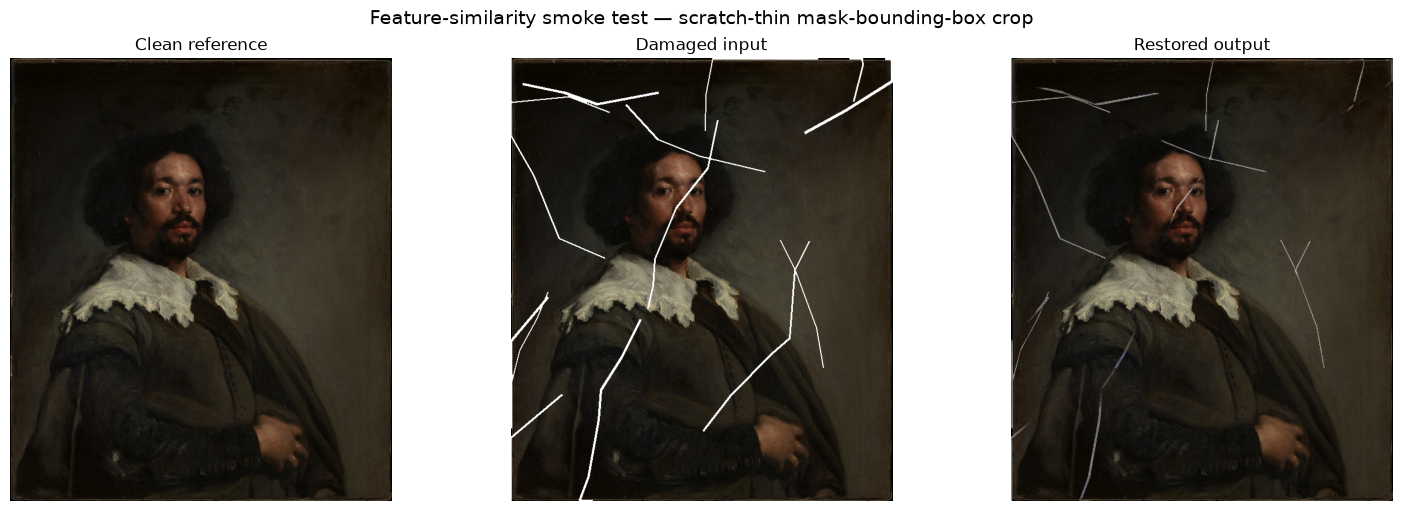

,metric_row_id,case_id,candidate_id,model_id,metric_family,metric_name,feature_model_id,region_id,region_pixel_count,region_width,...,preprocessing_id,input_size,model_name,model_revision,model_checksum,schema_version,device,package_version,status,issue
0,fm__44d1573d88d1d0f41633,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,feature_similarity,clip_cosine_similarity,clip_vit_b32,content_region,509184,663,...,clip_processor_native_224.v1,224,openai/clip-vit-base-patch32,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,a63082132ba4f97a80bea76823f544493bffa8082296d6...,feature_metrics.v1,cuda,4.48.3,ok,
1,fm__1400bc4ef38812c8a601,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,feature_similarity,clip_cosine_similarity,clip_vit_b32,mask_bbox_crop,509184,663,...,clip_processor_native_224.v1,224,openai/clip-vit-base-patch32,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,a63082132ba4f97a80bea76823f544493bffa8082296d6...,feature_metrics.v1,cuda,4.48.3,ok,
2,fm__fb8b8f28e9d71bd03194,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,feature_similarity,dinov2_cosine_similarity,dinov2_vits14,content_region,509184,663,...,dinov2_official_eval_224.v1,224,dinov2_vits14,facebookresearch_dinov2_main_published_checkpoint,b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d...,feature_metrics.v1,cuda,2.5.1+cu121,ok,
3,fm__025c76055f4e23e34f55,canonical__p001__scratch_thin,sd15__p00__s2026__b039817c7170,stable_diffusion_inpainting,feature_similarity,dinov2_cosine_similarity,dinov2_vits14,mask_bbox_crop,509184,663,...,dinov2_official_eval_224.v1,224,dinov2_vits14,facebookresearch_dinov2_main_published_checkpoint,b938bf1bc15cd2ec0feacfe3a1bb553fe8ea9ca46a7e1d...,feature_metrics.v1,cuda,2.5.1+cu121,ok,


Scratch-thin smoke case: canonical__p001__scratch_thin
Scratch-thin candidate: sd15__p00__s2026__b039817c7170
Crop coordinates: {'x_min': 52, 'y_min': 0, 'x_max': 715, 'y_max': 768}
Rendered crop shapes: {'Clean reference': (768, 663, 3), 'Damaged input': (768, 663, 3), 'Restored output': (768, 663, 3)}
Associated metric rows: 4


In [14]:
# Cell 17 — visually inspect the scratch-thin smoke-test crop

import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Select the scratch-thin bounding-box evaluation row
# ---------------------------------------------------------------------------

smoke_scratch_case_id = str(
    smoke_scratch_candidate_df[
        "case_id"
    ].iloc[0]
)

smoke_scratch_candidate_id = str(
    smoke_scratch_candidate_df[
        "candidate_id"
    ].iloc[0]
)

smoke_scratch_visual_rows = (
    smoke_execution_plan_df.loc[
        (
            smoke_execution_plan_df[
                "candidate_id"
            ].astype(str).eq(
                smoke_scratch_candidate_id
            )
        )
        & (
            smoke_execution_plan_df[
                "region_id"
            ].astype(str).eq(
                "mask_bbox_crop"
            )
        )
    ]
)

if len(smoke_scratch_visual_rows) != 1:
    raise ValueError(
        "Expected exactly one scratch-thin "
        "mask_bbox_crop smoke row, observed "
        f"{len(smoke_scratch_visual_rows)}."
    )

smoke_scratch_row = (
    smoke_scratch_visual_rows.iloc[0]
)


# ---------------------------------------------------------------------------
# Resolve paths and crop coordinates
# ---------------------------------------------------------------------------

def resolve_smoke_visual_path(
    path_value,
):
    visual_path = Path(str(path_value))

    if not visual_path.is_absolute():
        visual_path = (
            PROJECT_ROOT
            / visual_path
        )

    return visual_path.resolve()


crop_x_min = int(
    smoke_scratch_row["crop_x_min"]
)
crop_y_min = int(
    smoke_scratch_row["crop_y_min"]
)
crop_x_max = int(
    smoke_scratch_row["crop_x_max"]
)
crop_y_max = int(
    smoke_scratch_row["crop_y_max"]
)

visual_paths = {
    "Clean reference": (
        resolve_smoke_visual_path(
            smoke_scratch_row[
                "clean_image_path"
            ]
        )
    ),
    "Damaged input": (
        resolve_smoke_visual_path(
            smoke_scratch_row[
                "input_image_path"
            ]
        )
    ),
    "Restored output": (
        resolve_smoke_visual_path(
            smoke_scratch_row[
                "restored_path"
            ]
        )
    ),
}

missing_visual_paths = {
    label: str(path)
    for label, path in visual_paths.items()
    if not path.is_file()
}

if missing_visual_paths:
    raise FileNotFoundError(
        "Smoke visualization inputs are "
        f"missing: {missing_visual_paths}"
    )


# ---------------------------------------------------------------------------
# Load and crop the three aligned images
# ---------------------------------------------------------------------------

visual_crops = {}

for visual_label, visual_path in (
    visual_paths.items()
):
    visual_image = load_rgb_array(
        visual_path
    )

    visual_crop = visual_image[
        crop_y_min:crop_y_max,
        crop_x_min:crop_x_max,
    ]

    if visual_crop.size == 0:
        raise ValueError(
            "Smoke visualization produced an "
            f"empty crop for {visual_label!r}."
        )

    visual_crops[visual_label] = (
        visual_crop
    )


# ---------------------------------------------------------------------------
# Render the comparison
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    constrained_layout=True,
)

for axis, (
    visual_label,
    visual_crop,
) in zip(
    axes,
    visual_crops.items(),
    strict=True,
):
    axis.imshow(visual_crop)
    axis.set_title(visual_label)
    axis.axis("off")

figure.suptitle(
    (
        "Feature-similarity smoke test — "
        "scratch-thin mask-bounding-box crop"
    ),
    fontsize=14,
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------------------------
# Show the associated feature metrics
# ---------------------------------------------------------------------------

smoke_scratch_metrics_df = (
    smoke_feature_metrics_df.loc[
        smoke_feature_metrics_df[
            "candidate_id"
        ].astype(str).eq(
            smoke_scratch_candidate_id
        )
    ]
    .sort_values(
        [
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(smoke_scratch_metrics_df)

print(
    "Scratch-thin smoke case:",
    smoke_scratch_case_id,
)
print(
    "Scratch-thin candidate:",
    smoke_scratch_candidate_id,
)
print(
    "Crop coordinates:",
    {
        "x_min": crop_x_min,
        "y_min": crop_y_min,
        "x_max": crop_x_max,
        "y_max": crop_y_max,
    },
)
print(
    "Rendered crop shapes:",
    {
        label: tuple(array.shape)
        for label, array
        in visual_crops.items()
    },
)
print(
    "Associated metric rows:",
    len(smoke_scratch_metrics_df),
)

In [15]:
# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_3_smoke_test"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Loaded-model checks
# ---------------------------------------------------------------------------

add_batch_3_check(
    "models_loaded",
    (
        "Both pinned feature models loaded "
        "successfully."
    ),
    set(FEATURE_MODEL_IDS),
    set(feature_model_bundles),
    (
        set(feature_model_bundles)
        == set(FEATURE_MODEL_IDS)
    ),
)

add_batch_3_check(
    "models_in_eval_mode",
    (
        "Both feature models are in "
        "inference/evaluation mode."
    ),
    False,
    loaded_models_df[
        "training_mode"
    ].any(),
    (
        not loaded_models_df[
            "training_mode"
        ].any()
    ),
)

expected_embedding_dimensions = {
    feature_model_id: (
        MODEL_SPECS[
            feature_model_id
        ].embedding_dimension
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

observed_embedding_dimensions = {
    feature_model_id: int(
        smoke_embedding_arrays[
            MODEL_SPECS[
                feature_model_id
            ].array_name
        ].shape[1]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_3_check(
    "embedding_dimensions",
    (
        "Smoke embeddings have the approved "
        "CLIP and DINOv2 dimensions."
    ),
    expected_embedding_dimensions,
    observed_embedding_dimensions,
    (
        observed_embedding_dimensions
        == expected_embedding_dimensions
    ),
)


# ---------------------------------------------------------------------------
# Smoke scope and scientific invariants
# ---------------------------------------------------------------------------

add_batch_3_check(
    "smoke_candidate_count",
    (
        "The smoke scope contains exactly "
        "two candidates."
    ),
    2,
    len(smoke_worklist_df),
    len(smoke_worklist_df) == 2,
)

add_batch_3_check(
    "smoke_candidate_region_count",
    (
        "The zero and scratch candidates produce "
        "exactly three region evaluations."
    ),
    3,
    len(smoke_execution_plan_df),
    len(smoke_execution_plan_df) == 3,
)

add_batch_3_check(
    "zero_control_bbox_omitted",
    (
        "The zero-control candidate has no "
        "mask-bounding-box region."
    ),
    0,
    int(
        smoke_execution_plan_df.loc[
            smoke_execution_plan_df[
                "is_zero_control"
            ].astype(bool),
            "region_id",
        ].eq(
            "mask_bbox_crop"
        ).sum()
    ),
    (
        smoke_execution_plan_df.loc[
            smoke_execution_plan_df[
                "is_zero_control"
            ].astype(bool),
            "region_id",
        ].eq(
            "mask_bbox_crop"
        ).sum()
        == 0
    ),
)

add_batch_3_check(
    "smoke_embedding_count",
    (
        "The smoke test retains exactly "
        "sixteen deduplicated embeddings."
    ),
    16,
    len(smoke_embedding_manifest_df),
    len(smoke_embedding_manifest_df) == 16,
)

add_batch_3_check(
    "smoke_embedding_status",
    (
        "Every smoke embedding completed "
        "successfully."
    ),
    0,
    int(
        smoke_embedding_manifest_df[
            "status"
        ].ne("ok").sum()
    ),
    (
        smoke_embedding_manifest_df[
            "status"
        ].eq("ok").all()
    ),
)

add_batch_3_check(
    "smoke_embedding_validation",
    (
        "Smoke embedding matrices and manifest "
        "pass scientific validation."
    ),
    True,
    smoke_embedding_validation["passed"],
    smoke_embedding_validation["passed"],
    details=str(
        smoke_embedding_validation
    ),
)

add_batch_3_check(
    "smoke_metric_count",
    (
        "Two feature models across three region "
        "evaluations produce six metric rows."
    ),
    6,
    len(smoke_feature_metrics_df),
    len(smoke_feature_metrics_df) == 6,
)

add_batch_3_check(
    "smoke_metric_status",
    (
        "Every smoke metric row completed "
        "successfully."
    ),
    0,
    int(
        smoke_feature_metrics_df[
            "status"
        ].ne("ok").sum()
    ),
    (
        smoke_feature_metrics_df[
            "status"
        ].eq("ok").all()
    ),
)

add_batch_3_check(
    "smoke_metric_validation",
    (
        "Smoke cosine metrics pass key, bound, "
        "arithmetic, and zero-control validation."
    ),
    True,
    smoke_metric_validation["passed"],
    smoke_metric_validation["passed"],
    details=str(
        smoke_metric_validation
    ),
)

smoke_norm_failures = 0

for matrix in (
    smoke_embedding_arrays.values()
):
    norms = np.linalg.norm(
        matrix,
        axis=1,
    )

    smoke_norm_failures += int(
        (
            np.abs(norms - 1.0)
            > FEATURE_CONFIG[
                "finite_value_policy"
            ][
                "normalized_embedding_norm_tolerance"
            ]
        ).sum()
    )

add_batch_3_check(
    "smoke_embeddings_normalized",
    (
        "Every smoke embedding is L2-normalized "
        "within the approved tolerance."
    ),
    0,
    smoke_norm_failures,
    smoke_norm_failures == 0,
)


# ---------------------------------------------------------------------------
# Filesystem scope
# ---------------------------------------------------------------------------

smoke_work_files = sorted(
    path
    for path in SMOKE_WORK_ROOT.rglob("*")
    if path.is_file()
)

smoke_scope_errors = []

for path in smoke_work_files:
    try:
        path.resolve().relative_to(
            (
                NOTEBOOK_OUTPUT_ROOT
                / "work"
            ).resolve()
        )
    except ValueError:
        smoke_scope_errors.append(
            str(path)
        )

add_batch_3_check(
    "smoke_files_owned_by_work",
    (
        "All smoke artifacts remain under the "
        "Notebook 15 work directory."
    ),
    [],
    smoke_scope_errors,
    not smoke_scope_errors,
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in (
        OUTPUTS.items()
    )
    if output_path.exists()
}

add_batch_3_check(
    "no_premature_canonical_outputs",
    (
        "The smoke test has not persisted any "
        "canonical Notebook 15 artifact."
    ),
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_3_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_3_validation_df.loc[
        batch_3_validation_df[
            "validation_stage"
        ].eq(
            "batch_3_smoke_test"
        )
    ]
)

VALIDATION.raise_for_blocking()

print("Batch 3 smoke test passed.")
print(
    "Batch 3 checks:",
    int(
        batch_3_validation_df[
            "validation_stage"
        ].eq(
            "batch_3_smoke_test"
        ).sum()
    ),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Model-load seconds:",
    round(model_load_seconds, 3),
)
print(
    "Smoke embeddings:",
    len(smoke_embedding_manifest_df),
)
print(
    "Smoke metric rows:",
    len(smoke_feature_metrics_df),
)
print(
    "Smoke work files:",
    len(smoke_work_files),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
127,batch_3_smoke_test,models_loaded,Both pinned feature models loaded successfully.,blocking,"""{'dinov2_vits14', 'clip_vit_b32'}""","""{'dinov2_vits14', 'clip_vit_b32'}""",True,
128,batch_3_smoke_test,models_in_eval_mode,Both feature models are in inference/evaluatio...,blocking,False,False,True,
129,batch_3_smoke_test,embedding_dimensions,Smoke embeddings have the approved CLIP and DI...,blocking,"{""clip_vit_b32"": 512, ""dinov2_vits14"": 384}","{""clip_vit_b32"": 512, ""dinov2_vits14"": 384}",True,
130,batch_3_smoke_test,smoke_candidate_count,The smoke scope contains exactly two candidates.,blocking,2,2,True,
131,batch_3_smoke_test,smoke_candidate_region_count,The zero and scratch candidates produce exactl...,blocking,3,3,True,
132,batch_3_smoke_test,zero_control_bbox_omitted,The zero-control candidate has no mask-boundin...,blocking,0,0,True,
133,batch_3_smoke_test,smoke_embedding_count,The smoke test retains exactly sixteen dedupli...,blocking,16,16,True,
134,batch_3_smoke_test,smoke_embedding_status,Every smoke embedding completed successfully.,blocking,0,0,True,
135,batch_3_smoke_test,smoke_embedding_validation,Smoke embedding matrices and manifest pass sci...,blocking,True,True,True,{'schema': {'schema_name': 'feature_embedding_...
136,batch_3_smoke_test,smoke_metric_count,Two feature models across three region evaluat...,blocking,6,6,True,


Batch 3 smoke test passed.
Batch 3 checks: 15
Cumulative blocking failures: 0
Model-load seconds: 14.67
Smoke embeddings: 16
Smoke metric rows: 6
Smoke work files: 4


## Batch 4 — Full checkpointed embedding extraction and feature metrics

This batch executes the approved full feature-similarity scope:

- 2,160 restoration candidates;
- 4,170 candidate-region evaluations;
- 5,350 deduplicated embeddings per feature model;
- 10,700 retained embeddings in total;
- 4,170 CLIP metric rows;
- 4,170 DINOv2 metric rows;
- 8,340 feature-metric rows in total.

Extraction is resumable. Each feature model uses a fixed-shape NumPy checkpoint matrix under the notebook-owned `work/embedding_matrices/` directory. A combined checkpoint manifest records completed embeddings and is written atomically with Windows lock recovery.

Rerunning this batch reuses only embeddings whose identifier, array index, model revision, model checksum, preprocessing identifier, status, and stored vector satisfy the approved contract.

No canonical Notebook 15 output is persisted in this batch.

In [16]:
# ---------------------------------------------------------------------------
# Full-run checkpoint paths
# ---------------------------------------------------------------------------

FULL_CHECKPOINT_PATH = (
    WORK_PATHS["checkpoint_manifest"]
)

FULL_MATRIX_DIRECTORY = (
    WORK_PATHS[
        "checkpoint_matrix_directory"
    ]
)

FULL_MATRIX_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FULL_MATRIX_PATHS = {
    feature_model_id: (
        FULL_MATRIX_DIRECTORY
        / (
            MODEL_SPECS[
                feature_model_id
            ].array_name
            + ".npy"
        )
    )
    for feature_model_id in FEATURE_MODEL_IDS
}


# ---------------------------------------------------------------------------
# Inspect any resumable state
# ---------------------------------------------------------------------------

(
    prior_full_checkpoint_df,
    prior_full_checkpoint_path,
) = load_latest_embedding_checkpoint(
    FULL_CHECKPOINT_PATH
)

planned_embedding_ids = set(
    feature_embedding_plan_df[
        "embedding_id"
    ].astype(str)
)

prior_checkpoint_duplicate_ids = int(
    prior_full_checkpoint_df[
        "embedding_id"
    ].astype(str).duplicated(
        keep=False
    ).sum()
)

prior_checkpoint_unexpected_ids = sorted(
    set(
        prior_full_checkpoint_df[
            "embedding_id"
        ].astype(str)
    )
    - planned_embedding_ids
)

if prior_checkpoint_duplicate_ids:
    raise ValueError(
        "The full embedding checkpoint contains "
        f"{prior_checkpoint_duplicate_ids} rows "
        "with duplicated embedding IDs."
    )

if prior_checkpoint_unexpected_ids:
    raise ValueError(
        "The full embedding checkpoint contains "
        "IDs outside the current approved plan: "
        f"{prior_checkpoint_unexpected_ids[:10]}"
    )

prior_checkpoint_summary_records = []

for feature_model_id in FEATURE_MODEL_IDS:
    prior_model_rows = (
        prior_full_checkpoint_df.loc[
            prior_full_checkpoint_df[
                "feature_model_id"
            ].astype(str).eq(
                feature_model_id
            )
        ]
    )

    prior_checkpoint_summary_records.append(
        {
            "feature_model_id": (
                feature_model_id
            ),
            "checkpoint_rows": len(
                prior_model_rows
            ),
            "ok_rows": int(
                prior_model_rows[
                    "status"
                ].astype(str).eq("ok").sum()
            ),
            "error_rows": int(
                prior_model_rows[
                    "status"
                ].astype(str).eq(
                    "error"
                ).sum()
            ),
            "matrix_path": str(
                FULL_MATRIX_PATHS[
                    feature_model_id
                ]
            ),
            "matrix_exists": (
                FULL_MATRIX_PATHS[
                    feature_model_id
                ].is_file()
            ),
        }
    )

prior_checkpoint_summary_df = (
    pd.DataFrame(
        prior_checkpoint_summary_records
    )
)

display(prior_checkpoint_summary_df)

print("Full checkpoint state inspected.")
print(
    "Latest checkpoint:",
    (
        str(prior_full_checkpoint_path)
        if prior_full_checkpoint_path
        is not None
        else "none"
    ),
)
print(
    "Prior checkpoint rows:",
    len(prior_full_checkpoint_df),
)
print(
    "Prior completed rows:",
    int(
        prior_full_checkpoint_df[
            "status"
        ].astype(str).eq("ok").sum()
    ),
)
print(
    "Planned embedding rows:",
    len(feature_embedding_plan_df),
)

,feature_model_id,checkpoint_rows,ok_rows,error_rows,matrix_path,matrix_exists
0,clip_vit_b32,0,0,0,D:\Masters\FH\Thesis\painting-restoration-eval...,False
1,dinov2_vits14,0,0,0,D:\Masters\FH\Thesis\painting-restoration-eval...,False


Full checkpoint state inspected.
Latest checkpoint: none
Prior checkpoint rows: 0
Prior completed rows: 0
Planned embedding rows: 10700


In [17]:
# ---------------------------------------------------------------------------
# Combined checkpoint writer
# ---------------------------------------------------------------------------

full_checkpoint_write_events = []

feature_model_order = {
    feature_model_id: position
    for position, feature_model_id
    in enumerate(FEATURE_MODEL_IDS)
}


def write_combined_full_checkpoint(
    current_model_id,
    current_manifest_df,
):
    (
        latest_checkpoint_df,
        latest_checkpoint_path,
    ) = load_latest_embedding_checkpoint(
        FULL_CHECKPOINT_PATH
    )

    retained_checkpoint_df = (
        latest_checkpoint_df.loc[
            ~latest_checkpoint_df[
                "feature_model_id"
            ].astype(str).eq(
                current_model_id
            )
        ]
    )

    combined_checkpoint_df = (
        pd.concat(
            [
                retained_checkpoint_df,
                current_manifest_df,
            ],
            ignore_index=True,
        )
    )

    combined_checkpoint_df[
        "_feature_model_order"
    ] = (
        combined_checkpoint_df[
            "feature_model_id"
        ].map(feature_model_order)
    )

    combined_checkpoint_df = (
        combined_checkpoint_df
        .sort_values(
            [
                "_feature_model_order",
                "array_index",
            ],
            kind="stable",
        )
        .drop(
            columns=[
                "_feature_model_order",
            ]
        )
        .reset_index(drop=True)
    )

    write_result = (
        write_embedding_checkpoint_manifest(
            combined_checkpoint_df,
            FULL_CHECKPOINT_PATH,
        )
    )

    full_checkpoint_write_events.append(
        {
            "feature_model_id": (
                current_model_id
            ),
            "manifest_rows": len(
                combined_checkpoint_df
            ),
            "completed_rows": int(
                combined_checkpoint_df[
                    "status"
                ].astype(str).eq("ok").sum()
            ),
            "write_status": (
                write_result["status"]
            ),
            "written_path": str(
                write_result["path"]
            ),
            "attempts": int(
                write_result["attempts"]
            ),
            "previous_checkpoint_path": (
                str(latest_checkpoint_path)
                if latest_checkpoint_path
                is not None
                else ""
            ),
        }
    )

    if write_result["status"] != "canonical":
        print(
            "Checkpoint recovery file used:",
            write_result["path"],
        )

    return write_result


# ---------------------------------------------------------------------------
# Full extraction
# ---------------------------------------------------------------------------

if resolved_device == "cuda":
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

full_extraction_started = time.perf_counter()

full_embedding_results = {}
full_embedding_manifest_frames = []
full_embedding_arrays = {}
full_embedding_run_summary_records = []

for feature_model_id in FEATURE_MODEL_IDS:
    model_bundle = feature_model_bundles[
        feature_model_id
    ]

    model_spec = model_bundle["spec"]

    (
        latest_prior_manifest_df,
        latest_prior_manifest_path,
    ) = load_latest_embedding_checkpoint(
        FULL_CHECKPOINT_PATH
    )

    def full_encode_batch(
        images,
        bundle=model_bundle,
    ):
        return encode_feature_batch(
            images,
            bundle,
            device=resolved_device,
        )

    def full_checkpoint_callback(
        manifest_df,
        matrix,
        current_model_id=feature_model_id,
    ):
        return write_combined_full_checkpoint(
            current_model_id,
            manifest_df,
        )

    print()
    print(
        "Starting or resuming:",
        feature_model_id,
    )
    print(
        "Prior checkpoint:",
        (
            str(latest_prior_manifest_path)
            if latest_prior_manifest_path
            is not None
            else "none"
        ),
    )
    print(
        "Matrix path:",
        FULL_MATRIX_PATHS[
            feature_model_id
        ],
    )

    model_result = (
        extract_feature_model_embeddings(
            feature_embedding_plan_df,
            spec=model_spec,
            encode_batch=full_encode_batch,
            project_root=PROJECT_ROOT,
            config=feature_similarity_config,
            matrix_path=(
                FULL_MATRIX_PATHS[
                    feature_model_id
                ]
            ),
            prior_manifest=(
                latest_prior_manifest_df
            ),
            progress_callback=print,
            checkpoint_callback=(
                full_checkpoint_callback
            ),
        )
    )

    full_embedding_results[
        feature_model_id
    ] = model_result

    full_embedding_manifest_frames.append(
        model_result.manifest
    )

    full_embedding_arrays[
        model_spec.array_name
    ] = model_result.matrix

    full_embedding_run_summary_records.append(
        dict(model_result.summary)
    )

    print(
        "Completed model:",
        feature_model_id,
    )
    print(
        "Completed embeddings:",
        model_result.summary[
            "completed_count"
        ],
    )
    print(
        "Reused embeddings:",
        model_result.summary[
            "reused_count"
        ],
    )
    print(
        "New embeddings:",
        model_result.summary[
            "new_count"
        ],
    )
    print(
        "Runtime seconds:",
        round(
            model_result.summary[
                "runtime_seconds"
            ],
            3,
        ),
    )


# ---------------------------------------------------------------------------
# Normalize final manifest order
# ---------------------------------------------------------------------------

full_embedding_manifest_df = (
    pd.concat(
        full_embedding_manifest_frames,
        ignore_index=True,
    )
)

full_embedding_manifest_df[
    "_feature_model_order"
] = (
    full_embedding_manifest_df[
        "feature_model_id"
    ].map(feature_model_order)
)

full_embedding_manifest_df = (
    full_embedding_manifest_df
    .sort_values(
        [
            "_feature_model_order",
            "array_index",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_feature_model_order",
        ]
    )
    .reset_index(drop=True)
)

final_checkpoint_write_result = (
    write_embedding_checkpoint_manifest(
        full_embedding_manifest_df,
        FULL_CHECKPOINT_PATH,
    )
)

full_embedding_run_summary_df = (
    pd.DataFrame(
        full_embedding_run_summary_records
    )
)

full_extraction_seconds = (
    time.perf_counter()
    - full_extraction_started
)

FULL_EXTRACTION_COMPLETED_AT_UTC = (
    utc_now_iso()
)

if resolved_device == "cuda":
    full_extraction_gpu_peak_bytes = int(
        torch.cuda.max_memory_allocated()
    )
else:
    full_extraction_gpu_peak_bytes = 0

display(full_embedding_run_summary_df)

print("Full embedding extraction complete.")
print(
    "Embedding manifest rows:",
    len(full_embedding_manifest_df),
)
print(
    "Completed rows:",
    int(
        full_embedding_manifest_df[
            "status"
        ].astype(str).eq("ok").sum()
    ),
)
print(
    "Error rows:",
    int(
        full_embedding_manifest_df[
            "status"
        ].astype(str).eq(
            "error"
        ).sum()
    ),
)
print(
    "Full extraction seconds:",
    round(full_extraction_seconds, 3),
)
print(
    "CUDA peak memory bytes:",
    full_extraction_gpu_peak_bytes,
)
print(
    "Final checkpoint status:",
    final_checkpoint_write_result[
        "status"
    ],
)
print(
    "Final checkpoint path:",
    final_checkpoint_write_result[
        "path"
    ],
)


Starting or resuming: clip_vit_b32
Prior checkpoint: none
Matrix path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity\work\embedding_matrices\clip_embeddings.npy


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algo

clip_vit_b32: 128/5350 embeddings (2.4%), elapsed=9.4s, throughput=13.66 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__ae6f3550d1b78f190a06


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algo

clip_vit_b32: 224/5350 embeddings (4.2%), elapsed=16.9s, throughput=13.24 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__d792700250ecb1b095b4


...

clip_vit_b32: 5312/5350 embeddings (99.3%), elapsed=373.9s, throughput=14.21 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__58a69f873b7273ad063d


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torch\nn\modules\linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algo

clip_vit_b32: 5350/5350 embeddings (100.0%), elapsed=376.3s, throughput=14.22 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__2c49c39d4a6e70045aa5
Completed model: clip_vit_b32
Completed embeddings: 5350
Reused embeddings: 0
New embeddings: 5350
Runtime seconds: 376.337

Starting or resuming: dinov2_vits14
Prior checkpoint: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity\work\embedding_checkpoint.csv
Matrix path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity\work\embedding_matrices\dinov2_embeddings.npy
dinov2_vits14: 128/5350 embeddings (2.4%), elapsed=7.2s, throughput=17.80 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__bda5bb636df6d0673d4c
dinov2_vits14: 224/5350 embeddings (4.2%), elapsed=12.6s, throughput=17.73 new embeddings/s, batch_size=32, reused=0, failures=0, latest=fe__f61cc396c2a85cc9472c
dinov2_vits14: 320/5350 embeddings (6.0%), elapsed=18.2s, throughput=17.54 new embeddings/

,feature_model_id,embedding_count,completed_count,error_count,reused_count,new_count,final_batch_size,runtime_seconds
0,clip_vit_b32,5350,5350,0,0,5350,32,376.337037
1,dinov2_vits14,5350,5350,0,0,5350,32,292.734974


Full embedding extraction complete.
Embedding manifest rows: 10700
Completed rows: 10700
Error rows: 0
Full extraction seconds: 669.634
CUDA peak memory bytes: 863747584
Final checkpoint status: canonical
Final checkpoint path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity\work\embedding_checkpoint.csv


In [18]:
# ---------------------------------------------------------------------------
# Construct normalized feature metrics
# ---------------------------------------------------------------------------

full_metric_construction_started = (
    time.perf_counter()
)

full_feature_metrics_df = (
    construct_feature_metrics(
        feature_execution_plan_df,
        full_embedding_manifest_df,
        full_embedding_arrays,
        config=feature_similarity_config,
        device=resolved_device,
        package_versions={
            "transformers": (
                get_package_version(
                    "transformers"
                )
            ),
            "torch": torch.__version__,
        },
    )
)

full_metric_construction_seconds = (
    time.perf_counter()
    - full_metric_construction_started
)

FULL_METRICS_COMPLETED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Immediate full-run validation
# ---------------------------------------------------------------------------

full_embedding_validation = (
    validate_feature_embedding_manifest(
        full_embedding_manifest_df,
        full_embedding_arrays,
        config=feature_similarity_config,
        expected_plan=(
            feature_embedding_plan_df
        ),
    )
)

full_metric_validation = (
    validate_feature_metrics(
        full_feature_metrics_df,
        feature_execution_plan_df,
        full_embedding_manifest_df,
        config=feature_similarity_config,
    )
)


# ---------------------------------------------------------------------------
# Compact execution summaries
# ---------------------------------------------------------------------------

full_metric_model_summary_df = (
    full_feature_metrics_df
    .groupby(
        [
            "feature_model_id",
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        completed_rows=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("ok")
                .sum()
            ),
        ),
        mean_damaged_similarity=(
            "damaged_value",
            "mean",
        ),
        mean_restored_similarity=(
            "restored_value",
            "mean",
        ),
        mean_improvement=(
            "improvement_value",
            "mean",
        ),
    )
    .sort_values(
        [
            "feature_model_id",
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

full_embedding_model_summary_df = (
    full_embedding_manifest_df
    .groupby(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        embedding_rows=(
            "embedding_id",
            "size",
        ),
        completed_rows=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("ok")
                .sum()
            ),
        ),
    )
    .sort_values(
        [
            "feature_model_id",
            "image_role",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(full_embedding_model_summary_df)
display(full_metric_model_summary_df)

print("Full feature metrics constructed.")
print(
    "Feature metric rows:",
    len(full_feature_metrics_df),
)
print(
    "Completed metric rows:",
    int(
        full_feature_metrics_df[
            "status"
        ].astype(str).eq("ok").sum()
    ),
)
print(
    "Metric error rows:",
    int(
        full_feature_metrics_df[
            "status"
        ].astype(str).eq(
            "error"
        ).sum()
    ),
)
print(
    "Metric construction seconds:",
    round(
        full_metric_construction_seconds,
        3,
    ),
)
print(
    "Embedding validation passed:",
    full_embedding_validation["passed"],
)
print(
    "Metric validation passed:",
    full_metric_validation["passed"],
)

,feature_model_id,image_role,region_id,embedding_rows,completed_rows
0,clip_vit_b32,clean,content_region,50,50
1,clip_vit_b32,clean,mask_bbox_crop,360,360
2,clip_vit_b32,damaged,content_region,410,410
3,clip_vit_b32,damaged,mask_bbox_crop,360,360
4,clip_vit_b32,restored,content_region,2160,2160
5,clip_vit_b32,restored,mask_bbox_crop,2010,2010
6,dinov2_vits14,clean,content_region,50,50
7,dinov2_vits14,clean,mask_bbox_crop,360,360
8,dinov2_vits14,damaged,content_region,410,410
9,dinov2_vits14,damaged,mask_bbox_crop,360,360


,feature_model_id,model_id,region_id,metric_rows,completed_rows,mean_damaged_similarity,mean_restored_similarity,mean_improvement
0,clip_vit_b32,lama,content_region,410,410,0.897545,0.981882,0.084336
1,clip_vit_b32,lama,mask_bbox_crop,360,360,0.837928,0.956540,0.118612
2,clip_vit_b32,opencv_telea,content_region,410,410,0.897545,0.950285,0.052740
3,clip_vit_b32,opencv_telea,mask_bbox_crop,360,360,0.837928,0.886278,0.048350
4,clip_vit_b32,sdxl_inpainting,content_region,10,10,0.912923,0.847067,-0.065856
5,clip_vit_b32,sdxl_inpainting,mask_bbox_crop,10,10,0.890324,0.823591,-0.066733
6,clip_vit_b32,stable_diffusion_inpainting,content_region,1330,1330,0.898275,0.964926,0.066651
7,clip_vit_b32,stable_diffusion_inpainting,mask_bbox_crop,1280,1280,0.859523,0.945222,0.085699
8,dinov2_vits14,lama,content_region,410,410,0.908158,0.963384,0.055226
9,dinov2_vits14,lama,mask_bbox_crop,360,360,0.769105,0.871590,0.102486


Full feature metrics constructed.
Feature metric rows: 8340
Completed metric rows: 8340
Metric error rows: 0
Metric construction seconds: 28.223
Embedding validation passed: True
Metric validation passed: True


In [19]:
# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_4_full_execution"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Embedding coverage and integrity
# ---------------------------------------------------------------------------

add_batch_4_check(
    "full_embedding_count",
    (
        "The full manifest contains exactly "
        "10,700 deduplicated embeddings."
    ),
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
    len(full_embedding_manifest_df),
    (
        len(full_embedding_manifest_df)
        == EXPECTED_COUNTS[
            "total_embedding_rows"
        ]
    ),
)

observed_embeddings_per_model = (
    full_embedding_manifest_df
    .groupby("feature_model_id")
    .size()
    .to_dict()
)

expected_embeddings_per_model = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "embeddings_per_feature_model"
        ]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_4_check(
    "full_embeddings_per_model",
    (
        "CLIP and DINOv2 each retain exactly "
        "5,350 embeddings."
    ),
    expected_embeddings_per_model,
    observed_embeddings_per_model,
    (
        observed_embeddings_per_model
        == expected_embeddings_per_model
    ),
)

embedding_error_count = int(
    full_embedding_manifest_df[
        "status"
    ].astype(str).ne("ok").sum()
)

add_batch_4_check(
    "full_embedding_status",
    (
        "Every planned embedding completed "
        "successfully."
    ),
    0,
    embedding_error_count,
    embedding_error_count == 0,
)

add_batch_4_check(
    "full_embedding_validation",
    (
        "The complete embedding manifest and "
        "both matrices pass scientific validation."
    ),
    True,
    full_embedding_validation["passed"],
    full_embedding_validation["passed"],
    details=str(
        full_embedding_validation
    ),
)

observed_matrix_shapes = {
    feature_model_id: tuple(
        full_embedding_arrays[
            MODEL_SPECS[
                feature_model_id
            ].array_name
        ].shape
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

expected_matrix_shapes = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "embeddings_per_feature_model"
        ],
        MODEL_SPECS[
            feature_model_id
        ].embedding_dimension,
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_4_check(
    "full_matrix_shapes",
    (
        "Both checkpoint matrices have their "
        "exact approved dimensions."
    ),
    expected_matrix_shapes,
    observed_matrix_shapes,
    (
        observed_matrix_shapes
        == expected_matrix_shapes
    ),
)

observed_matrix_dtypes = {
    feature_model_id: str(
        full_embedding_arrays[
            MODEL_SPECS[
                feature_model_id
            ].array_name
        ].dtype
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

expected_matrix_dtypes = {
    feature_model_id: "float32"
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_4_check(
    "full_matrix_dtypes",
    (
        "Both embedding matrices use float32."
    ),
    expected_matrix_dtypes,
    observed_matrix_dtypes,
    (
        observed_matrix_dtypes
        == expected_matrix_dtypes
    ),
)


# ---------------------------------------------------------------------------
# Metric coverage and integrity
# ---------------------------------------------------------------------------

add_batch_4_check(
    "full_metric_count",
    (
        "The complete normalized metric table "
        "contains exactly 8,340 rows."
    ),
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(full_feature_metrics_df),
    (
        len(full_feature_metrics_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

observed_metrics_per_feature_model = (
    full_feature_metrics_df
    .groupby("feature_model_id")
    .size()
    .to_dict()
)

expected_metrics_per_feature_model = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "metric_rows_per_feature_model"
        ]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_4_check(
    "full_metrics_per_feature_model",
    (
        "CLIP and DINOv2 each contribute exactly "
        "4,170 metric rows."
    ),
    expected_metrics_per_feature_model,
    observed_metrics_per_feature_model,
    (
        observed_metrics_per_feature_model
        == expected_metrics_per_feature_model
    ),
)

observed_metrics_per_restoration_model = (
    full_feature_metrics_df
    .groupby("model_id")
    .size()
    .to_dict()
)

add_batch_4_check(
    "full_metrics_per_restoration_model",
    (
        "Metric rows match the approved coverage "
        "for every restoration model."
    ),
    EXPECTED_COUNTS[
        "metric_rows_by_restoration_model"
    ],
    observed_metrics_per_restoration_model,
    (
        observed_metrics_per_restoration_model
        == EXPECTED_COUNTS[
            "metric_rows_by_restoration_model"
        ]
    ),
)

metric_error_count = int(
    full_feature_metrics_df[
        "status"
    ].astype(str).ne("ok").sum()
)

add_batch_4_check(
    "full_metric_status",
    (
        "Every feature-metric row completed "
        "successfully."
    ),
    0,
    metric_error_count,
    metric_error_count == 0,
)

metric_duplicate_id_count = int(
    full_feature_metrics_df[
        "metric_row_id"
    ].astype(str).duplicated(
        keep=False
    ).sum()
)

add_batch_4_check(
    "full_metric_ids_unique",
    (
        "Every feature-metric row identifier "
        "is unique."
    ),
    0,
    metric_duplicate_id_count,
    metric_duplicate_id_count == 0,
)

metric_embedding_reference_columns = [
    "clean_embedding_id",
    "damaged_embedding_id",
    "restored_embedding_id",
]

metric_embedding_reference_count = int(
    full_feature_metrics_df[
        metric_embedding_reference_columns
    ].notna().to_numpy().sum()
)

add_batch_4_check(
    "metric_embedding_reference_count",
    (
        "Every metric row records clean, damaged, "
        "and restored embedding references."
    ),
    EXPECTED_COUNTS[
        "metric_embedding_references"
    ],
    metric_embedding_reference_count,
    (
        metric_embedding_reference_count
        == EXPECTED_COUNTS[
            "metric_embedding_references"
        ]
    ),
)

add_batch_4_check(
    "full_metric_validation",
    (
        "The complete metric table passes schema, "
        "coverage, bounds, arithmetic, reference, "
        "and zero-control validation."
    ),
    True,
    full_metric_validation["passed"],
    full_metric_validation["passed"],
    details=str(
        full_metric_validation
    ),
)


# ---------------------------------------------------------------------------
# Resume checkpoint and ownership
# ---------------------------------------------------------------------------

(
    reloaded_full_checkpoint_df,
    reloaded_full_checkpoint_path,
) = load_latest_embedding_checkpoint(
    FULL_CHECKPOINT_PATH
)

checkpoint_id_coverage_matches = (
    set(
        reloaded_full_checkpoint_df[
            "embedding_id"
        ].astype(str)
    )
    == set(
        full_embedding_manifest_df[
            "embedding_id"
        ].astype(str)
    )
)

add_batch_4_check(
    "full_checkpoint_coverage",
    (
        "The latest resumable checkpoint contains "
        "the complete embedding-ID universe."
    ),
    True,
    checkpoint_id_coverage_matches,
    checkpoint_id_coverage_matches,
    details=str(
        reloaded_full_checkpoint_path
    ),
)

checkpoint_matrix_files_exist = {
    feature_model_id: (
        FULL_MATRIX_PATHS[
            feature_model_id
        ].is_file()
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_4_check(
    "checkpoint_matrix_files",
    (
        "Both model-specific checkpoint matrices "
        "exist in the Notebook 15 work directory."
    ),
    {
        feature_model_id: True
        for feature_model_id
        in FEATURE_MODEL_IDS
    },
    checkpoint_matrix_files_exist,
    all(
        checkpoint_matrix_files_exist.values()
    ),
)

full_work_scope_errors = []

for work_path in (
    FULL_CHECKPOINT_PATH,
    *FULL_MATRIX_PATHS.values(),
):
    try:
        work_path.resolve().relative_to(
            (
                NOTEBOOK_OUTPUT_ROOT
                / "work"
            ).resolve()
        )
    except ValueError:
        full_work_scope_errors.append(
            str(work_path)
        )

add_batch_4_check(
    "full_work_files_owned",
    (
        "All full-run checkpoint paths are owned "
        "by the Notebook 15 work directory."
    ),
    [],
    full_work_scope_errors,
    not full_work_scope_errors,
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path
    in OUTPUTS.items()
    if output_path.exists()
}

add_batch_4_check(
    "no_premature_canonical_outputs",
    (
        "The full execution has not persisted "
        "canonical Notebook 15 artifacts."
    ),
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_4_validation_df = (
    VALIDATION.to_dataframe()
)

display(
    batch_4_validation_df.loc[
        batch_4_validation_df[
            "validation_stage"
        ].eq(
            "batch_4_full_execution"
        )
    ]
)

VALIDATION.raise_for_blocking()

print("Batch 4 full execution passed.")
print(
    "Batch 4 checks:",
    int(
        batch_4_validation_df[
            "validation_stage"
        ].eq(
            "batch_4_full_execution"
        ).sum()
    ),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Retained embeddings:",
    len(full_embedding_manifest_df),
)
print(
    "Feature metric rows:",
    len(full_feature_metrics_df),
)
print(
    "Full extraction seconds:",
    round(full_extraction_seconds, 3),
)
print(
    "Metric construction seconds:",
    round(
        full_metric_construction_seconds,
        3,
    ),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
142,batch_4_full_execution,full_embedding_count,"The full manifest contains exactly 10,700 dedu...",blocking,10700,10700,True,
143,batch_4_full_execution,full_embeddings_per_model,"CLIP and DINOv2 each retain exactly 5,350 embe...",blocking,"{""clip_vit_b32"": 5350, ""dinov2_vits14"": 5350}","{""clip_vit_b32"": 5350, ""dinov2_vits14"": 5350}",True,
144,batch_4_full_execution,full_embedding_status,Every planned embedding completed successfully.,blocking,0,0,True,
145,batch_4_full_execution,full_embedding_validation,The complete embedding manifest and both matri...,blocking,True,True,True,{'schema': {'schema_name': 'feature_embedding_...
146,batch_4_full_execution,full_matrix_shapes,Both checkpoint matrices have their exact appr...,blocking,"{""clip_vit_b32"": [5350, 512], ""dinov2_vits14"":...","{""clip_vit_b32"": [5350, 512], ""dinov2_vits14"":...",True,
147,batch_4_full_execution,full_matrix_dtypes,Both embedding matrices use float32.,blocking,"{""clip_vit_b32"": ""float32"", ""dinov2_vits14"": ""...","{""clip_vit_b32"": ""float32"", ""dinov2_vits14"": ""...",True,
148,batch_4_full_execution,full_metric_count,The complete normalized metric table contains ...,blocking,8340,8340,True,
149,batch_4_full_execution,full_metrics_per_feature_model,"CLIP and DINOv2 each contribute exactly 4,170 ...",blocking,"{""clip_vit_b32"": 4170, ""dinov2_vits14"": 4170}","{""clip_vit_b32"": 4170, ""dinov2_vits14"": 4170}",True,
150,batch_4_full_execution,full_metrics_per_restoration_model,Metric rows match the approved coverage for ev...,blocking,"{""lama"": 1540, ""opencv_telea"": 1540, ""sdxl_inp...","{""lama"": 1540, ""opencv_telea"": 1540, ""sdxl_inp...",True,
151,batch_4_full_execution,full_metric_status,Every feature-metric row completed successfully.,blocking,0,0,True,


Batch 4 full execution passed.
Batch 4 checks: 17
Cumulative blocking failures: 0
Retained embeddings: 10700
Feature metric rows: 8340
Full extraction seconds: 669.634
Metric construction seconds: 28.223


## Batch 5 — Scientific and paired scratch-prompt validation

This batch performs deeper validation of the complete in-memory feature evidence.

It verifies:

- exact alignment between metric rows and the candidate-region execution plan;
- deterministic metric-row identifiers;
- frozen model, revision, checksum, preprocessing, package, device, metric, region-policy, and schema provenance;
- finite cosine similarities within their theoretical bounds;
- exact restored-minus-damaged improvement arithmetic;
- shared damaged-baseline invariance across restoration models, prompts, and seeds;
- identity behavior for all zero-control candidates;
- complete two-region and two-encoder coverage for every non-zero candidate;
- retention of both positive and negative restoration outcomes;
- complete generic-versus-scratch-aware Stable Diffusion pairing across 50 paintings, four seeds, two regions, and two feature models.

The scratch-prompt result is descriptive. Its direction does not determine candidate inclusion or validation success.

CUDA feature extraction used PyTorch's best-effort deterministic mode. CuBLAS reported that exact bitwise repeatability is not guaranteed without process-start workspace configuration. This limitation is recorded transparently as non-blocking validation evidence.

No canonical Notebook 15 artifact is persisted in this batch.

In [20]:
from restoration_eval.metrics_feature_similarity import (
    build_scratch_prompt_pairs,
    metric_row_id,
)


# ---------------------------------------------------------------------------
# Join candidate metadata onto every metric row
# ---------------------------------------------------------------------------

candidate_metadata_columns = [
    "candidate_id",
    "case_id",
    "model_id",
    "painting_id",
    "seed",
    "prompt_variant_id",
    "damage_or_degradation_type",
    "is_zero_control",
]

candidate_metadata_df = (
    evaluation_worklist_df[
        candidate_metadata_columns
    ]
    .copy()
)

feature_analysis_df = (
    full_feature_metrics_df.merge(
        candidate_metadata_df,
        on=[
            "candidate_id",
            "case_id",
            "model_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

candidate_metadata_missing_count = int(
    feature_analysis_df[
        "painting_id"
    ].isna().sum()
)


# ---------------------------------------------------------------------------
# Align metric keys and geometry with the execution plan
# ---------------------------------------------------------------------------

feature_model_axis_df = pd.DataFrame(
    {
        "feature_model_id": list(
            FEATURE_MODEL_IDS
        )
    }
)

expected_metric_plan_df = (
    feature_execution_plan_df[
        [
            "candidate_id",
            "region_id",
            "case_id",
            "model_id",
            "painting_id",
            "region_pixel_count",
            "region_width",
            "region_height",
            "is_zero_control",
        ]
    ]
    .merge(
        feature_model_axis_df,
        how="cross",
    )
)

observed_metric_plan_df = (
    feature_analysis_df[
        [
            "candidate_id",
            "region_id",
            "feature_model_id",
            "case_id",
            "model_id",
            "painting_id",
            "region_pixel_count",
            "region_width",
            "region_height",
            "is_zero_control",
        ]
    ]
    .copy()
)

metric_plan_keys = [
    "candidate_id",
    "region_id",
    "feature_model_id",
]

metric_plan_alignment_df = (
    expected_metric_plan_df.merge(
        observed_metric_plan_df,
        on=metric_plan_keys,
        how="outer",
        suffixes=(
            "_expected",
            "_observed",
        ),
        indicator=True,
        validate="one_to_one",
    )
)

metric_plan_geometry_fields = [
    "case_id",
    "model_id",
    "painting_id",
    "region_pixel_count",
    "region_width",
    "region_height",
    "is_zero_control",
]

metric_plan_geometry_mismatch_count = 0

for field_name in (
    metric_plan_geometry_fields
):
    expected_values = (
        metric_plan_alignment_df[
            f"{field_name}_expected"
        ].astype(str)
    )

    observed_values = (
        metric_plan_alignment_df[
            f"{field_name}_observed"
        ].astype(str)
    )

    metric_plan_geometry_mismatch_count += int(
        expected_values.ne(
            observed_values
        ).sum()
    )


# ---------------------------------------------------------------------------
# Deterministic row identities
# ---------------------------------------------------------------------------

expected_metric_row_ids = [
    metric_row_id(
        str(row.case_id),
        str(row.candidate_id),
        str(row.feature_model_id),
        str(row.region_id),
    )
    for row in full_feature_metrics_df.itertuples(
        index=False
    )
]

metric_row_id_mismatch_count = int(
    (
        full_feature_metrics_df[
            "metric_row_id"
        ].astype(str).to_numpy()
        != np.asarray(
            expected_metric_row_ids,
            dtype=object,
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Frozen provenance
# ---------------------------------------------------------------------------

expected_package_versions = {
    "clip_vit_b32": get_package_version(
        "transformers"
    ),
    "dinov2_vits14": torch.__version__,
}

metric_provenance_failure_count = 0
metric_provenance_records = []

for feature_model_id in FEATURE_MODEL_IDS:
    model_rows = (
        full_feature_metrics_df.loc[
            full_feature_metrics_df[
                "feature_model_id"
            ].astype(str).eq(
                feature_model_id
            )
        ]
    )

    model_spec = MODEL_SPECS[
        feature_model_id
    ]

    expected_provenance = {
        "metric_family": (
            "feature_similarity"
        ),
        "metric_name": (
            model_spec.metric_name
        ),
        "metric_version": (
            FEATURE_METRIC_VERSION
        ),
        "region_policy_version": (
            FEATURE_CONFIG[
                "regions"
            ][
                "policy_version"
            ]
        ),
        "preprocessing_id": (
            model_spec.preprocessing_id
        ),
        "input_size": (
            model_spec.input_size
        ),
        "model_name": (
            model_spec.model_name
        ),
        "model_revision": (
            model_spec.model_revision
        ),
        "model_checksum": (
            model_spec.model_checksum
        ),
        "schema_version": (
            FEATURE_METRICS_SCHEMA_VERSION
        ),
        "device": resolved_device,
        "package_version": (
            expected_package_versions[
                feature_model_id
            ]
        ),
    }

    for field_name, expected_value in (
        expected_provenance.items()
    ):
        mismatch_count = int(
            model_rows[
                field_name
            ].astype(str).ne(
                str(expected_value)
            ).sum()
        )

        metric_provenance_failure_count += (
            mismatch_count
        )

        metric_provenance_records.append(
            {
                "feature_model_id": (
                    feature_model_id
                ),
                "field": field_name,
                "expected": str(
                    expected_value
                ),
                "mismatch_count": (
                    mismatch_count
                ),
            }
        )

metric_provenance_df = pd.DataFrame(
    metric_provenance_records
)


# ---------------------------------------------------------------------------
# Numerical validity
# ---------------------------------------------------------------------------

metric_numeric_columns = [
    "damaged_value",
    "restored_value",
    "improvement_value",
]

metric_numeric_array = (
    full_feature_metrics_df[
        metric_numeric_columns
    ].to_numpy(dtype=float)
)

non_finite_metric_value_count = int(
    (~np.isfinite(metric_numeric_array)).sum()
)

cosine_minimum = float(
    FEATURE_CONFIG[
        "finite_value_policy"
    ][
        "cosine_minimum"
    ]
)

cosine_maximum = float(
    FEATURE_CONFIG[
        "finite_value_policy"
    ][
        "cosine_maximum"
    ]
)

cosine_values = (
    full_feature_metrics_df[
        [
            "damaged_value",
            "restored_value",
        ]
    ].to_numpy(dtype=float)
)

cosine_bound_failure_count = int(
    (
        (cosine_values < cosine_minimum)
        | (cosine_values > cosine_maximum)
    ).sum()
)

improvement_tolerance = float(
    FEATURE_CONFIG[
        "finite_value_policy"
    ][
        "improvement_tolerance"
    ]
)

improvement_arithmetic_error = (
    full_feature_metrics_df[
        "restored_value"
    ].astype(float)
    - full_feature_metrics_df[
        "damaged_value"
    ].astype(float)
    - full_feature_metrics_df[
        "improvement_value"
    ].astype(float)
).abs()

improvement_arithmetic_failure_count = int(
    improvement_arithmetic_error.gt(
        improvement_tolerance
    ).sum()
)


# ---------------------------------------------------------------------------
# Damaged-baseline invariance
# ---------------------------------------------------------------------------

damaged_baseline_invariance_df = (
    full_feature_metrics_df
    .groupby(
        [
            "case_id",
            "region_id",
            "feature_model_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        damaged_embedding_ids=(
            "damaged_embedding_id",
            "nunique",
        ),
        damaged_value_minimum=(
            "damaged_value",
            "min",
        ),
        damaged_value_maximum=(
            "damaged_value",
            "max",
        ),
    )
)

damaged_baseline_invariance_df[
    "damaged_value_spread"
] = (
    damaged_baseline_invariance_df[
        "damaged_value_maximum"
    ]
    - damaged_baseline_invariance_df[
        "damaged_value_minimum"
    ]
)

damaged_embedding_identity_failure_count = int(
    damaged_baseline_invariance_df[
        "damaged_embedding_ids"
    ].ne(1).sum()
)

maximum_damaged_baseline_spread = float(
    damaged_baseline_invariance_df[
        "damaged_value_spread"
    ].max()
)


# ---------------------------------------------------------------------------
# Zero controls
# ---------------------------------------------------------------------------

zero_control_metrics_df = (
    feature_analysis_df.loc[
        feature_analysis_df[
            "is_zero_control"
        ].astype(bool)
    ]
    .copy()
)

zero_control_tolerance = float(
    FEATURE_CONFIG[
        "finite_value_policy"
    ][
        "zero_control_tolerance"
    ]
)

zero_control_damaged_deviation = (
    zero_control_metrics_df[
        "damaged_value"
    ].astype(float).sub(1.0).abs()
)

zero_control_restored_deviation = (
    zero_control_metrics_df[
        "restored_value"
    ].astype(float).sub(1.0).abs()
)

zero_control_improvement_deviation = (
    zero_control_metrics_df[
        "improvement_value"
    ].astype(float).abs()
)

zero_control_maximum_deviation = float(
    max(
        zero_control_damaged_deviation.max(),
        zero_control_restored_deviation.max(),
        zero_control_improvement_deviation.max(),
    )
)

zero_control_rows_by_feature_model = {
    str(key): int(value)
    for key, value in (
        zero_control_metrics_df[
            "feature_model_id"
        ].value_counts().items()
    )
}

zero_control_rows_by_restoration_model = {
    str(key): int(value)
    for key, value in (
        zero_control_metrics_df[
            "model_id"
        ].value_counts().items()
    )
}


# ---------------------------------------------------------------------------
# Non-zero candidate coverage
# ---------------------------------------------------------------------------

nonzero_metrics_df = (
    feature_analysis_df.loc[
        ~feature_analysis_df[
            "is_zero_control"
        ].astype(bool)
    ]
    .copy()
)

nonzero_candidate_coverage_df = (
    nonzero_metrics_df
    .groupby(
        "candidate_id",
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        regions=(
            "region_id",
            "nunique",
        ),
        feature_models=(
            "feature_model_id",
            "nunique",
        ),
    )
)

invalid_nonzero_candidate_coverage = int(
    (
        nonzero_candidate_coverage_df[
            "metric_rows"
        ].ne(4)
        | nonzero_candidate_coverage_df[
            "regions"
        ].ne(2)
        | nonzero_candidate_coverage_df[
            "feature_models"
        ].ne(2)
    ).sum()
)

display(metric_provenance_df)
display(
    damaged_baseline_invariance_df.head(
        10
    )
)
display(
    nonzero_candidate_coverage_df.head(
        10
    )
)

print("Scientific alignment evidence constructed.")
print(
    "Metric-plan alignment states:",
    metric_plan_alignment_df[
        "_merge"
    ].value_counts().to_dict(),
)
print(
    "Geometry mismatches:",
    metric_plan_geometry_mismatch_count,
)
print(
    "Deterministic ID mismatches:",
    metric_row_id_mismatch_count,
)
print(
    "Provenance mismatches:",
    metric_provenance_failure_count,
)
print(
    "Non-finite numeric values:",
    non_finite_metric_value_count,
)
print(
    "Cosine-bound failures:",
    cosine_bound_failure_count,
)
print(
    "Improvement arithmetic failures:",
    improvement_arithmetic_failure_count,
)
print(
    "Maximum damaged-baseline spread:",
    maximum_damaged_baseline_spread,
)
print(
    "Zero-control metric rows:",
    len(zero_control_metrics_df),
)
print(
    "Zero-control maximum deviation:",
    zero_control_maximum_deviation,
)
print(
    "Invalid non-zero candidate coverage:",
    invalid_nonzero_candidate_coverage,
)

,feature_model_id,field,expected,mismatch_count
0,clip_vit_b32,metric_family,feature_similarity,0
1,clip_vit_b32,metric_name,clip_cosine_similarity,0
2,clip_vit_b32,metric_version,feature_cosine_similarity.v1,0
3,clip_vit_b32,region_policy_version,evaluation_region_policy.v1,0
4,clip_vit_b32,preprocessing_id,clip_processor_native_224.v1,0
5,clip_vit_b32,input_size,224,0
6,clip_vit_b32,model_name,openai/clip-vit-base-patch32,0
7,clip_vit_b32,model_revision,3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268,0
8,clip_vit_b32,model_checksum,a63082132ba4f97a80bea76823f544493bffa8082296d6...,0
9,clip_vit_b32,schema_version,feature_metrics.v1,0


,case_id,region_id,feature_model_id,metric_rows,damaged_embedding_ids,damaged_value_minimum,damaged_value_maximum,damaged_value_spread
0,canonical__p001__loss_large,content_region,clip_vit_b32,4,1,0.645271,0.645271,0.0
1,canonical__p001__loss_large,content_region,dinov2_vits14,4,1,0.875033,0.875033,0.0
2,canonical__p001__loss_large,mask_bbox_crop,clip_vit_b32,4,1,0.544499,0.544499,0.0
3,canonical__p001__loss_large,mask_bbox_crop,dinov2_vits14,4,1,0.369869,0.369869,0.0
4,canonical__p001__loss_small,content_region,clip_vit_b32,3,1,0.934952,0.934952,0.0
5,canonical__p001__loss_small,content_region,dinov2_vits14,3,1,0.919474,0.919474,0.0
6,canonical__p001__loss_small,mask_bbox_crop,clip_vit_b32,3,1,0.954186,0.954186,0.0
7,canonical__p001__loss_small,mask_bbox_crop,dinov2_vits14,3,1,0.963984,0.963984,0.0
8,canonical__p001__mixed_damage,content_region,clip_vit_b32,7,1,0.849283,0.849283,0.0
9,canonical__p001__mixed_damage,content_region,dinov2_vits14,7,1,0.820756,0.820756,0.0


,candidate_id,metric_rows,regions,feature_models
0,candidate__lama__canonical__p001__loss_large__c00,4,2,2
1,candidate__lama__canonical__p001__loss_small__c00,4,2,2
2,candidate__lama__canonical__p001__mixed_damage...,4,2,2
3,candidate__lama__canonical__p001__scratch_thin...,4,2,2
4,candidate__lama__canonical__p002__loss_large__c00,4,2,2
5,candidate__lama__canonical__p002__loss_small__c00,4,2,2
6,candidate__lama__canonical__p002__mixed_damage...,4,2,2
7,candidate__lama__canonical__p002__scratch_thin...,4,2,2
8,candidate__lama__canonical__p003__loss_large__c00,4,2,2
9,candidate__lama__canonical__p003__loss_small__c00,4,2,2


Scientific alignment evidence constructed.
Metric-plan alignment states: {'both': 8340, 'left_only': 0, 'right_only': 0}
Geometry mismatches: 0
Deterministic ID mismatches: 0
Provenance mismatches: 0
Non-finite numeric values: 0
Cosine-bound failures: 0
Improvement arithmetic failures: 0
Maximum damaged-baseline spread: 0.0
Zero-control metric rows: 300
Zero-control maximum deviation: 2.384185791015625e-07
Invalid non-zero candidate coverage: 0


In [21]:
# ---------------------------------------------------------------------------
# Exact generic-versus-scratch-aware pairs
# ---------------------------------------------------------------------------

scratch_prompt_pairs_df = (
    build_scratch_prompt_pairs(
        full_feature_metrics_df,
        evaluation_worklist_df,
        config=feature_similarity_config,
    )
)

scratch_pair_key_columns = [
    "case_id",
    "painting_id",
    "seed",
    "region_id",
    "feature_model_id",
]

scratch_pair_duplicate_count = int(
    scratch_prompt_pairs_df.duplicated(
        scratch_pair_key_columns,
        keep=False,
    ).sum()
)

scratch_pair_non_finite_count = int(
    (
        ~np.isfinite(
            scratch_prompt_pairs_df[
                [
                    "generic_improvement_value",
                    "scratch_aware_improvement_value",
                    "scratch_aware_minus_generic",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Coverage by painting, seed, region, and feature model
# ---------------------------------------------------------------------------

scratch_painting_coverage_df = (
    scratch_prompt_pairs_df
    .groupby(
        "painting_id",
        as_index=False,
    )
    .agg(
        paired_rows=(
            "case_id",
            "size",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        seeds=(
            "seed",
            "nunique",
        ),
        regions=(
            "region_id",
            "nunique",
        ),
        feature_models=(
            "feature_model_id",
            "nunique",
        ),
    )
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

invalid_scratch_painting_coverage = int(
    (
        scratch_painting_coverage_df[
            "paired_rows"
        ].ne(16)
        | scratch_painting_coverage_df[
            "cases"
        ].ne(1)
        | scratch_painting_coverage_df[
            "seeds"
        ].ne(4)
        | scratch_painting_coverage_df[
            "regions"
        ].ne(2)
        | scratch_painting_coverage_df[
            "feature_models"
        ].ne(2)
    ).sum()
)


# ---------------------------------------------------------------------------
# Descriptive paired-ablation summary
# ---------------------------------------------------------------------------

def count_positive_deltas(values):
    return int(
        (
            np.asarray(
                values,
                dtype=float,
            )
            > improvement_tolerance
        ).sum()
    )


def count_tied_deltas(values):
    return int(
        (
            np.abs(
                np.asarray(
                    values,
                    dtype=float,
                )
            )
            <= improvement_tolerance
        ).sum()
    )


def count_negative_deltas(values):
    return int(
        (
            np.asarray(
                values,
                dtype=float,
            )
            < -improvement_tolerance
        ).sum()
    )


scratch_prompt_summary_df = (
    scratch_prompt_pairs_df
    .groupby(
        [
            "feature_model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        paired_comparisons=(
            "scratch_aware_minus_generic",
            "size",
        ),
        mean_generic_improvement=(
            "generic_improvement_value",
            "mean",
        ),
        median_generic_improvement=(
            "generic_improvement_value",
            "median",
        ),
        mean_scratch_aware_improvement=(
            "scratch_aware_improvement_value",
            "mean",
        ),
        median_scratch_aware_improvement=(
            "scratch_aware_improvement_value",
            "median",
        ),
        mean_paired_delta=(
            "scratch_aware_minus_generic",
            "mean",
        ),
        median_paired_delta=(
            "scratch_aware_minus_generic",
            "median",
        ),
        scratch_aware_wins=(
            "scratch_aware_minus_generic",
            count_positive_deltas,
        ),
        ties=(
            "scratch_aware_minus_generic",
            count_tied_deltas,
        ),
        generic_wins=(
            "scratch_aware_minus_generic",
            count_negative_deltas,
        ),
    )
    .sort_values(
        [
            "feature_model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

scratch_prompt_summary_df[
    "scratch_aware_win_rate"
] = (
    scratch_prompt_summary_df[
        "scratch_aware_wins"
    ]
    / scratch_prompt_summary_df[
        "paired_comparisons"
    ]
)

scratch_prompt_overall_summary_df = (
    scratch_prompt_pairs_df
    .groupby(
        "feature_model_id",
        as_index=False,
    )
    .agg(
        paired_comparisons=(
            "scratch_aware_minus_generic",
            "size",
        ),
        mean_paired_delta=(
            "scratch_aware_minus_generic",
            "mean",
        ),
        median_paired_delta=(
            "scratch_aware_minus_generic",
            "median",
        ),
        scratch_aware_wins=(
            "scratch_aware_minus_generic",
            count_positive_deltas,
        ),
        ties=(
            "scratch_aware_minus_generic",
            count_tied_deltas,
        ),
        generic_wins=(
            "scratch_aware_minus_generic",
            count_negative_deltas,
        ),
    )
    .sort_values(
        "feature_model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

scratch_prompt_overall_summary_df[
    "scratch_aware_win_rate"
] = (
    scratch_prompt_overall_summary_df[
        "scratch_aware_wins"
    ]
    / scratch_prompt_overall_summary_df[
        "paired_comparisons"
    ]
)

display(scratch_prompt_summary_df)
display(scratch_prompt_overall_summary_df)
display(scratch_painting_coverage_df)

print("Scratch-prompt paired evidence constructed.")
print(
    "Paired comparisons:",
    len(scratch_prompt_pairs_df),
)
print(
    "Unique paintings:",
    scratch_prompt_pairs_df[
        "painting_id"
    ].nunique(),
)
print(
    "Unique seeds:",
    scratch_prompt_pairs_df[
        "seed"
    ].nunique(),
)
print(
    "Duplicate pair keys:",
    scratch_pair_duplicate_count,
)
print(
    "Non-finite paired values:",
    scratch_pair_non_finite_count,
)
print(
    "Invalid painting-level coverage:",
    invalid_scratch_painting_coverage,
)

,feature_model_id,region_id,paired_comparisons,mean_generic_improvement,median_generic_improvement,mean_scratch_aware_improvement,median_scratch_aware_improvement,mean_paired_delta,median_paired_delta,scratch_aware_wins,ties,generic_wins,scratch_aware_win_rate
0,clip_vit_b32,content_region,200,0.076252,0.067207,0.075768,0.067552,-0.000484,-0.000067,90,1,109,0.450
1,clip_vit_b32,mask_bbox_crop,200,0.076232,0.066902,0.075645,0.066604,-0.000587,-0.000067,87,1,112,0.435
2,dinov2_vits14,content_region,200,0.032549,0.023710,0.031290,0.024961,-0.001259,-0.000277,91,1,108,0.455
3,dinov2_vits14,mask_bbox_crop,200,0.033507,0.023333,0.032806,0.024961,-0.000701,-0.000091,97,1,102,0.485


,feature_model_id,paired_comparisons,mean_paired_delta,median_paired_delta,scratch_aware_wins,ties,generic_wins,scratch_aware_win_rate
0,clip_vit_b32,400,-0.000535,-0.000067,177,2,221,0.4425
1,dinov2_vits14,400,-0.000980,-0.000180,188,2,210,0.4700


,painting_id,paired_rows,cases,seeds,regions,feature_models
0,p001,16,1,4,2,2
1,p002,16,1,4,2,2
2,p003,16,1,4,2,2
3,p004,16,1,4,2,2
4,p005,16,1,4,2,2
5,p006,16,1,4,2,2
6,p007,16,1,4,2,2
7,p008,16,1,4,2,2
8,p009,16,1,4,2,2
9,p010,16,1,4,2,2


Scratch-prompt paired evidence constructed.
Paired comparisons: 800
Unique paintings: 50
Unique seeds: 4
Duplicate pair keys: 0
Non-finite paired values: 0
Invalid painting-level coverage: 0


In [23]:
# ---------------------------------------------------------------------------
# Make Batch 5 validation safely rerunnable
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_5_scientific_validation"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_5_scientific_validation"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Alignment and provenance
# ---------------------------------------------------------------------------

add_batch_5_check(
    "candidate_metadata_join",
    (
        "Every metric row joins to exactly one "
        "normalized candidate."
    ),
    0,
    candidate_metadata_missing_count,
    candidate_metadata_missing_count == 0,
)

observed_alignment_states = {
    str(key): int(value)
    for key, value in (
        metric_plan_alignment_df[
            "_merge"
        ].value_counts().items()
    )
    if int(value) > 0
}

add_batch_5_check(
    "metric_plan_key_alignment",
    (
        "Metric rows and candidate-region/model "
        "plan rows have identical keys."
    ),
    {
        "both": EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    },
    observed_alignment_states,
    (
        observed_alignment_states
        == {
            "both": EXPECTED_COUNTS[
                "total_metric_rows"
            ]
        }
    ),
)

add_batch_5_check(
    "metric_plan_geometry",
    (
        "Every metric row retains its planned "
        "case, model, painting, region, geometry, "
        "and control status."
    ),
    0,
    metric_plan_geometry_mismatch_count,
    metric_plan_geometry_mismatch_count == 0,
)

add_batch_5_check(
    "deterministic_metric_row_ids",
    (
        "Every metric-row ID matches its "
        "deterministic identity fields."
    ),
    0,
    metric_row_id_mismatch_count,
    metric_row_id_mismatch_count == 0,
)

add_batch_5_check(
    "frozen_metric_provenance",
    (
        "Every metric row retains its exact "
        "approved model and software provenance."
    ),
    0,
    metric_provenance_failure_count,
    metric_provenance_failure_count == 0,
    details=str(
        metric_provenance_df.to_dict(
            "records"
        )
    ),
)


# ---------------------------------------------------------------------------
# Numerical validity
# ---------------------------------------------------------------------------

add_batch_5_check(
    "finite_metric_values",
    (
        "Every completed cosine similarity and "
        "improvement value is finite."
    ),
    0,
    non_finite_metric_value_count,
    non_finite_metric_value_count == 0,
)

add_batch_5_check(
    "cosine_similarity_bounds",
    (
        "All damaged and restored cosine "
        "similarities remain within tolerance "
        "of [-1, 1]."
    ),
    0,
    cosine_bound_failure_count,
    cosine_bound_failure_count == 0,
)

add_batch_5_check(
    "improvement_arithmetic",
    (
        "Improvement equals restored similarity "
        "minus damaged similarity."
    ),
    0,
    improvement_arithmetic_failure_count,
    improvement_arithmetic_failure_count == 0,
)

add_batch_5_check(
    "damaged_embedding_invariance",
    (
        "Each case-region-model baseline uses "
        "one damaged embedding."
    ),
    0,
    damaged_embedding_identity_failure_count,
    damaged_embedding_identity_failure_count == 0,
)

add_batch_5_check(
    "damaged_value_invariance",
    (
        "Damaged similarity remains invariant "
        "across restoration models, prompts, "
        "and seeds."
    ),
    (
        f"<= {improvement_tolerance}"
    ),
    maximum_damaged_baseline_spread,
    (
        maximum_damaged_baseline_spread
        <= improvement_tolerance
    ),
)


# ---------------------------------------------------------------------------
# Zero-control and non-zero coverage
# ---------------------------------------------------------------------------

expected_zero_metric_rows = (
    EXPECTED_COUNTS[
        "zero_control_candidates"
    ]
    * len(FEATURE_MODEL_IDS)
)

add_batch_5_check(
    "zero_control_metric_rows",
    (
        "The 150 zero-control candidates produce "
        "300 content-region feature rows."
    ),
    expected_zero_metric_rows,
    len(zero_control_metrics_df),
    (
        len(zero_control_metrics_df)
        == expected_zero_metric_rows
    ),
)

add_batch_5_check(
    "zero_control_regions",
    (
        "Zero controls contain only "
        "content-region evidence."
    ),
    {
        "content_region",
    },
    set(
        zero_control_metrics_df[
            "region_id"
        ].astype(str)
    ),
    (
        set(
            zero_control_metrics_df[
                "region_id"
            ].astype(str)
        )
        == {
            "content_region",
        }
    ),
)

expected_zero_rows_by_feature_model = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_5_check(
    "zero_control_feature_models",
    (
        "Each feature model retains all 150 "
        "zero-control candidates."
    ),
    expected_zero_rows_by_feature_model,
    zero_control_rows_by_feature_model,
    (
        zero_control_rows_by_feature_model
        == expected_zero_rows_by_feature_model
    ),
)

expected_zero_rows_by_restoration_model = {
    "opencv_telea": 100,
    "lama": 100,
    "stable_diffusion_inpainting": 100,
}

add_batch_5_check(
    "zero_control_restoration_models",
    (
        "Telea, LaMa, and Stable Diffusion each "
        "retain 50 controls in both encoders."
    ),
    expected_zero_rows_by_restoration_model,
    zero_control_rows_by_restoration_model,
    (
        zero_control_rows_by_restoration_model
        == expected_zero_rows_by_restoration_model
    ),
)

add_batch_5_check(
    "zero_control_values",
    (
        "Every zero-control damaged and restored "
        "similarity equals one and every "
        "improvement equals zero within tolerance."
    ),
    (
        f"<= {zero_control_tolerance}"
    ),
    zero_control_maximum_deviation,
    (
        zero_control_maximum_deviation
        <= zero_control_tolerance
    ),
)

add_batch_5_check(
    "nonzero_candidate_coverage",
    (
        "Every non-zero candidate has two regions "
        "and both feature models."
    ),
    0,
    invalid_nonzero_candidate_coverage,
    invalid_nonzero_candidate_coverage == 0,
)


# ---------------------------------------------------------------------------
# Scratch-prompt ablation
# ---------------------------------------------------------------------------

add_batch_5_check(
    "scratch_pair_count",
    (
        "The scratch-prompt ablation contains "
        "exactly 800 paired comparisons."
    ),
    EXPECTED_COUNTS[
        "scratch_prompt_paired_comparisons"
    ],
    len(scratch_prompt_pairs_df),
    (
        len(scratch_prompt_pairs_df)
        == EXPECTED_COUNTS[
            "scratch_prompt_paired_comparisons"
        ]
    ),
)

add_batch_5_check(
    "scratch_pair_keys_unique",
    (
        "Every case, painting, seed, region, and "
        "feature-model pair is unique."
    ),
    0,
    scratch_pair_duplicate_count,
    scratch_pair_duplicate_count == 0,
)

add_batch_5_check(
    "scratch_pair_numeric_values",
    (
        "Every paired generic, scratch-aware, "
        "and delta value is finite."
    ),
    0,
    scratch_pair_non_finite_count,
    scratch_pair_non_finite_count == 0,
)

add_batch_5_check(
    "scratch_painting_coverage",
    (
        "The ablation covers all 50 paintings."
    ),
    50,
    scratch_prompt_pairs_df[
        "painting_id"
    ].nunique(),
    (
        scratch_prompt_pairs_df[
            "painting_id"
        ].nunique()
        == 50
    ),
)

add_batch_5_check(
    "scratch_seed_coverage",
    (
        "The ablation covers all four approved "
        "Stable Diffusion seeds."
    ),
    4,
    scratch_prompt_pairs_df[
        "seed"
    ].nunique(),
    (
        scratch_prompt_pairs_df[
            "seed"
        ].nunique()
        == 4
    ),
)

add_batch_5_check(
    "scratch_painting_pair_structure",
    (
        "Every painting contains four seeds, two "
        "regions, two feature models, and sixteen "
        "paired comparison rows."
    ),
    0,
    invalid_scratch_painting_coverage,
    invalid_scratch_painting_coverage == 0,
)

scratch_summary_pair_counts = {
    (
        f"{row.feature_model_id}"
        f"|{row.region_id}"
    ): int(row.paired_comparisons)
    for row in (
        scratch_prompt_summary_df.itertuples(
            index=False
        )
    )
}

expected_scratch_summary_pair_counts = {
    (
        f"{feature_model_id}"
        f"|{region_id}"
    ): 200
    for feature_model_id in FEATURE_MODEL_IDS
    for region_id in FEATURE_ACTIVE_REGIONS
}
        
add_batch_5_check(
    "scratch_summary_group_counts",
    (
        "Each feature-model and region group "
        "contains exactly 200 prompt pairs."
    ),
    expected_scratch_summary_pair_counts,
    scratch_summary_pair_counts,
    (
        scratch_summary_pair_counts
        == expected_scratch_summary_pair_counts
    ),
)

add_batch_5_check(
    "scratch_prompt_result_descriptive",
    (
        "Scratch-aware prompt direction is "
        "reported descriptively and does not "
        "control candidate inclusion."
    ),
    "descriptive_only",
    scratch_prompt_summary_df[
        [
            "feature_model_id",
            "region_id",
            "median_paired_delta",
            "scratch_aware_win_rate",
        ]
    ].to_dict("records"),
    True,
    severity="info",
)


# ---------------------------------------------------------------------------
# Scope retention and known limitation
# ---------------------------------------------------------------------------

sdxl_metric_row_count = int(
    full_feature_metrics_df[
        "model_id"
    ].astype(str).eq(
        "sdxl_inpainting"
    ).sum()
)

add_batch_5_check(
    "sdxl_partial_scope_retained",
    (
        "The complete ten-case SDXL subset "
        "retains forty feature-metric rows."
    ),
    EXPECTED_COUNTS[
        "metric_rows_by_restoration_model"
    ][
        "sdxl_inpainting"
    ],
    sdxl_metric_row_count,
    (
        sdxl_metric_row_count
        == EXPECTED_COUNTS[
            "metric_rows_by_restoration_model"
        ][
            "sdxl_inpainting"
        ]
    ),
)

positive_improvement_rows = int(
    full_feature_metrics_df[
        "improvement_value"
    ].astype(float).gt(0).sum()
)

negative_improvement_rows = int(
    full_feature_metrics_df[
        "improvement_value"
    ].astype(float).lt(0).sum()
)

add_batch_5_check(
    "improvement_outcomes_retained",
    (
        "Both improvements and regressions remain "
        "in the complete candidate-level table."
    ),
    {
        "positive_rows": "> 0",
        "negative_rows": "> 0",
    },
    {
        "positive_rows": (
            positive_improvement_rows
        ),
        "negative_rows": (
            negative_improvement_rows
        ),
    },
    (
        positive_improvement_rows > 0
        and negative_improvement_rows > 0
    ),
)

cuda_bitwise_repeatability_claimed = (
    resolved_device != "cuda"
)

add_batch_5_check(
    "cuda_bitwise_repeatability",
    (
        "Exact bitwise repeatability is not "
        "claimed when CUDA CuBLAS reports "
        "best-effort deterministic execution."
    ),
    (
        "exact on supported kernels or "
        "explicitly documented limitation"
    ),
    (
        "best_effort_cuda_cublas"
        if resolved_device == "cuda"
        else "cpu_execution"
    ),
    cuda_bitwise_repeatability_claimed,
    details=(
        "PyTorch emitted the documented CuBLAS "
        "workspace warning during CUDA feature "
        "extraction. Metric validity and coverage "
        "are unaffected, but exact bitwise rerun "
        "identity is not asserted."
        if resolved_device == "cuda"
        else ""
    ),
    severity="warning",
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path
    in OUTPUTS.items()
    if output_path.exists()
}

add_batch_5_check(
    "no_premature_canonical_outputs",
    (
        "Scientific validation has not persisted "
        "canonical Notebook 15 artifacts."
    ),
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_5_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_5_scientific_validation"
        )
    ]
    .reset_index(drop=True)
)

display(batch_5_validation_df)

VALIDATION.raise_for_blocking()

batch_5_warning_failures = int(
    (
        batch_5_validation_df[
            "severity"
        ].eq("warning")
        & ~batch_5_validation_df[
            "passed"
        ]
    ).sum()
)

print(
    "Batch 5 blocking scientific validation passed."
)
print(
    "Batch 5 checks:",
    len(batch_5_validation_df),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Documented non-blocking warnings:",
    batch_5_warning_failures,
)
print(
    "Zero-control maximum deviation:",
    zero_control_maximum_deviation,
)
print(
    "Maximum damaged-baseline spread:",
    maximum_damaged_baseline_spread,
)
print(
    "Positive improvement rows:",
    positive_improvement_rows,
)
print(
    "Negative improvement rows:",
    negative_improvement_rows,
)
print(
    "Matched scratch-prompt comparisons:",
    len(scratch_prompt_pairs_df),
)
print("Scratch-prompt descriptive summary:")
display(scratch_prompt_summary_df)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scientific_validation,candidate_metadata_join,Every metric row joins to exactly one normaliz...,blocking,0,0,True,
1,batch_5_scientific_validation,metric_plan_key_alignment,Metric rows and candidate-region/model plan ro...,blocking,"{""both"": 8340}","{""both"": 8340}",True,
2,batch_5_scientific_validation,metric_plan_geometry,"Every metric row retains its planned case, mod...",blocking,0,0,True,
3,batch_5_scientific_validation,deterministic_metric_row_ids,Every metric-row ID matches its deterministic ...,blocking,0,0,True,
4,batch_5_scientific_validation,frozen_metric_provenance,Every metric row retains its exact approved mo...,blocking,0,0,True,"[{'feature_model_id': 'clip_vit_b32', 'field':..."
5,batch_5_scientific_validation,finite_metric_values,Every completed cosine similarity and improvem...,blocking,0,0,True,
6,batch_5_scientific_validation,cosine_similarity_bounds,All damaged and restored cosine similarities r...,blocking,0,0,True,
7,batch_5_scientific_validation,improvement_arithmetic,Improvement equals restored similarity minus d...,blocking,0,0,True,
8,batch_5_scientific_validation,damaged_embedding_invariance,Each case-region-model baseline uses one damag...,blocking,0,0,True,
9,batch_5_scientific_validation,damaged_value_invariance,Damaged similarity remains invariant across re...,blocking,<= 1e-06,0.0,True,


Batch 5 blocking scientific validation passed.
Batch 5 checks: 28
Cumulative blocking failures: 0
Documented non-blocking warnings: 1
Zero-control maximum deviation: 2.384185791015625e-07
Maximum damaged-baseline spread: 0.0
Positive improvement rows: 6107
Negative improvement rows: 1933
Matched scratch-prompt comparisons: 800
Scratch-prompt descriptive summary:


,feature_model_id,region_id,paired_comparisons,mean_generic_improvement,median_generic_improvement,mean_scratch_aware_improvement,median_scratch_aware_improvement,mean_paired_delta,median_paired_delta,scratch_aware_wins,ties,generic_wins,scratch_aware_win_rate
0,clip_vit_b32,content_region,200,0.076252,0.067207,0.075768,0.067552,-0.000484,-0.000067,90,1,109,0.450
1,clip_vit_b32,mask_bbox_crop,200,0.076232,0.066902,0.075645,0.066604,-0.000587,-0.000067,87,1,112,0.435
2,dinov2_vits14,content_region,200,0.032549,0.023710,0.031290,0.024961,-0.001259,-0.000277,91,1,108,0.455
3,dinov2_vits14,mask_bbox_crop,200,0.033507,0.023333,0.032806,0.024961,-0.000701,-0.000091,97,1,102,0.485


## Batch 6 — Feature-similarity analysis and visualization

This batch creates the single canonical Notebook 15 figure with four approved panels:

1. CLIP improvement distributions by restoration model and region;
2. DINOv2 improvement distributions by restoration model and region;
3. candidate-region agreement between CLIP and DINOv2 improvements;
4. paired scratch-aware-minus-generic Stable Diffusion prompt deltas.

Zero-control rows remain in the canonical metric table but are excluded from improvement-distribution and agreement panels because their expected identity value would create an artificial spike at zero.

All distributions remain candidate-level descriptive evidence. Stable Diffusion repeated seeds and prompts are not treated as statistically independent paintings, and the ten-case SDXL subset is shown only as limited feasibility evidence.

No additional summary CSV is created because every displayed summary can be reconstructed from the canonical feature-metric table.

In [24]:
# ---------------------------------------------------------------------------
# Candidate-level non-zero analysis scope
# ---------------------------------------------------------------------------

feature_distribution_df = (
    feature_analysis_df.loc[
        ~feature_analysis_df[
            "is_zero_control"
        ].astype(bool)
    ]
    .copy()
)

MODEL_ORDER = [
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
]

MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "stable_diffusion_inpainting": (
        "Stable Diffusion"
    ),
    "sdxl_inpainting": "SDXL",
}

REGION_ORDER = [
    "content_region",
    "mask_bbox_crop",
]

REGION_LABELS = {
    "content_region": "Content region",
    "mask_bbox_crop": "Mask-bbox crop",
}

FEATURE_MODEL_LABELS = {
    "clip_vit_b32": "CLIP ViT-B/32",
    "dinov2_vits14": "DINOv2 ViT-S/14",
}


# ---------------------------------------------------------------------------
# Distribution summary
# ---------------------------------------------------------------------------

feature_distribution_summary_df = (
    feature_distribution_df
    .groupby(
        [
            "feature_model_id",
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        candidate_rows=(
            "metric_row_id",
            "size",
        ),
        mean_improvement=(
            "improvement_value",
            "mean",
        ),
        median_improvement=(
            "improvement_value",
            "median",
        ),
        lower_quartile=(
            "improvement_value",
            lambda values: float(
                values.quantile(0.25)
            ),
        ),
        upper_quartile=(
            "improvement_value",
            lambda values: float(
                values.quantile(0.75)
            ),
        ),
        minimum_improvement=(
            "improvement_value",
            "min",
        ),
        maximum_improvement=(
            "improvement_value",
            "max",
        ),
        positive_rate=(
            "improvement_value",
            lambda values: float(
                values.astype(float)
                .gt(0)
                .mean()
            ),
        ),
        negative_rate=(
            "improvement_value",
            lambda values: float(
                values.astype(float)
                .lt(0)
                .mean()
            ),
        ),
    )
)

feature_distribution_summary_df[
    "_feature_order"
] = (
    feature_distribution_summary_df[
        "feature_model_id"
    ].map(
        {
            feature_model_id: position
            for position, feature_model_id
            in enumerate(FEATURE_MODEL_IDS)
        }
    )
)

feature_distribution_summary_df[
    "_model_order"
] = (
    feature_distribution_summary_df[
        "model_id"
    ].map(
        {
            model_id: position
            for position, model_id
            in enumerate(MODEL_ORDER)
        }
    )
)

feature_distribution_summary_df[
    "_region_order"
] = (
    feature_distribution_summary_df[
        "region_id"
    ].map(
        {
            region_id: position
            for position, region_id
            in enumerate(REGION_ORDER)
        }
    )
)

feature_distribution_summary_df = (
    feature_distribution_summary_df
    .sort_values(
        [
            "_feature_order",
            "_model_order",
            "_region_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_feature_order",
            "_model_order",
            "_region_order",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# CLIP-versus-DINOv2 agreement
# ---------------------------------------------------------------------------

feature_agreement_df = (
    feature_distribution_df.pivot(
        index=[
            "case_id",
            "candidate_id",
            "model_id",
            "region_id",
        ],
        columns="feature_model_id",
        values="improvement_value",
    )
    .reset_index()
)

feature_agreement_df.columns.name = None

required_agreement_columns = {
    "clip_vit_b32",
    "dinov2_vits14",
}

missing_agreement_columns = sorted(
    required_agreement_columns
    - set(feature_agreement_df.columns)
)

if missing_agreement_columns:
    raise ValueError(
        "Feature-agreement table is missing "
        f"columns: {missing_agreement_columns}"
    )


def feature_agreement_record(
    group_df,
):
    clip_values = group_df[
        "clip_vit_b32"
    ].astype(float)

    dino_values = group_df[
        "dinov2_vits14"
    ].astype(float)

    return pd.Series(
        {
            "candidate_region_rows": len(
                group_df
            ),
            "pearson_correlation": (
                clip_values.corr(
                    dino_values,
                    method="pearson",
                )
            ),
            "spearman_correlation": (
                clip_values.corr(
                    dino_values,
                    method="spearman",
                )
            ),
            "same_direction_rate": float(
                (
                    np.sign(clip_values)
                    == np.sign(dino_values)
                ).mean()
            ),
        }
    )


feature_agreement_summary_df = (
    feature_agreement_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        sort=False,
    )
    .apply(
        feature_agreement_record,
        include_groups=False,
    )
    .reset_index()
)

feature_agreement_summary_df[
    "_model_order"
] = (
    feature_agreement_summary_df[
        "model_id"
    ].map(
        {
            model_id: position
            for position, model_id
            in enumerate(MODEL_ORDER)
        }
    )
)

feature_agreement_summary_df[
    "_region_order"
] = (
    feature_agreement_summary_df[
        "region_id"
    ].map(
        {
            region_id: position
            for position, region_id
            in enumerate(REGION_ORDER)
        }
    )
)

feature_agreement_summary_df = (
    feature_agreement_summary_df
    .sort_values(
        [
            "_model_order",
            "_region_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_model_order",
            "_region_order",
        ]
    )
    .reset_index(drop=True)
)

overall_clip_dino_pearson = float(
    feature_agreement_df[
        "clip_vit_b32"
    ].corr(
        feature_agreement_df[
            "dinov2_vits14"
        ],
        method="pearson",
    )
)

overall_clip_dino_spearman = float(
    feature_agreement_df[
        "clip_vit_b32"
    ].corr(
        feature_agreement_df[
            "dinov2_vits14"
        ],
        method="spearman",
    )
)

display(feature_distribution_summary_df)
display(feature_agreement_summary_df)

print("Batch 6 analysis tables constructed.")
print(
    "Non-zero feature rows:",
    len(feature_distribution_df),
)
print(
    "Distribution summary groups:",
    len(feature_distribution_summary_df),
)
print(
    "CLIP-DINOv2 candidate-region pairs:",
    len(feature_agreement_df),
)
print(
    "Overall Pearson correlation:",
    round(
        overall_clip_dino_pearson,
        6,
    ),
)
print(
    "Overall Spearman correlation:",
    round(
        overall_clip_dino_spearman,
        6,
    ),
)

,feature_model_id,model_id,region_id,candidate_rows,mean_improvement,median_improvement,lower_quartile,upper_quartile,minimum_improvement,maximum_improvement,positive_rate,negative_rate
0,clip_vit_b32,opencv_telea,content_region,360,0.060065,0.077090,0.035481,0.123285,-0.462277,0.263223,0.855556,0.144444
1,clip_vit_b32,opencv_telea,mask_bbox_crop,360,0.048350,0.079110,0.028603,0.126740,-0.495740,0.254349,0.847222,0.152778
2,clip_vit_b32,lama,content_region,360,0.096049,0.110784,0.063798,0.154837,-0.358319,0.293581,0.891667,0.108333
3,clip_vit_b32,lama,mask_bbox_crop,360,0.118612,0.128835,0.068381,0.193576,-0.424604,0.372561,0.894444,0.105556
4,clip_vit_b32,stable_diffusion_inpainting,content_region,1280,0.069254,0.077380,0.027476,0.126853,-0.263695,0.275129,0.794531,0.205469
5,clip_vit_b32,stable_diffusion_inpainting,mask_bbox_crop,1280,0.085699,0.077934,0.028147,0.150942,-0.309729,0.413748,0.803906,0.196094
6,clip_vit_b32,sdxl_inpainting,content_region,10,-0.065856,-0.087048,-0.153806,0.064829,-0.301872,0.124728,0.300000,0.700000
7,clip_vit_b32,sdxl_inpainting,mask_bbox_crop,10,-0.066733,-0.109947,-0.162125,0.073797,-0.302990,0.142466,0.400000,0.600000
8,dinov2_vits14,opencv_telea,content_region,360,-0.022606,0.018995,-0.047020,0.068906,-0.913439,0.437422,0.622222,0.377778
9,dinov2_vits14,opencv_telea,mask_bbox_crop,360,-0.072478,0.015779,-0.126611,0.064454,-0.999844,0.486322,0.605556,0.394444


,model_id,region_id,candidate_region_rows,pearson_correlation,spearman_correlation,same_direction_rate
0,opencv_telea,content_region,360.0,0.801612,0.577203,0.750000
1,opencv_telea,mask_bbox_crop,360.0,0.865150,0.595112,0.741667
2,lama,content_region,360.0,0.706007,0.546886,0.991667
3,lama,mask_bbox_crop,360.0,0.836706,0.744665,0.994444
4,stable_diffusion_inpainting,content_region,1280.0,0.618893,0.623020,0.865625
5,stable_diffusion_inpainting,mask_bbox_crop,1280.0,0.766647,0.745362,0.866406
6,sdxl_inpainting,content_region,10.0,0.778131,0.769697,0.800000
7,sdxl_inpainting,mask_bbox_crop,10.0,0.860565,0.806061,0.800000


Batch 6 analysis tables constructed.
Non-zero feature rows: 8040
Distribution summary groups: 16
CLIP-DINOv2 candidate-region pairs: 4020
Overall Pearson correlation: 0.771833
Overall Spearman correlation: 0.684732


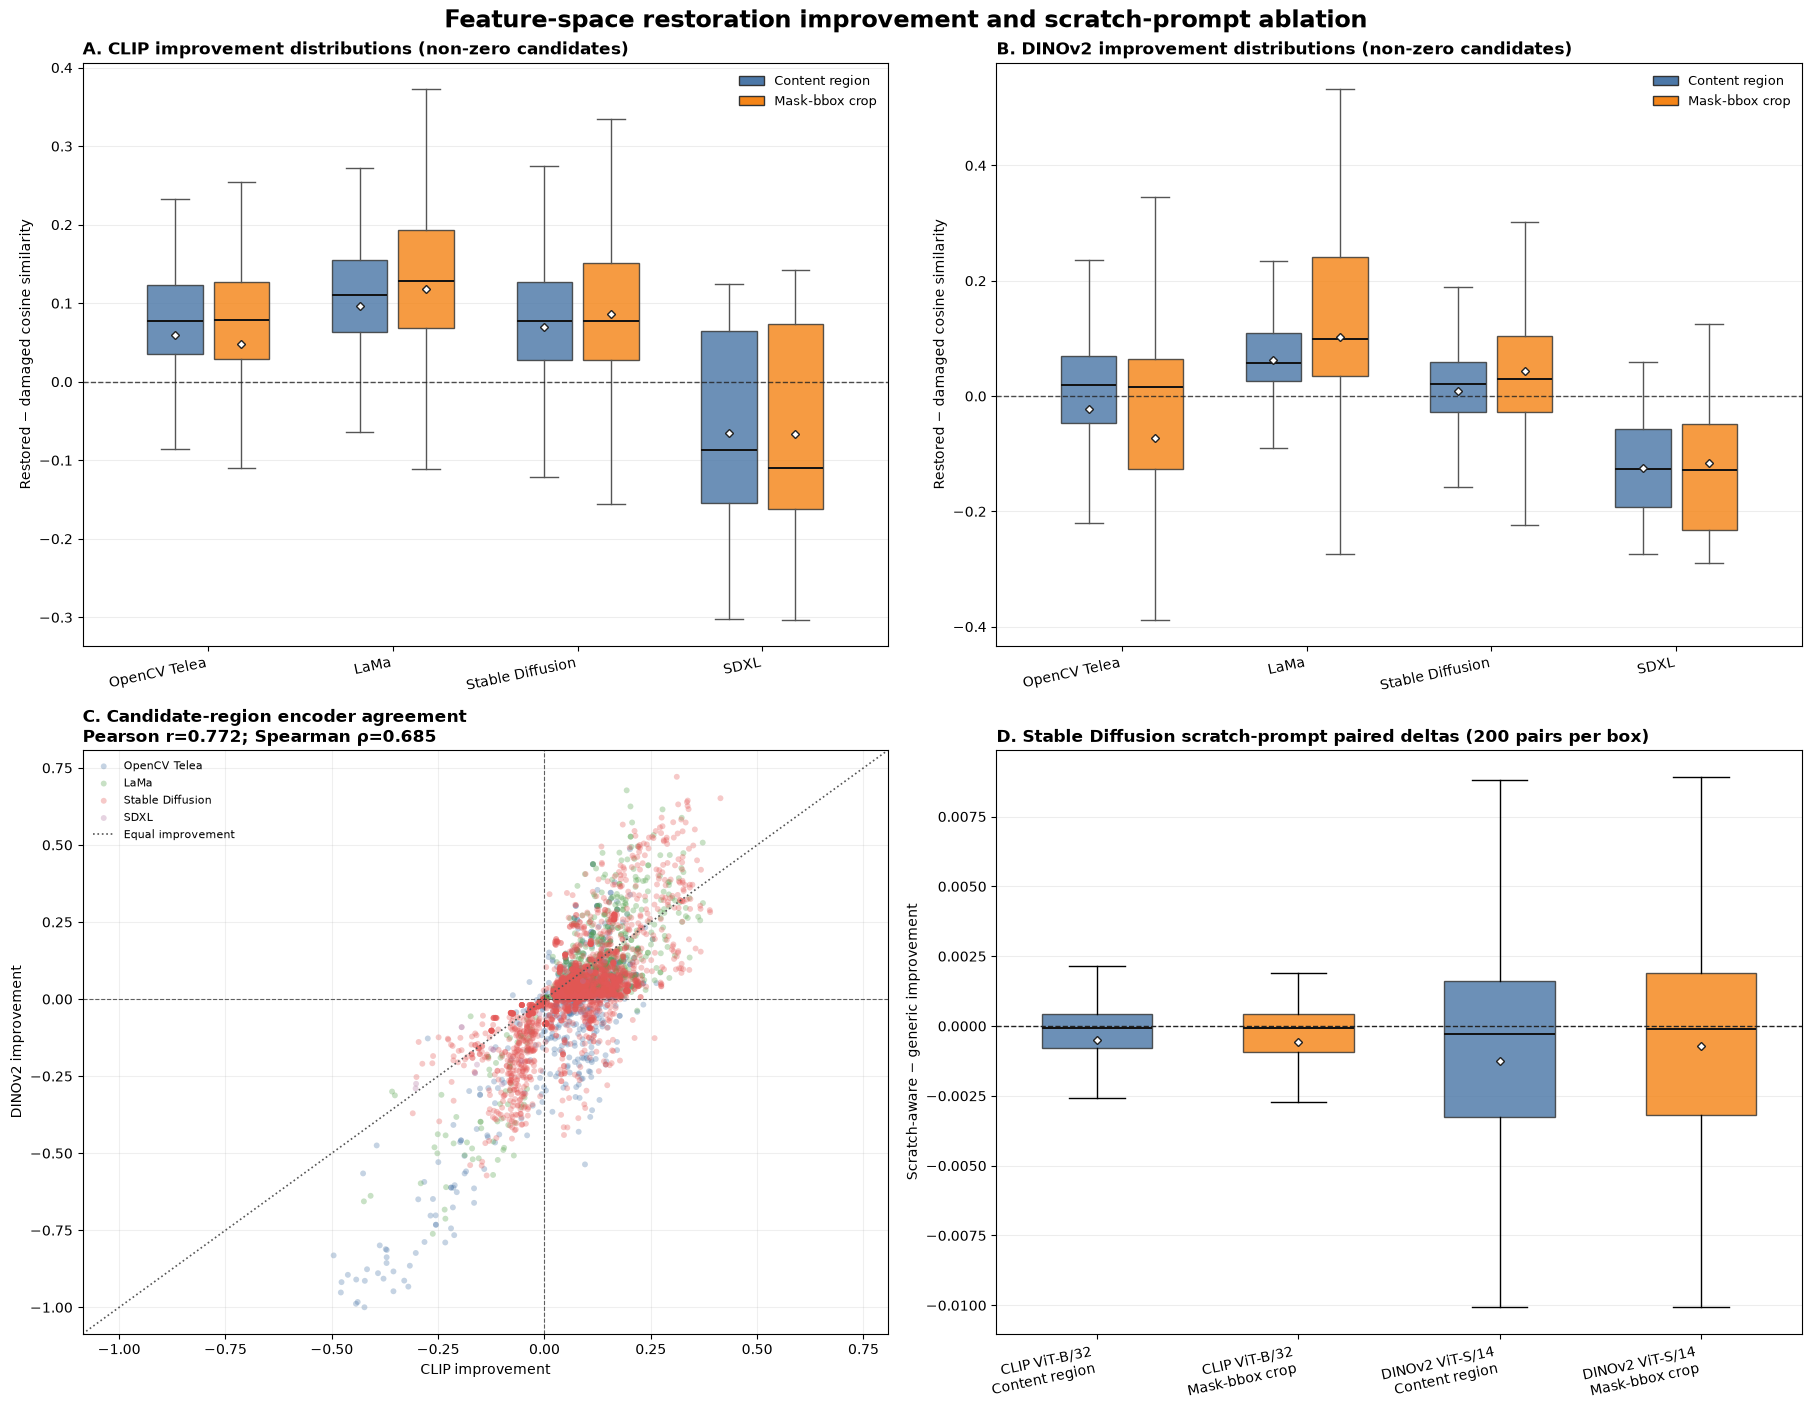

Canonical feature figure rendered.
Figure path: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\15_feature_similarity\figures\feature_similarity_distributions.png
Figure panels: 4
Figure size bytes: 715132


In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ---------------------------------------------------------------------------
# Visual policy
# ---------------------------------------------------------------------------

REGION_COLORS = {
    "content_region": "#4C78A8",
    "mask_bbox_crop": "#F58518",
}

MODEL_COLORS = {
    "opencv_telea": "#4C78A8",
    "lama": "#54A24B",
    "stable_diffusion_inpainting": (
        "#E45756"
    ),
    "sdxl_inpainting": "#B279A2",
}

region_offsets = {
    "content_region": -0.18,
    "mask_bbox_crop": 0.18,
}

region_legend_handles = [
    Patch(
        facecolor=REGION_COLORS[
            region_id
        ],
        edgecolor="#333333",
        label=REGION_LABELS[
            region_id
        ],
    )
    for region_id in REGION_ORDER
]


def draw_improvement_boxplots(
    axis,
    feature_model_id,
    title,
):
    plot_data = []
    plot_positions = []
    plot_colors = []

    for model_position, model_id in (
        enumerate(
            MODEL_ORDER,
            start=1,
        )
    ):
        for region_id in REGION_ORDER:
            values = (
                feature_distribution_df.loc[
                    (
                        feature_distribution_df[
                            "feature_model_id"
                        ].astype(str).eq(
                            feature_model_id
                        )
                    )
                    & (
                        feature_distribution_df[
                            "model_id"
                        ].astype(str).eq(
                            model_id
                        )
                    )
                    & (
                        feature_distribution_df[
                            "region_id"
                        ].astype(str).eq(
                            region_id
                        )
                    ),
                    "improvement_value",
                ]
                .astype(float)
                .to_numpy()
            )

            if values.size == 0:
                raise ValueError(
                    "Missing distribution data for "
                    f"{feature_model_id}, "
                    f"{model_id}, {region_id}."
                )

            plot_data.append(values)

            plot_positions.append(
                model_position
                + region_offsets[
                    region_id
                ]
            )

            plot_colors.append(
                REGION_COLORS[
                    region_id
                ]
            )

    boxplot_result = axis.boxplot(
        plot_data,
        positions=plot_positions,
        widths=0.30,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "#222222",
            "markersize": 4,
        },
        medianprops={
            "color": "#111111",
            "linewidth": 1.4,
        },
        whiskerprops={
            "color": "#555555",
            "linewidth": 1.0,
        },
        capprops={
            "color": "#555555",
            "linewidth": 1.0,
        },
    )

    for patch, color in zip(
        boxplot_result["boxes"],
        plot_colors,
        strict=True,
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.82)
        patch.set_edgecolor("#333333")

    axis.axhline(
        0.0,
        color="#222222",
        linestyle="--",
        linewidth=1.0,
        alpha=0.8,
    )

    axis.set_xticks(
        range(
            1,
            len(MODEL_ORDER) + 1,
        )
    )

    axis.set_xticklabels(
        [
            MODEL_LABELS[model_id]
            for model_id in MODEL_ORDER
        ],
        rotation=12,
        ha="right",
    )

    axis.set_ylabel(
        "Restored − damaged cosine similarity"
    )
    axis.set_title(
        title,
        loc="left",
        fontweight="bold",
    )
    axis.grid(
        axis="y",
        alpha=0.22,
    )
    axis.legend(
        handles=region_legend_handles,
        loc="best",
        frameon=False,
        fontsize=9,
    )


# ---------------------------------------------------------------------------
# Four approved panels
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    2,
    2,
    figsize=(18, 14),
    constrained_layout=True,
)

draw_improvement_boxplots(
    axes[0, 0],
    "clip_vit_b32",
    (
        "A. CLIP improvement distributions "
        "(non-zero candidates)"
    ),
)

draw_improvement_boxplots(
    axes[0, 1],
    "dinov2_vits14",
    (
        "B. DINOv2 improvement distributions "
        "(non-zero candidates)"
    ),
)


# ---------------------------------------------------------------------------
# Panel C — encoder agreement
# ---------------------------------------------------------------------------

agreement_axis = axes[1, 0]

for model_id in MODEL_ORDER:
    model_agreement_df = (
        feature_agreement_df.loc[
            feature_agreement_df[
                "model_id"
            ].astype(str).eq(
                model_id
            )
        ]
    )

    agreement_axis.scatter(
        model_agreement_df[
            "clip_vit_b32"
        ],
        model_agreement_df[
            "dinov2_vits14"
        ],
        s=18,
        alpha=0.32,
        color=MODEL_COLORS[
            model_id
        ],
        edgecolors="none",
        label=MODEL_LABELS[
            model_id
        ],
    )

agreement_minimum = float(
    min(
        feature_agreement_df[
            "clip_vit_b32"
        ].min(),
        feature_agreement_df[
            "dinov2_vits14"
        ].min(),
    )
)

agreement_maximum = float(
    max(
        feature_agreement_df[
            "clip_vit_b32"
        ].max(),
        feature_agreement_df[
            "dinov2_vits14"
        ].max(),
    )
)

agreement_padding = max(
    (
        agreement_maximum
        - agreement_minimum
    )
    * 0.05,
    0.01,
)

agreement_limits = (
    agreement_minimum
    - agreement_padding,
    agreement_maximum
    + agreement_padding,
)

agreement_axis.plot(
    agreement_limits,
    agreement_limits,
    color="#555555",
    linestyle=":",
    linewidth=1.2,
    label="Equal improvement",
)

agreement_axis.axhline(
    0.0,
    color="#222222",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
)

agreement_axis.axvline(
    0.0,
    color="#222222",
    linestyle="--",
    linewidth=0.8,
    alpha=0.7,
)

agreement_axis.set_xlim(
    agreement_limits
)
agreement_axis.set_ylim(
    agreement_limits
)

agreement_axis.set_xlabel(
    "CLIP improvement"
)
agreement_axis.set_ylabel(
    "DINOv2 improvement"
)

agreement_axis.set_title(
    (
        "C. Candidate-region encoder agreement\n"
        f"Pearson r={overall_clip_dino_pearson:.3f}; "
        f"Spearman ρ={overall_clip_dino_spearman:.3f}"
    ),
    loc="left",
    fontweight="bold",
)

agreement_axis.grid(
    alpha=0.20,
)

agreement_axis.legend(
    loc="best",
    frameon=False,
    fontsize=8,
)


# ---------------------------------------------------------------------------
# Panel D — scratch-aware prompt deltas
# ---------------------------------------------------------------------------

scratch_axis = axes[1, 1]

scratch_group_order = [
    (
        feature_model_id,
        region_id,
    )
    for feature_model_id
    in FEATURE_MODEL_IDS
    for region_id in REGION_ORDER
]

scratch_delta_data = []
scratch_delta_labels = []
scratch_delta_colors = []

for feature_model_id, region_id in (
    scratch_group_order
):
    values = (
        scratch_prompt_pairs_df.loc[
            (
                scratch_prompt_pairs_df[
                    "feature_model_id"
                ].astype(str).eq(
                    feature_model_id
                )
            )
            & (
                scratch_prompt_pairs_df[
                    "region_id"
                ].astype(str).eq(
                    region_id
                )
            ),
            "scratch_aware_minus_generic",
        ]
        .astype(float)
        .to_numpy()
    )

    scratch_delta_data.append(values)

    scratch_delta_labels.append(
        (
            FEATURE_MODEL_LABELS[
                feature_model_id
            ]
            + "\n"
            + REGION_LABELS[
                region_id
            ]
        )
    )

    scratch_delta_colors.append(
        REGION_COLORS[
            region_id
        ]
    )

scratch_boxplot_result = (
    scratch_axis.boxplot(
        scratch_delta_data,
        positions=range(
            1,
            len(scratch_delta_data) + 1,
        ),
        widths=0.55,
        patch_artist=True,
        showfliers=False,
        showmeans=True,
        meanprops={
            "marker": "D",
            "markerfacecolor": "white",
            "markeredgecolor": "#222222",
            "markersize": 4,
        },
        medianprops={
            "color": "#111111",
            "linewidth": 1.4,
        },
    )
)

for patch, color in zip(
    scratch_boxplot_result["boxes"],
    scratch_delta_colors,
    strict=True,
):
    patch.set_facecolor(color)
    patch.set_alpha(0.82)
    patch.set_edgecolor("#333333")

scratch_axis.axhline(
    0.0,
    color="#222222",
    linestyle="--",
    linewidth=1.0,
)

scratch_axis.set_xticks(
    range(
        1,
        len(scratch_delta_labels) + 1,
    )
)

scratch_axis.set_xticklabels(
    scratch_delta_labels,
    rotation=12,
    ha="right",
)

scratch_axis.set_ylabel(
    (
        "Scratch-aware − generic "
        "improvement"
    )
)

scratch_axis.set_title(
    (
        "D. Stable Diffusion scratch-prompt "
        "paired deltas (200 pairs per box)"
    ),
    loc="left",
    fontweight="bold",
)

scratch_axis.grid(
    axis="y",
    alpha=0.22,
)


# ---------------------------------------------------------------------------
# Figure-level context and canonical persistence
# ---------------------------------------------------------------------------

figure.suptitle(
    (
        "Feature-space restoration improvement "
        "and scratch-prompt ablation"
    ),
    fontsize=17,
    fontweight="bold",
)

figure_panel_count = len(
    figure.axes
)

OUTPUTS[
    "feature_distributions"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    OUTPUTS[
        "feature_distributions"
    ],
    dpi=220,
    bbox_inches="tight",
    facecolor="white",
    metadata={
        "Title": (
            "Notebook 15 feature-similarity "
            "distributions"
        ),
        "Software": (
            f"matplotlib {matplotlib.__version__}"
        ),
    },
)

plt.show()
plt.close(figure)

print("Canonical feature figure rendered.")
print(
    "Figure path:",
    OUTPUTS[
        "feature_distributions"
    ],
)
print(
    "Figure panels:",
    figure_panel_count,
)
print(
    "Figure size bytes:",
    OUTPUTS[
        "feature_distributions"
    ].stat().st_size,
)

In [26]:
from PIL import Image


# ---------------------------------------------------------------------------
# Make Batch 6 validation safely rerunnable
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_6_analysis_visualization"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_analysis_visualization"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Analysis scope
# ---------------------------------------------------------------------------

expected_nonzero_metric_rows = (
    EXPECTED_COUNTS[
        "total_metric_rows"
    ]
    - (
        EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
        * len(FEATURE_MODEL_IDS)
    )
)

add_batch_6_check(
    "nonzero_analysis_rows",
    (
        "The distribution analysis excludes only "
        "the 300 expected zero-control rows."
    ),
    expected_nonzero_metric_rows,
    len(feature_distribution_df),
    (
        len(feature_distribution_df)
        == expected_nonzero_metric_rows
    ),
)

add_batch_6_check(
    "zero_controls_excluded_from_figure",
    (
        "No zero-control row enters the "
        "distribution or agreement panels."
    ),
    0,
    int(
        feature_distribution_df[
            "is_zero_control"
        ].astype(bool).sum()
    ),
    (
        not feature_distribution_df[
            "is_zero_control"
        ].astype(bool).any()
    ),
)

expected_distribution_groups = (
    len(FEATURE_MODEL_IDS)
    * len(MODEL_ORDER)
    * len(REGION_ORDER)
)

add_batch_6_check(
    "distribution_group_coverage",
    (
        "Both encoders, all four restoration "
        "models, and both regions appear in the "
        "distribution summary."
    ),
    expected_distribution_groups,
    len(feature_distribution_summary_df),
    (
        len(feature_distribution_summary_df)
        == expected_distribution_groups
    ),
)

distribution_numeric_failure_count = int(
    (
        ~np.isfinite(
            feature_distribution_summary_df[
                [
                    "mean_improvement",
                    "median_improvement",
                    "lower_quartile",
                    "upper_quartile",
                    "minimum_improvement",
                    "maximum_improvement",
                    "positive_rate",
                    "negative_rate",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

add_batch_6_check(
    "distribution_summary_finite",
    (
        "Every displayed distribution summary "
        "statistic is finite."
    ),
    0,
    distribution_numeric_failure_count,
    distribution_numeric_failure_count == 0,
)


# ---------------------------------------------------------------------------
# Encoder agreement and scratch ablation
# ---------------------------------------------------------------------------

expected_agreement_rows = (
    expected_nonzero_metric_rows
    // len(FEATURE_MODEL_IDS)
)

add_batch_6_check(
    "encoder_agreement_rows",
    (
        "Every non-zero candidate-region key has "
        "one matched CLIP-DINOv2 comparison."
    ),
    expected_agreement_rows,
    len(feature_agreement_df),
    (
        len(feature_agreement_df)
        == expected_agreement_rows
    ),
)

agreement_duplicate_count = int(
    feature_agreement_df.duplicated(
        [
            "candidate_id",
            "region_id",
        ],
        keep=False,
    ).sum()
)

add_batch_6_check(
    "encoder_agreement_keys_unique",
    (
        "Every candidate-region agreement key "
        "is unique."
    ),
    0,
    agreement_duplicate_count,
    agreement_duplicate_count == 0,
)

agreement_correlation_failure_count = int(
    (
        ~np.isfinite(
            feature_agreement_summary_df[
                [
                    "pearson_correlation",
                    "spearman_correlation",
                    "same_direction_rate",
                ]
            ].to_numpy(dtype=float)
        )
    ).sum()
)

add_batch_6_check(
    "encoder_agreement_statistics",
    (
        "All model-region correlation and "
        "direction-agreement summaries are finite."
    ),
    0,
    agreement_correlation_failure_count,
    agreement_correlation_failure_count == 0,
)

add_batch_6_check(
    "scratch_panel_pair_coverage",
    (
        "The scratch-prompt panel represents all "
        "800 paired comparisons."
    ),
    EXPECTED_COUNTS[
        "scratch_prompt_paired_comparisons"
    ],
    int(
        sum(
            len(values)
            for values
            in scratch_delta_data
        )
    ),
    (
        sum(
            len(values)
            for values
            in scratch_delta_data
        )
        == EXPECTED_COUNTS[
            "scratch_prompt_paired_comparisons"
        ]
    ),
)


# ---------------------------------------------------------------------------
# Canonical figure contract
# ---------------------------------------------------------------------------

figure_path = OUTPUTS[
    "feature_distributions"
]

if figure_path.is_file():
    with Image.open(
        figure_path
    ) as figure_image:
        figure_file_format = (
            figure_image.format
        )
        figure_width = int(
            figure_image.width
        )
        figure_height = int(
            figure_image.height
        )
        figure_mode = figure_image.mode
else:
    figure_file_format = ""
    figure_width = 0
    figure_height = 0
    figure_mode = ""

figure_file_details = {
    "format": figure_file_format,
    "mode": figure_mode,
    "width": figure_width,
    "height": figure_height,
    "size_bytes": (
        figure_path.stat().st_size
        if figure_path.is_file()
        else 0
    ),
}

add_batch_6_check(
    "canonical_figure_exists",
    (
        "The canonical four-panel feature figure "
        "exists and is non-empty."
    ),
    True,
    figure_path.is_file(),
    (
        figure_path.is_file()
        and figure_path.stat().st_size > 0
    ),
)

add_batch_6_check(
    "canonical_figure_format",
    (
        "The canonical feature figure is a valid "
        "PNG image."
    ),
    "PNG",
    figure_file_format,
    figure_file_format == "PNG",
)

add_batch_6_check(
    "canonical_figure_dimensions",
    (
        "The saved figure has sufficient "
        "resolution for thesis use."
    ),
    {
        "minimum_width": 2400,
        "minimum_height": 1800,
    },
    {
        "width": figure_width,
        "height": figure_height,
    },
    (
        figure_width >= 2400
        and figure_height >= 1800
    ),
)

add_batch_6_check(
    "canonical_figure_panels",
    (
        "The figure contains exactly the four "
        "approved analysis panels."
    ),
    4,
    figure_panel_count,
    figure_panel_count == 4,
)

configured_figure_panels = (
    FEATURE_CONFIG[
        "analysis"
    ][
        "figure_panels"
    ]
)

add_batch_6_check(
    "configured_panel_contract",
    (
        "The configuration declares exactly the "
        "four rendered panel responsibilities."
    ),
    4,
    len(configured_figure_panels),
    len(configured_figure_panels) == 4,
)

observed_canonical_outputs = {
    output_key
    for output_key, output_path
    in OUTPUTS.items()
    if output_path.exists()
}

add_batch_6_check(
    "canonical_output_boundary",
    (
        "Only the approved canonical figure has "
        "been persisted before Batch 7."
    ),
    {
        "feature_distributions",
    },
    observed_canonical_outputs,
    (
        observed_canonical_outputs
        == {
            "feature_distributions",
        }
    ),
)


# ---------------------------------------------------------------------------
# Interpretation boundaries
# ---------------------------------------------------------------------------

add_batch_6_check(
    "feature_metrics_are_diagnostic",
    (
        "CLIP and DINOv2 remain explicitly "
        "diagnostic and non-conservation-specific."
    ),
    "diagnostic_only",
    FEATURE_CONFIG[
        "known_limitations"
    ][:2],
    True,
    severity="info",
)

add_batch_6_check(
    "sdxl_scope_is_partial",
    (
        "SDXL visualization remains explicitly "
        "limited to its predeclared ten-case scope."
    ),
    10,
    int(
        feature_distribution_df.loc[
            feature_distribution_df[
                "model_id"
            ].astype(str).eq(
                "sdxl_inpainting"
            ),
            "candidate_id",
        ].nunique()
    ),
    (
        feature_distribution_df.loc[
            feature_distribution_df[
                "model_id"
            ].astype(str).eq(
                "sdxl_inpainting"
            ),
            "candidate_id",
        ].nunique()
        == 10
    ),
    severity="info",
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_6_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_6_analysis_visualization"
        )
    ]
    .reset_index(drop=True)
)

display(batch_6_validation_df)

VALIDATION.raise_for_blocking()

print(
    "Batch 6 analysis and visualization passed."
)
print(
    "Batch 6 checks:",
    len(batch_6_validation_df),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical figure details:",
    figure_file_details,
)
print(
    "Overall CLIP-DINOv2 Pearson:",
    round(
        overall_clip_dino_pearson,
        6,
    ),
)
print(
    "Overall CLIP-DINOv2 Spearman:",
    round(
        overall_clip_dino_spearman,
        6,
    ),
)
print(
    "Scratch-aware mean deltas:",
    scratch_prompt_summary_df[
        [
            "feature_model_id",
            "region_id",
            "mean_paired_delta",
        ]
    ].to_dict("records"),
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_visualization,nonzero_analysis_rows,The distribution analysis excludes only the 30...,blocking,8040,8040,True,
1,batch_6_analysis_visualization,zero_controls_excluded_from_figure,No zero-control row enters the distribution or...,blocking,0,0,True,
2,batch_6_analysis_visualization,distribution_group_coverage,"Both encoders, all four restoration models, an...",blocking,16,16,True,
3,batch_6_analysis_visualization,distribution_summary_finite,Every displayed distribution summary statistic...,blocking,0,0,True,
4,batch_6_analysis_visualization,encoder_agreement_rows,Every non-zero candidate-region key has one ma...,blocking,4020,4020,True,
5,batch_6_analysis_visualization,encoder_agreement_keys_unique,Every candidate-region agreement key is unique.,blocking,0,0,True,
6,batch_6_analysis_visualization,encoder_agreement_statistics,All model-region correlation and direction-agr...,blocking,0,0,True,
7,batch_6_analysis_visualization,scratch_panel_pair_coverage,The scratch-prompt panel represents all 800 pa...,blocking,800,800,True,
8,batch_6_analysis_visualization,canonical_figure_exists,The canonical four-panel feature figure exists...,blocking,True,True,True,
9,batch_6_analysis_visualization,canonical_figure_format,The canonical feature figure is a valid PNG im...,blocking,PNG,PNG,True,


Batch 6 analysis and visualization passed.
Batch 6 checks: 16
Cumulative blocking failures: 0
Canonical figure details: {'format': 'PNG', 'mode': 'RGBA', 'width': 3985, 'height': 3105, 'size_bytes': 715132}
Overall CLIP-DINOv2 Pearson: 0.771833
Overall CLIP-DINOv2 Spearman: 0.684732
Scratch-aware mean deltas: [{'feature_model_id': 'clip_vit_b32', 'region_id': 'content_region', 'mean_paired_delta': -0.00048401743173599244}, {'feature_model_id': 'clip_vit_b32', 'region_id': 'mask_bbox_crop', 'mean_paired_delta': -0.0005866634845733643}, {'feature_model_id': 'dinov2_vits14', 'region_id': 'content_region', 'mean_paired_delta': -0.0012585753202438354}, {'feature_model_id': 'dinov2_vits14', 'region_id': 'mask_bbox_crop', 'mean_paired_delta': -0.0007011520862579345}]


## Batch 7 — Canonical feature-evidence persistence

This batch atomically persists and reloads:

- the 8,340-row feature-metric table;
- the 10,700-row embedding manifest;
- the compressed CLIP and DINOv2 embedding matrices.

The canonical reload must preserve:

- exact versioned column order and schemas;
- every deterministic metric and embedding identifier;
- model, revision, checksum, preprocessing, device, package, region, and schema provenance;
- all signed improvement values;
- exact float32 embedding values and dimensions;
- all candidate, model, region, and embedding-role cardinalities.

The validated four-panel figure must remain unchanged.

Run and artifact manifests, consolidated validation persistence, project-path registry updates, and work-directory cleanup remain deferred to the final handoff batch.

In [27]:
import os
import time

from uuid import uuid4

from restoration_eval.metrics_feature_similarity import (
    load_feature_embedding_bundle,
    save_feature_embedding_bundle,
)

from restoration_eval.schemas import (
    FEATURE_EMBEDDING_MANIFEST_COLUMNS,
    FEATURE_METRICS_COLUMNS,
)


# ---------------------------------------------------------------------------
# Windows-safe atomic writers
# ---------------------------------------------------------------------------

CANONICAL_WRITE_ATTEMPTS = 8
CANONICAL_INITIAL_RETRY_SECONDS = 0.125


def write_canonical_dataframe_atomic(
    dataframe,
    destination,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        CANONICAL_INITIAL_RETRY_SECONDS
    )
    last_error = None

    for attempt_number in range(
        1,
        CANONICAL_WRITE_ATTEMPTS + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                "."
                + destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            dataframe.to_csv(
                temporary_path,
                index=False,
                lineterminator="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
                "status": "canonical",
            }

        except PermissionError as exc:
            last_error = exc

            temporary_path.unlink(
                missing_ok=True
            )

            if (
                attempt_number
                < CANONICAL_WRITE_ATTEMPTS
            ):
                time.sleep(
                    retry_seconds
                )

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            temporary_path.unlink(
                missing_ok=True
            )
            raise

    raise PermissionError(
        "Could not atomically persist "
        f"{destination} after "
        f"{CANONICAL_WRITE_ATTEMPTS} attempts: "
        f"{last_error}"
    )


def write_canonical_embedding_bundle_atomic(
    arrays,
    destination,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        CANONICAL_INITIAL_RETRY_SECONDS
    )
    last_error = None

    for attempt_number in range(
        1,
        CANONICAL_WRITE_ATTEMPTS + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                "."
                + destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            save_feature_embedding_bundle(
                arrays,
                temporary_path,
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
                "status": "canonical",
            }

        except PermissionError as exc:
            last_error = exc

            temporary_path.unlink(
                missing_ok=True
            )

            if (
                attempt_number
                < CANONICAL_WRITE_ATTEMPTS
            ):
                time.sleep(
                    retry_seconds
                )

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            temporary_path.unlink(
                missing_ok=True
            )
            raise

    raise PermissionError(
        "Could not atomically persist "
        f"{destination} after "
        f"{CANONICAL_WRITE_ATTEMPTS} attempts: "
        f"{last_error}"
    )


# ---------------------------------------------------------------------------
# Exact canonical source objects
# ---------------------------------------------------------------------------

canonical_feature_metrics_source_df = (
    full_feature_metrics_df.loc[
        :,
        FEATURE_METRICS_COLUMNS,
    ]
    .copy()
)

canonical_embedding_manifest_source_df = (
    full_embedding_manifest_df.loc[
        :,
        FEATURE_EMBEDDING_MANIFEST_COLUMNS,
    ]
    .copy()
)

canonical_embedding_source_arrays = {
    model_spec.array_name: np.asarray(
        full_embedding_arrays[
            model_spec.array_name
        ],
        dtype=np.float32,
    )
    for model_spec in MODEL_SPECS.values()
}

figure_checksum_before_persistence = (
    sha256_file(
        OUTPUTS[
            "feature_distributions"
        ]
    )
)


# ---------------------------------------------------------------------------
# Persist the three remaining canonical evidence files
# ---------------------------------------------------------------------------

feature_metrics_write_result = (
    write_canonical_dataframe_atomic(
        canonical_feature_metrics_source_df,
        OUTPUTS["feature_metrics"],
    )
)

embedding_manifest_write_result = (
    write_canonical_dataframe_atomic(
        canonical_embedding_manifest_source_df,
        OUTPUTS["embedding_manifest"],
    )
)

embedding_bundle_write_result = (
    write_canonical_embedding_bundle_atomic(
        canonical_embedding_source_arrays,
        OUTPUTS["embeddings"],
    )
)

canonical_write_results_df = pd.DataFrame(
    [
        {
            "artifact_key": (
                "feature_metrics"
            ),
            **feature_metrics_write_result,
        },
        {
            "artifact_key": (
                "embedding_manifest"
            ),
            **embedding_manifest_write_result,
        },
        {
            "artifact_key": "embeddings",
            **embedding_bundle_write_result,
        },
    ]
)

CANONICAL_EVIDENCE_PERSISTED_AT_UTC = (
    utc_now_iso()
)

display(canonical_write_results_df)

print("Canonical feature evidence persisted.")
print(
    "Feature metric rows:",
    len(
        canonical_feature_metrics_source_df
    ),
)
print(
    "Embedding manifest rows:",
    len(
        canonical_embedding_manifest_source_df
    ),
)
print(
    "Embedding arrays:",
    {
        name: tuple(array.shape)
        for name, array
        in canonical_embedding_source_arrays.items()
    },
)
print(
    "Metric bytes:",
    OUTPUTS[
        "feature_metrics"
    ].stat().st_size,
)
print(
    "Manifest bytes:",
    OUTPUTS[
        "embedding_manifest"
    ].stat().st_size,
)
print(
    "Embedding-bundle bytes:",
    OUTPUTS[
        "embeddings"
    ].stat().st_size,
)

,artifact_key,path,attempts,status
0,feature_metrics,D:\Masters\FH\Thesis\painting-restoration-eval...,1,canonical
1,embedding_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,1,canonical
2,embeddings,D:\Masters\FH\Thesis\painting-restoration-eval...,1,canonical


Canonical feature evidence persisted.
Feature metric rows: 8340
Embedding manifest rows: 10700
Embedding arrays: {'clip_embeddings': (5350, 512), 'dinov2_embeddings': (5350, 384)}
Metric bytes: 5248929
Manifest bytes: 6072209
Embedding-bundle bytes: 15047163


In [28]:
# ---------------------------------------------------------------------------
# Reload all canonical evidence
# ---------------------------------------------------------------------------

canonical_feature_metrics_df = pd.read_csv(
    OUTPUTS["feature_metrics"],
    keep_default_na=False,
    low_memory=False,
)

canonical_embedding_manifest_df = (
    pd.read_csv(
        OUTPUTS["embedding_manifest"],
        keep_default_na=False,
        low_memory=False,
    )
)

canonical_embedding_arrays = (
    load_feature_embedding_bundle(
        OUTPUTS["embeddings"]
    )
)


# ---------------------------------------------------------------------------
# Schema and scientific validation
# ---------------------------------------------------------------------------

canonical_feature_metrics_schema = (
    validate_dataframe(
        canonical_feature_metrics_df,
        FEATURE_METRICS_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_embedding_manifest_schema = (
    validate_dataframe(
        canonical_embedding_manifest_df,
        FEATURE_EMBEDDING_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_embedding_validation = (
    validate_feature_embedding_manifest(
        canonical_embedding_manifest_df,
        canonical_embedding_arrays,
        config=feature_similarity_config,
        expected_plan=(
            feature_embedding_plan_df
        ),
    )
)

canonical_feature_metrics_validation = (
    validate_feature_metrics(
        canonical_feature_metrics_df,
        feature_execution_plan_df,
        canonical_embedding_manifest_df,
        config=feature_similarity_config,
    )
)


# ---------------------------------------------------------------------------
# Order-independent metric-table comparison
# ---------------------------------------------------------------------------

source_metrics_sorted_df = (
    canonical_feature_metrics_source_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

reloaded_metrics_sorted_df = (
    canonical_feature_metrics_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_metric_identifier_match = bool(
    source_metrics_sorted_df[
        "metric_row_id"
    ].astype(str).equals(
        reloaded_metrics_sorted_df[
            "metric_row_id"
        ].astype(str)
    )
)

FEATURE_METRIC_NUMERIC_COLUMNS = [
    "region_pixel_count",
    "region_width",
    "region_height",
    "damaged_value",
    "restored_value",
    "improvement_value",
    "input_size",
]

source_metric_numeric_values = (
    source_metrics_sorted_df[
        FEATURE_METRIC_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

reloaded_metric_numeric_values = (
    reloaded_metrics_sorted_df[
        FEATURE_METRIC_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

canonical_metric_numeric_match = bool(
    np.allclose(
        source_metric_numeric_values,
        reloaded_metric_numeric_values,
        rtol=1e-12,
        atol=1e-12,
        equal_nan=True,
    )
)

canonical_metric_numeric_maximum_difference = (
    float(
        np.abs(
            source_metric_numeric_values
            - reloaded_metric_numeric_values
        ).max()
    )
)

FEATURE_METRIC_CATEGORICAL_COLUMNS = [
    column
    for column in FEATURE_METRICS_COLUMNS
    if column
    not in {
        *FEATURE_METRIC_NUMERIC_COLUMNS,
        "issue",
    }
]

canonical_metric_categorical_match = all(
    source_metrics_sorted_df[
        column
    ]
    .fillna("")
    .astype(str)
    .equals(
        reloaded_metrics_sorted_df[
            column
        ]
        .fillna("")
        .astype(str)
    )
    for column in (
        FEATURE_METRIC_CATEGORICAL_COLUMNS
    )
)

canonical_metric_issue_match = bool(
    source_metrics_sorted_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .equals(
        reloaded_metrics_sorted_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
    )
)


# ---------------------------------------------------------------------------
# Order-independent embedding-manifest comparison
# ---------------------------------------------------------------------------

source_manifest_sorted_df = (
    canonical_embedding_manifest_source_df
    .sort_values(
        "embedding_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

reloaded_manifest_sorted_df = (
    canonical_embedding_manifest_df
    .sort_values(
        "embedding_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_embedding_identifier_match = (
    bool(
        source_manifest_sorted_df[
            "embedding_id"
        ].astype(str).equals(
            reloaded_manifest_sorted_df[
                "embedding_id"
            ].astype(str)
        )
    )
)

EMBEDDING_MANIFEST_NUMERIC_COLUMNS = [
    "array_index",
    "embedding_dimension",
    "input_width",
    "input_height",
]

source_manifest_numeric_values = (
    source_manifest_sorted_df[
        EMBEDDING_MANIFEST_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

reloaded_manifest_numeric_values = (
    reloaded_manifest_sorted_df[
        EMBEDDING_MANIFEST_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

canonical_embedding_manifest_numeric_match = (
    bool(
        np.array_equal(
            source_manifest_numeric_values,
            reloaded_manifest_numeric_values,
        )
    )
)

EMBEDDING_MANIFEST_CATEGORICAL_COLUMNS = [
    column
    for column
    in FEATURE_EMBEDDING_MANIFEST_COLUMNS
    if column
    not in {
        *EMBEDDING_MANIFEST_NUMERIC_COLUMNS,
        "issue",
    }
]

canonical_embedding_manifest_categorical_match = (
    all(
        source_manifest_sorted_df[
            column
        ]
        .fillna("")
        .astype(str)
        .equals(
            reloaded_manifest_sorted_df[
                column
            ]
            .fillna("")
            .astype(str)
        )
        for column in (
            EMBEDDING_MANIFEST_CATEGORICAL_COLUMNS
        )
    )
)

canonical_embedding_manifest_issue_match = (
    bool(
        source_manifest_sorted_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
        .equals(
            reloaded_manifest_sorted_df[
                "issue"
            ]
            .fillna("")
            .astype(str)
        )
    )
)


# ---------------------------------------------------------------------------
# Exact embedding-array comparison
# ---------------------------------------------------------------------------

canonical_array_exact_matches = {
    array_name: bool(
        np.array_equal(
            np.asarray(
                canonical_embedding_source_arrays[
                    array_name
                ],
                dtype=np.float32,
            ),
            np.asarray(
                canonical_embedding_arrays[
                    array_name
                ],
                dtype=np.float32,
            ),
        )
    )
    for array_name in (
        canonical_embedding_source_arrays
    )
}

canonical_array_maximum_differences = {
    array_name: float(
        np.abs(
            np.asarray(
                canonical_embedding_source_arrays[
                    array_name
                ],
                dtype=np.float32,
            )
            - np.asarray(
                canonical_embedding_arrays[
                    array_name
                ],
                dtype=np.float32,
            )
        ).max()
    )
    for array_name in (
        canonical_embedding_source_arrays
    )
}

canonical_array_shapes = {
    array_name: tuple(array.shape)
    for array_name, array
    in canonical_embedding_arrays.items()
}


# ---------------------------------------------------------------------------
# Cardinality and file audits
# ---------------------------------------------------------------------------

canonical_metric_model_counts = {
    str(key): int(value)
    for key, value in (
        canonical_feature_metrics_df
        .groupby("model_id")
        .size()
        .items()
    )
}

canonical_embedding_model_counts = {
    str(key): int(value)
    for key, value in (
        canonical_embedding_manifest_df
        .groupby("feature_model_id")
        .size()
        .items()
    )
}

canonical_embedding_role_counts = {
    str(key): int(value)
    for key, value in (
        canonical_embedding_manifest_df
        .groupby("image_role")
        .size()
        .items()
    )
}

figure_checksum_after_persistence = (
    sha256_file(
        OUTPUTS[
            "feature_distributions"
        ]
    )
)

canonical_file_audit_records = []

for (
    artifact_key,
    output_path,
    file_format,
    schema_version,
    row_count,
    column_count,
) in [
    (
        "feature_metrics",
        OUTPUTS["feature_metrics"],
        "csv",
        FEATURE_METRICS_SCHEMA_VERSION,
        len(canonical_feature_metrics_df),
        len(
            canonical_feature_metrics_df.columns
        ),
    ),
    (
        "embeddings",
        OUTPUTS["embeddings"],
        "npz",
        FEATURE_EMBEDDING_SCHEMA_VERSION,
        len(canonical_embedding_manifest_df),
        len(canonical_embedding_arrays),
    ),
    (
        "embedding_manifest",
        OUTPUTS["embedding_manifest"],
        "csv",
        FEATURE_EMBEDDING_SCHEMA_VERSION,
        len(canonical_embedding_manifest_df),
        len(
            canonical_embedding_manifest_df.columns
        ),
    ),
    (
        "feature_distributions",
        OUTPUTS["feature_distributions"],
        "png",
        "",
        None,
        None,
    ),
]:
    canonical_file_audit_records.append(
        {
            "artifact_key": artifact_key,
            "relative_path": (
                to_repo_relative(
                    output_path,
                    PROJECT_ROOT,
                )
            ),
            "format": file_format,
            "schema_version": (
                schema_version
            ),
            "row_count": row_count,
            "column_count": column_count,
            "size_bytes": int(
                output_path.stat().st_size
            ),
            "sha256": sha256_file(
                output_path
            ),
        }
    )

canonical_file_audit_df = pd.DataFrame(
    canonical_file_audit_records
)

display(canonical_file_audit_df)

print("Canonical round-trip inspection complete.")
print(
    "Metric schema passed:",
    canonical_feature_metrics_schema.passed,
)
print(
    "Embedding-manifest schema passed:",
    canonical_embedding_manifest_schema.passed,
)
print(
    "Metric scientific validation passed:",
    canonical_feature_metrics_validation[
        "passed"
    ],
)
print(
    "Embedding validation passed:",
    canonical_embedding_validation[
        "passed"
    ],
)
print(
    "Metric identifiers preserved:",
    canonical_metric_identifier_match,
)
print(
    "Metric numerical values preserved:",
    canonical_metric_numeric_match,
)
print(
    "Metric maximum difference:",
    canonical_metric_numeric_maximum_difference,
)
print(
    "Embedding identifiers preserved:",
    canonical_embedding_identifier_match,
)
print(
    "Embedding arrays exact:",
    canonical_array_exact_matches,
)
print(
    "Embedding maximum differences:",
    canonical_array_maximum_differences,
)
print(
    "Canonical array shapes:",
    canonical_array_shapes,
)

,artifact_key,relative_path,format,schema_version,row_count,column_count,size_bytes,sha256
0,feature_metrics,outputs/15_feature_similarity/metrics/feature_...,csv,feature_metrics.v1,8340.0,30.0,5248929,5a680cd39605cb94c76f134f00927046baae52a09a1ea5...
1,embeddings,outputs/15_feature_similarity/data/embeddings.npz,npz,feature_embedding_manifest.v1,10700.0,2.0,15047163,ca1d16d40ce5408e66568c425f1d372cdae3e3ff92ec97...
2,embedding_manifest,outputs/15_feature_similarity/manifests/embedd...,csv,feature_embedding_manifest.v1,10700.0,22.0,6072209,4b76bdf1de277bff1dd29b4cd288c4aca0f756c213d921...
3,feature_distributions,outputs/15_feature_similarity/figures/feature_...,png,,NaN,NaN,715132,571f8ebdd5fb1dea580979ff2d70b82bdf217cd1da816e...


Canonical round-trip inspection complete.
Metric schema passed: True
Embedding-manifest schema passed: True
Metric scientific validation passed: True
Embedding validation passed: True
Metric identifiers preserved: True
Metric numerical values preserved: True
Metric maximum difference: 1.1102230246251565e-16
Embedding identifiers preserved: True
Embedding arrays exact: {'clip_embeddings': True, 'dinov2_embeddings': True}
Embedding maximum differences: {'clip_embeddings': 0.0, 'dinov2_embeddings': 0.0}
Canonical array shapes: {'clip_embeddings': (5350, 512), 'dinov2_embeddings': (5350, 384)}


In [29]:
# ---------------------------------------------------------------------------
# Make Batch 7 validation safely rerunnable
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_7_canonical_persistence"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_7_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_7_canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Canonical files and schemas
# ---------------------------------------------------------------------------

expected_canonical_evidence_files = {
    "feature_metrics": OUTPUTS[
        "feature_metrics"
    ].is_file(),
    "embeddings": OUTPUTS[
        "embeddings"
    ].is_file(),
    "embedding_manifest": OUTPUTS[
        "embedding_manifest"
    ].is_file(),
    "feature_distributions": OUTPUTS[
        "feature_distributions"
    ].is_file(),
}

add_batch_7_check(
    "canonical_evidence_files_exist",
    (
        "All four canonical evidence files exist."
    ),
    {
        key: True
        for key in (
            expected_canonical_evidence_files
        )
    },
    expected_canonical_evidence_files,
    all(
        expected_canonical_evidence_files.values()
    ),
)

add_batch_7_check(
    "canonical_metric_schema",
    (
        "The reloaded metric CSV satisfies the "
        "exact feature_metrics.v1 schema."
    ),
    True,
    canonical_feature_metrics_schema.to_dict(),
    canonical_feature_metrics_schema.passed,
)

add_batch_7_check(
    "canonical_embedding_manifest_schema",
    (
        "The reloaded embedding manifest satisfies "
        "its exact versioned schema."
    ),
    True,
    canonical_embedding_manifest_schema.to_dict(),
    canonical_embedding_manifest_schema.passed,
)

add_batch_7_check(
    "canonical_metric_validation",
    (
        "The reloaded metric table passes complete "
        "scientific validation."
    ),
    True,
    canonical_feature_metrics_validation,
    canonical_feature_metrics_validation[
        "passed"
    ],
)

add_batch_7_check(
    "canonical_embedding_validation",
    (
        "The reloaded manifest and embedding "
        "matrices pass complete validation."
    ),
    True,
    canonical_embedding_validation,
    canonical_embedding_validation[
        "passed"
    ],
)


# ---------------------------------------------------------------------------
# Canonical cardinalities
# ---------------------------------------------------------------------------

add_batch_7_check(
    "canonical_metric_rows",
    (
        "The canonical metric CSV contains exactly "
        "8,340 rows."
    ),
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(canonical_feature_metrics_df),
    (
        len(canonical_feature_metrics_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

add_batch_7_check(
    "canonical_embedding_rows",
    (
        "The canonical embedding manifest contains "
        "exactly 10,700 rows."
    ),
    EXPECTED_COUNTS[
        "total_embedding_rows"
    ],
    len(canonical_embedding_manifest_df),
    (
        len(canonical_embedding_manifest_df)
        == EXPECTED_COUNTS[
            "total_embedding_rows"
        ]
    ),
)

add_batch_7_check(
    "canonical_metric_model_counts",
    (
        "The canonical metric CSV preserves exact "
        "restoration-model coverage."
    ),
    EXPECTED_COUNTS[
        "metric_rows_by_restoration_model"
    ],
    canonical_metric_model_counts,
    (
        canonical_metric_model_counts
        == EXPECTED_COUNTS[
            "metric_rows_by_restoration_model"
        ]
    ),
)

expected_embedding_model_counts = {
    feature_model_id: (
        EXPECTED_COUNTS[
            "embeddings_per_feature_model"
        ]
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_7_check(
    "canonical_embedding_model_counts",
    (
        "Each canonical feature-model matrix has "
        "5,350 manifest rows."
    ),
    expected_embedding_model_counts,
    canonical_embedding_model_counts,
    (
        canonical_embedding_model_counts
        == expected_embedding_model_counts
    ),
)

add_batch_7_check(
    "canonical_embedding_role_counts",
    (
        "Canonical clean, damaged, and restored "
        "embedding counts preserve deduplication."
    ),
    EXPECTED_COUNTS[
        "embeddings_by_role_across_models"
    ],
    canonical_embedding_role_counts,
    (
        canonical_embedding_role_counts
        == EXPECTED_COUNTS[
            "embeddings_by_role_across_models"
        ]
    ),
)


# ---------------------------------------------------------------------------
# Exact round-trip checks
# ---------------------------------------------------------------------------

add_batch_7_check(
    "canonical_metric_identifier_roundtrip",
    (
        "Canonical persistence preserves every "
        "metric-row identifier."
    ),
    True,
    canonical_metric_identifier_match,
    canonical_metric_identifier_match,
)

add_batch_7_check(
    "canonical_metric_numeric_roundtrip",
    (
        "Canonical persistence preserves metric "
        "numerical values within strict tolerance."
    ),
    True,
    {
        "matched": (
            canonical_metric_numeric_match
        ),
        "maximum_absolute_difference": (
            canonical_metric_numeric_maximum_difference
        ),
    },
    canonical_metric_numeric_match,
)

add_batch_7_check(
    "canonical_metric_provenance_roundtrip",
    (
        "Canonical persistence preserves every "
        "metric categorical/provenance field."
    ),
    True,
    canonical_metric_categorical_match,
    canonical_metric_categorical_match,
)

add_batch_7_check(
    "canonical_metric_issue_roundtrip",
    (
        "Canonical persistence preserves explicit "
        "metric issue values."
    ),
    True,
    canonical_metric_issue_match,
    canonical_metric_issue_match,
)

add_batch_7_check(
    "canonical_embedding_identifier_roundtrip",
    (
        "Canonical persistence preserves every "
        "embedding identifier."
    ),
    True,
    canonical_embedding_identifier_match,
    canonical_embedding_identifier_match,
)

add_batch_7_check(
    "canonical_embedding_numeric_roundtrip",
    (
        "Canonical persistence preserves manifest "
        "indices and dimensions exactly."
    ),
    True,
    canonical_embedding_manifest_numeric_match,
    canonical_embedding_manifest_numeric_match,
)

add_batch_7_check(
    "canonical_embedding_provenance_roundtrip",
    (
        "Canonical persistence preserves every "
        "embedding categorical/provenance field."
    ),
    True,
    canonical_embedding_manifest_categorical_match,
    canonical_embedding_manifest_categorical_match,
)

add_batch_7_check(
    "canonical_embedding_issue_roundtrip",
    (
        "Canonical persistence preserves explicit "
        "embedding issue values."
    ),
    True,
    canonical_embedding_manifest_issue_match,
    canonical_embedding_manifest_issue_match,
)

add_batch_7_check(
    "canonical_embedding_arrays_exact",
    (
        "Compressed NPZ persistence preserves both "
        "float32 embedding matrices exactly."
    ),
    {
        array_name: True
        for array_name in (
            canonical_embedding_source_arrays
        )
    },
    canonical_array_exact_matches,
    all(
        canonical_array_exact_matches.values()
    ),
    details={
        "maximum_absolute_differences": (
            canonical_array_maximum_differences
        )
    },
)

expected_canonical_array_shapes = {
    MODEL_SPECS[
        feature_model_id
    ].array_name: (
        EXPECTED_COUNTS[
            "embeddings_per_feature_model"
        ],
        MODEL_SPECS[
            feature_model_id
        ].embedding_dimension,
    )
    for feature_model_id in FEATURE_MODEL_IDS
}

add_batch_7_check(
    "canonical_embedding_array_shapes",
    (
        "The canonical CLIP and DINOv2 arrays have "
        "their exact approved dimensions."
    ),
    expected_canonical_array_shapes,
    canonical_array_shapes,
    (
        canonical_array_shapes
        == expected_canonical_array_shapes
    ),
)


# ---------------------------------------------------------------------------
# Figure, checksums, and output scope
# ---------------------------------------------------------------------------

add_batch_7_check(
    "canonical_figure_retained",
    (
        "The validated four-panel figure remains "
        "unchanged during table persistence."
    ),
    figure_checksum_before_persistence,
    figure_checksum_after_persistence,
    (
        figure_checksum_after_persistence
        == figure_checksum_before_persistence
    ),
)

invalid_canonical_checksums = int(
    (
        ~canonical_file_audit_df[
            "sha256"
        ].astype(str).str.fullmatch(
            r"[0-9a-f]{64}"
        )
    ).sum()
)

add_batch_7_check(
    "canonical_file_checksums",
    (
        "Every canonical evidence file has a "
        "complete SHA-256 checksum."
    ),
    0,
    invalid_canonical_checksums,
    invalid_canonical_checksums == 0,
)

work_directory = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).resolve()

allowed_files_outside_work = {
    OUTPUTS[
        "feature_metrics"
    ].resolve(),
    OUTPUTS[
        "embeddings"
    ].resolve(),
    OUTPUTS[
        "embedding_manifest"
    ].resolve(),
    OUTPUTS[
        "feature_distributions"
    ].resolve(),
}

observed_files_outside_work = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and work_directory
        not in path.resolve().parents
    )
}

unexpected_files_outside_work = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_files_outside_work
        - allowed_files_outside_work
    )
)

add_batch_7_check(
    "canonical_output_scope",
    (
        "Only the four approved evidence files "
        "exist outside temporary work."
    ),
    [],
    unexpected_files_outside_work,
    not unexpected_files_outside_work,
)

handoff_outputs_exist_early = {
    output_key: OUTPUTS[
        output_key
    ].exists()
    for output_key in (
        "run_manifest",
        "artifacts",
        "validation",
    )
}

add_batch_7_check(
    "handoff_outputs_deferred",
    (
        "Universal manifests and consolidated "
        "validation remain deferred to Batch 8."
    ),
    {
        "run_manifest": False,
        "artifacts": False,
        "validation": False,
    },
    handoff_outputs_exist_early,
    (
        handoff_outputs_exist_early
        == {
            "run_manifest": False,
            "artifacts": False,
            "validation": False,
        }
    ),
)

atomic_path_matches = all(
    write_result["path"].resolve()
    == OUTPUTS[
        artifact_key
    ].resolve()
    for artifact_key, write_result
    in {
        "feature_metrics": (
            feature_metrics_write_result
        ),
        "embedding_manifest": (
            embedding_manifest_write_result
        ),
        "embeddings": (
            embedding_bundle_write_result
        ),
    }.items()
)

add_batch_7_check(
    "canonical_atomic_paths",
    (
        "All three new canonical files were "
        "atomically written to their exact paths."
    ),
    True,
    atomic_path_matches,
    atomic_path_matches,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_7_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_7_canonical_persistence"
        )
    ]
    .reset_index(drop=True)
)

display(batch_7_validation_df)

VALIDATION.raise_for_blocking()

print(
    "Batch 7 canonical persistence passed."
)
print(
    "Batch 7 checks:",
    len(batch_7_validation_df),
)
print(
    "Cumulative blocking failures:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical metric rows:",
    len(canonical_feature_metrics_df),
)
print(
    "Canonical embedding rows:",
    len(canonical_embedding_manifest_df),
)
print(
    "Canonical checksums:",
    canonical_file_audit_df[
        [
            "artifact_key",
            "sha256",
        ]
    ].to_dict("records"),
)
print(
    "Temporary checkpoint files remain until "
    "the final handoff batch."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_persistence,canonical_evidence_files_exist,All four canonical evidence files exist.,blocking,"{""embedding_manifest"": true, ""embeddings"": tru...","{""embedding_manifest"": true, ""embeddings"": tru...",True,
1,batch_7_canonical_persistence,canonical_metric_schema,The reloaded metric CSV satisfies the exact fe...,blocking,True,"{""column_count"": 30, ""duplicate_primary_key_ro...",True,
2,batch_7_canonical_persistence,canonical_embedding_manifest_schema,The reloaded embedding manifest satisfies its ...,blocking,True,"{""column_count"": 22, ""duplicate_primary_key_ro...",True,
3,batch_7_canonical_persistence,canonical_metric_validation,The reloaded metric table passes complete scie...,blocking,True,"{""cosine_bound_failure_count"": 0, ""embedding_r...",True,
4,batch_7_canonical_persistence,canonical_embedding_validation,The reloaded manifest and embedding matrices p...,blocking,True,"{""array_index_failure_count"": 0, ""embedding_no...",True,
5,batch_7_canonical_persistence,canonical_metric_rows,"The canonical metric CSV contains exactly 8,34...",blocking,8340,8340,True,
6,batch_7_canonical_persistence,canonical_embedding_rows,The canonical embedding manifest contains exac...,blocking,10700,10700,True,
7,batch_7_canonical_persistence,canonical_metric_model_counts,The canonical metric CSV preserves exact resto...,blocking,"{""lama"": 1540, ""opencv_telea"": 1540, ""sdxl_inp...","{""lama"": 1540, ""opencv_telea"": 1540, ""sdxl_inp...",True,
8,batch_7_canonical_persistence,canonical_embedding_model_counts,"Each canonical feature-model matrix has 5,350 ...",blocking,"{""clip_vit_b32"": 5350, ""dinov2_vits14"": 5350}","{""clip_vit_b32"": 5350, ""dinov2_vits14"": 5350}",True,
9,batch_7_canonical_persistence,canonical_embedding_role_counts,"Canonical clean, damaged, and restored embeddi...",blocking,"{""clean"": 820, ""damaged"": 1540, ""restored"": 8340}","{""clean"": 820, ""damaged"": 1540, ""restored"": 8340}",True,


Batch 7 canonical persistence passed.
Batch 7 checks: 25
Cumulative blocking failures: 0
Canonical metric rows: 8340
Canonical embedding rows: 10700
Canonical checksums: [{'artifact_key': 'feature_metrics', 'sha256': '5a680cd39605cb94c76f134f00927046baae52a09a1ea5db887e063a493d003f'}, {'artifact_key': 'embeddings', 'sha256': 'ca1d16d40ce5408e66568c425f1d372cdae3e3ff92ec97a55234f282c3add7e6'}, {'artifact_key': 'embedding_manifest', 'sha256': '4b76bdf1de277bff1dd29b4cd288c4aca0f756c213d9218ac70bd5420777b139'}, {'artifact_key': 'feature_distributions', 'sha256': '571f8ebdd5fb1dea580979ff2d70b82bdf217cd1da816e9440ba07c92d22ec29'}]
Temporary checkpoint files remain until the final handoff batch.


## Batch 8 — Final handoff and completion gate

This batch:

- writes the consolidated validation table;
- writes the universal artifact and run manifests;
- registers five validated downstream artifacts;
- safely removes the seven validated temporary checkpoint files;
- updates the authoritative project-path JSON and Markdown registries;
- independently reloads and verifies the complete handoff.

The final completion gate requires:

- exactly seven canonical Notebook 15 files;
- exactly five registered downstream artifacts;
- zero temporary work files;
- zero blocking validation failures;
- one documented non-blocking CUDA repeatability warning;
- complete artifact checksum agreement;
- a completed, passed, and refactored run manifest.

The project inventory is refreshed externally only after the completed notebook has been saved and independently inspected.

In [30]:
import gc

from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
)

from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
)


FINAL_CANONICAL_FILE_COUNT = 7
FINAL_ARTIFACT_RECORD_COUNT = 5
FINAL_RUN_ID = f"run_{uuid4().hex}"


# ---------------------------------------------------------------------------
# Windows-safe JSON and registry persistence
# ---------------------------------------------------------------------------

def write_json_atomic_retry(
    payload,
    destination,
    attempts=8,
    initial_retry_seconds=0.125,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        attempts + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                "."
                + destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            temporary_path.write_text(
                json.dumps(
                    payload,
                    indent=2,
                    ensure_ascii=False,
                )
                + "\n",
                encoding="utf-8",
                newline="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            temporary_path.unlink(
                missing_ok=True
            )

            if attempt_number < attempts:
                time.sleep(retry_seconds)

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            temporary_path.unlink(
                missing_ok=True
            )
            raise

    raise PermissionError(
        "Could not atomically persist JSON "
        f"after {attempts} attempts: "
        f"{last_error}"
    )


def call_with_permission_retry(
    function,
    *args,
    attempts=8,
    initial_retry_seconds=0.125,
    **kwargs,
):
    retry_seconds = (
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        attempts + 1,
    ):
        try:
            return {
                "result": function(
                    *args,
                    **kwargs,
                ),
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            if attempt_number < attempts:
                time.sleep(retry_seconds)

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

    raise PermissionError(
        "Operation remained unavailable after "
        f"{attempts} attempts: {last_error}"
    )


# ---------------------------------------------------------------------------
# Validation summary
# ---------------------------------------------------------------------------

def validation_stage_summary():
    validation_frame = (
        VALIDATION.to_dataframe()
    )

    stage_records = []

    for stage_name, stage_frame in (
        validation_frame.groupby(
            "validation_stage",
            sort=False,
        )
    ):
        stage_records.append(
            {
                "validation_stage": (
                    str(stage_name)
                ),
                "check_count": int(
                    len(stage_frame)
                ),
                "passed_count": int(
                    stage_frame[
                        "passed"
                    ].astype(bool).sum()
                ),
                "failed_count": int(
                    (
                        ~stage_frame[
                            "passed"
                        ].astype(bool)
                    ).sum()
                ),
                "blocking_failure_count": int(
                    (
                        ~stage_frame[
                            "passed"
                        ].astype(bool)
                        & stage_frame[
                            "severity"
                        ].eq("blocking")
                    ).sum()
                ),
                "warning_failure_count": int(
                    (
                        ~stage_frame[
                            "passed"
                        ].astype(bool)
                        & stage_frame[
                            "severity"
                        ].eq("warning")
                    ).sum()
                ),
            }
        )

    return {
        **VALIDATION.summary(),
        "warning_failure_count": int(
            (
                ~validation_frame[
                    "passed"
                ].astype(bool)
                & validation_frame[
                    "severity"
                ].eq("warning")
            ).sum()
        ),
        "stages": stage_records,
    }


# ---------------------------------------------------------------------------
# Registered downstream artifact records
# ---------------------------------------------------------------------------

def build_notebook_15_artifact_records():
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    return [
        build_artifact_record(
            artifact_key=(
                "feature_similarity.metrics"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "feature_metrics"
            ],
            artifact_type="table",
            artifact_role=(
                "primary_downstream_evidence"
            ),
            schema_version=(
                FEATURE_METRICS_SCHEMA_VERSION
            ),
            dataset_scope="controlled_50",
            experiment_id=(
                "cross_experiment_feature_similarity"
            ),
            validation_status="passed",
            row_count=len(
                canonical_feature_metrics_df
            ),
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "feature_similarity.embeddings"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS["embeddings"],
            artifact_type="array_bundle",
            artifact_role=(
                "reusable_embedding_evidence"
            ),
            schema_version=(
                "feature_embedding_bundle.v1"
            ),
            dataset_scope="controlled_50",
            experiment_id=(
                "cross_experiment_feature_similarity"
            ),
            validation_status="passed",
            row_count=len(
                canonical_embedding_manifest_df
            ),
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "feature_similarity.embedding_manifest"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "embedding_manifest"
            ],
            artifact_type="table",
            artifact_role=(
                "reusable_embedding_index"
            ),
            schema_version=(
                FEATURE_EMBEDDING_SCHEMA_VERSION
            ),
            dataset_scope="controlled_50",
            experiment_id=(
                "cross_experiment_feature_similarity"
            ),
            validation_status="passed",
            row_count=len(
                canonical_embedding_manifest_df
            ),
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "feature_similarity.distributions"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "feature_distributions"
            ],
            artifact_type="figure",
            artifact_role=(
                "reporting_visualization"
            ),
            schema_version=(
                "figure.feature_similarity_distributions.v1"
            ),
            dataset_scope="controlled_50",
            experiment_id=(
                "cross_experiment_feature_similarity"
            ),
            validation_status="passed",
            row_count=1,
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "validation.15_feature_similarity"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS["validation"],
            artifact_type=(
                "validation_table"
            ),
            artifact_role=(
                "validation_evidence"
            ),
            schema_version=(
                VALIDATION_CHECKS_SCHEMA.version
            ),
            dataset_scope="controlled_50",
            experiment_id=(
                "cross_experiment_feature_similarity"
            ),
            validation_status="passed",
            row_count=validation_rows,
            project_root=PROJECT_ROOT,
        ),
    ]


# ---------------------------------------------------------------------------
# Universal run-manifest output contract
# ---------------------------------------------------------------------------

def build_notebook_15_run_outputs(
    validation_rows,
):
    return [
        {
            "artifact_key": (
                "feature_similarity.metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["feature_metrics"],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "primary_downstream_evidence"
            ),
            "schema_version": (
                FEATURE_METRICS_SCHEMA_VERSION
            ),
            "expected_row_count": (
                EXPECTED_COUNTS[
                    "total_metric_rows"
                ]
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.embeddings"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["embeddings"],
                PROJECT_ROOT,
            ),
            "artifact_type": (
                "array_bundle"
            ),
            "artifact_role": (
                "reusable_embedding_evidence"
            ),
            "schema_version": (
                "feature_embedding_bundle.v1"
            ),
            "expected_row_count": (
                EXPECTED_COUNTS[
                    "total_embedding_rows"
                ]
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.embedding_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "embedding_manifest"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "reusable_embedding_index"
            ),
            "schema_version": (
                FEATURE_EMBEDDING_SCHEMA_VERSION
            ),
            "expected_row_count": (
                EXPECTED_COUNTS[
                    "total_embedding_rows"
                ]
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.distributions"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "feature_distributions"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "figure",
            "artifact_role": (
                "reporting_visualization"
            ),
            "schema_version": (
                "figure.feature_similarity_distributions.v1"
            ),
            "expected_row_count": 1,
        },
        {
            "artifact_key": (
                "validation.15_feature_similarity"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "artifact_type": (
                "validation_table"
            ),
            "artifact_role": (
                "validation_evidence"
            ),
            "schema_version": (
                VALIDATION_CHECKS_SCHEMA.version
            ),
            "expected_row_count": int(
                validation_rows
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.artifacts"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "artifact_discovery"
            ),
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_row_count": (
                FINAL_ARTIFACT_RECORD_COUNT
            ),
        },
        {
            "artifact_key": (
                "feature_similarity.run_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "run_provenance"
            ),
            "schema_version": (
                "run_manifest.v1"
            ),
            "expected_row_count": 1,
        },
    ]


# ---------------------------------------------------------------------------
# Universal run-manifest builder
# ---------------------------------------------------------------------------

def build_notebook_15_run_manifest(
    run_status,
    completion_gate_passed,
):
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    configuration_paths = [
        to_repo_relative(
            FEATURE_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        to_repo_relative(
            INPUTS[
                "evaluation_contract_config"
            ],
            PROJECT_ROOT,
        ),
    ]

    configuration_checksums = {
        relative_path: sha256_file(
            PROJECT_ROOT
            / relative_path
        )
        for relative_path in (
            configuration_paths
        )
    }

    manifest_inputs = json.loads(
        input_contract_df.to_json(
            orient="records"
        )
    )

    observed_embedding_roles = {
        str(key): int(value)
        for key, value in (
            canonical_embedding_manifest_df[
                "image_role"
            ].value_counts().items()
        )
    }

    expected_counts = {
        **EXPECTED_COUNTS,
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": 0,
        "nonblocking_warning_failures": 1,
    }

    observed_counts = {
        "evaluated_unique_cases": int(
            canonical_feature_metrics_df[
                "case_id"
            ].nunique()
        ),
        "evaluated_candidates": int(
            canonical_feature_metrics_df[
                "candidate_id"
            ].nunique()
        ),
        "candidate_region_evaluations": int(
            canonical_feature_metrics_df[
                [
                    "candidate_id",
                    "region_id",
                ]
            ].drop_duplicates().shape[0]
        ),
        "total_metric_rows": int(
            len(
                canonical_feature_metrics_df
            )
        ),
        "total_embedding_rows": int(
            len(
                canonical_embedding_manifest_df
            )
        ),
        "embeddings_by_role_across_models": (
            observed_embedding_roles
        ),
        "scratch_prompt_paired_comparisons": int(
            len(scratch_prompt_pairs_df)
        ),
        "positive_improvement_rows": int(
            canonical_feature_metrics_df[
                "improvement_value"
            ].astype(float).gt(0).sum()
        ),
        "negative_improvement_rows": int(
            canonical_feature_metrics_df[
                "improvement_value"
            ].astype(float).lt(0).sum()
        ),
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": int(
            len(
                VALIDATION.blocking_failures
            )
        ),
        "nonblocking_warning_failures": int(
            (
                ~VALIDATION.to_dataframe()[
                    "passed"
                ].astype(bool)
                & VALIDATION.to_dataframe()[
                    "severity"
                ].eq("warning")
            ).sum()
        ),
    }

    limitations = list(
        FEATURE_CONFIG[
            "known_limitations"
        ]
    )

    limitations.extend(
        [
            (
                "CUDA CuBLAS feature extraction "
                "used best-effort deterministic "
                "execution; exact bitwise rerun "
                "identity is not asserted."
            ),
            (
                "The scratch-aware prompt produced "
                "no consistent feature-similarity "
                "benefit and remains a descriptive "
                "ablation rather than a candidate-"
                "selection rule."
            ),
        ]
    )

    manifest = build_run_manifest(
        notebook_id=NOTEBOOK_ID,
        notebook_name=NOTEBOOK_STEM,
        origin=FEATURE_CONFIG["origin"],
        run_status=run_status,
        started_at_utc=RUN_STARTED_AT_UTC,
        completed_at_utc=utc_now_iso(),
        inventory_run_id=(
            inventory_run[
                "inventory_run_id"
            ]
        ),
        dataset_versions={
            "preprocessed_images": (
                PREPROCESSED_IMAGES_SCHEMA.version
            ),
            "case_registry": (
                CASE_REGISTRY_SCHEMA.version
            ),
            "model_eligibility": (
                MODEL_ELIGIBILITY_SCHEMA.version
            ),
            "region_policy": (
                REGION_POLICY_SCHEMA.version
            ),
            "restorations": (
                RESTORATIONS_SCHEMA.version
            ),
            "stable_diffusion_candidates": (
                STABLE_DIFFUSION_CANDIDATES_SCHEMA.version
            ),
            "sdxl_partial_candidates": (
                SDXL_PARTIAL_CANDIDATES_SCHEMA.version
            ),
            "evaluation_worklist": (
                EVALUATION_WORKLIST_SCHEMA_VERSION
            ),
            "feature_metrics": (
                FEATURE_METRICS_SCHEMA_VERSION
            ),
            "feature_embedding_manifest": (
                FEATURE_EMBEDDING_SCHEMA_VERSION
            ),
            "feature_embedding_bundle": (
                "feature_embedding_bundle.v1"
            ),
        },
        configuration_paths=(
            configuration_paths
        ),
        configuration_checksums_by_path=(
            configuration_checksums
        ),
        helper_versions={
            "restoration_eval": (
                PACKAGE_VERSION
            ),
            "evaluation_inputs": (
                EVALUATION_INPUTS_MODULE_VERSION
            ),
            "manifests": (
                MANIFESTS_MODULE_VERSION
            ),
            "metrics_feature_similarity": (
                FEATURE_SIMILARITY_MODULE_VERSION
            ),
            "paths": PATHS_MODULE_VERSION,
            "regions": REGIONS_MODULE_VERSION,
            "schemas": SCHEMAS_MODULE_VERSION,
            "validation": (
                VALIDATION_MODULE_VERSION
            ),
        },
        inputs=manifest_inputs,
        outputs=(
            build_notebook_15_run_outputs(
                validation_rows
            )
        ),
        expected_counts=expected_counts,
        observed_counts=observed_counts,
        validation_summary=(
            validation_stage_summary()
        ),
        known_limitations=limitations,
        project_root=PROJECT_ROOT,
        package_names=(
            "transformers",
            "torch",
            "torchvision",
            "numpy",
            "pandas",
            "matplotlib",
            "Pillow",
        ),
        hardware={
            "feature_device": (
                resolved_device
            ),
            "cuda_available": bool(
                torch.cuda.is_available()
            ),
            "cuda_device_name": (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else ""
            ),
            "feature_models": {
                feature_model_id: {
                    "model_name": (
                        MODEL_SPECS[
                            feature_model_id
                        ].model_name
                    ),
                    "model_revision": (
                        MODEL_SPECS[
                            feature_model_id
                        ].model_revision
                    ),
                    "embedding_dimension": int(
                        MODEL_SPECS[
                            feature_model_id
                        ].embedding_dimension
                    ),
                }
                for feature_model_id
                in FEATURE_MODEL_IDS
            },
            "model_load_seconds": float(
                model_load_seconds
            ),
            "full_extraction_seconds": float(
                full_extraction_seconds
            ),
            "metric_construction_seconds": float(
                full_metric_construction_seconds
            ),
            "gpu_peak_memory_bytes": int(
                full_extraction_gpu_peak_bytes
            ),
        },
        run_id=FINAL_RUN_ID,
    )

    manifest.update(
        {
            "refactor_status": (
                "refactored"
                if completion_gate_passed
                else "in_progress"
            ),
            "validation_status": (
                "passed"
                if completion_gate_passed
                else "pending"
            ),
            "completion_gate_passed": bool(
                completion_gate_passed
            ),
            "scientific_validation_passed": bool(
                canonical_feature_metrics_validation[
                    "passed"
                ]
                and canonical_embedding_validation[
                    "passed"
                ]
            ),
            "depends_on": [
                "02_image_preprocessing",
                (
                    "08_experiment_contracts_"
                    "and_region_policy"
                ),
                "09_opencv_telea_restoration",
                "10_lama_restoration",
                (
                    "11_stable_diffusion_"
                    "restoration"
                ),
                (
                    "12_sdxl_feasibility_"
                    "or_restoration"
                ),
            ],
            "applicable_dataset_scopes": [
                "controlled_50",
            ],
            "applicable_experiment_scopes": [
                "canonical",
                "damage_size",
                "synthetic_degradation",
                "scratch_prompt_ablation",
                "sdxl_partial_feasibility",
            ],
            "scratch_prompt_ablation_summary": (
                json.loads(
                    scratch_prompt_summary_df.to_json(
                        orient="records"
                    )
                )
            ),
            "encoder_agreement_summary": {
                "pearson": float(
                    overall_clip_dino_pearson
                ),
                "spearman": float(
                    overall_clip_dino_spearman
                ),
            },
        }
    )

    return manifest


print("Batch 8 handoff helpers prepared.")
print(
    "Final canonical files:",
    FINAL_CANONICAL_FILE_COUNT,
)
print(
    "Registered downstream artifacts:",
    FINAL_ARTIFACT_RECORD_COUNT,
)
print("Final run ID:", FINAL_RUN_ID)

Batch 8 handoff helpers prepared.
Final canonical files: 7
Registered downstream artifacts: 5
Final run ID: run_2b08762834b1423b8a61ef159c2679dc


In [31]:
# ---------------------------------------------------------------------------
# Stage consolidated validation
# ---------------------------------------------------------------------------

staged_validation_df = (
    VALIDATION.to_dataframe()
)

staged_validation_write = (
    write_canonical_dataframe_atomic(
        staged_validation_df,
        OUTPUTS["validation"],
    )
)


# ---------------------------------------------------------------------------
# Stage artifact and run manifests
# ---------------------------------------------------------------------------

staged_artifact_records = (
    build_notebook_15_artifact_records()
)

staged_artifacts_df = (
    artifact_records_dataframe(
        staged_artifact_records
    )
)

staged_artifacts_write = (
    write_canonical_dataframe_atomic(
        staged_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

staged_run_manifest = (
    build_notebook_15_run_manifest(
        run_status="partial",
        completion_gate_passed=False,
    )
)

staged_run_manifest_write = (
    write_json_atomic_retry(
        staged_run_manifest,
        OUTPUTS["run_manifest"],
    )
)


# ---------------------------------------------------------------------------
# Strictly identify the seven approved work files
# ---------------------------------------------------------------------------

work_root = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
)

expected_work_files = {
    FULL_CHECKPOINT_PATH.resolve(),
    *(
        path.resolve()
        for path in FULL_MATRIX_PATHS.values()
    ),
    *(
        path.resolve()
        for path in SMOKE_MATRIX_PATHS.values()
    ),
    *(
        path.resolve()
        for path in SMOKE_CHECKPOINT_PATHS.values()
    ),
}

work_files_before_cleanup = {
    path.resolve()
    for path in work_root.rglob("*")
    if path.is_file()
} if work_root.exists() else set()

unexpected_work_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        work_files_before_cleanup
        - expected_work_files
    )
)

missing_expected_work_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        expected_work_files
        - work_files_before_cleanup
    )
)

if unexpected_work_files:
    raise RuntimeError(
        "Unexpected Notebook 15 work files "
        "prevent cleanup: "
        + str(unexpected_work_files)
    )

if missing_expected_work_files:
    raise RuntimeError(
        "Expected Notebook 15 work files are "
        "missing before cleanup: "
        + str(missing_expected_work_files)
    )


# ---------------------------------------------------------------------------
# Close Windows memory maps before exact deletion
# ---------------------------------------------------------------------------

closed_memmap_ids = set()

for result_collection in (
    smoke_embedding_results,
    full_embedding_results,
):
    for result in (
        result_collection.values()
    ):
        matrix = result.matrix

        if (
            isinstance(matrix, np.memmap)
            and id(matrix)
            not in closed_memmap_ids
        ):
            matrix.flush()

            mmap_handle = getattr(
                matrix,
                "_mmap",
                None,
            )

            if (
                mmap_handle is not None
                and not mmap_handle.closed
            ):
                mmap_handle.close()

            closed_memmap_ids.add(
                id(matrix)
            )

gc.collect()


# ---------------------------------------------------------------------------
# Delete only the exact validated temporary files
# ---------------------------------------------------------------------------

for temporary_path in sorted(
    work_files_before_cleanup
):
    temporary_path.unlink()

for directory in sorted(
    (
        path
        for path in work_root.rglob("*")
        if path.is_dir()
    ),
    key=lambda path: len(path.parts),
    reverse=True,
):
    if not any(directory.iterdir()):
        directory.rmdir()

if (
    work_root.exists()
    and not any(work_root.iterdir())
):
    work_root.rmdir()

remaining_work_files = sorted(
    path
    for path in work_root.rglob("*")
    if path.is_file()
) if work_root.exists() else []


# ---------------------------------------------------------------------------
# Build but do not yet persist the registry proposal
# ---------------------------------------------------------------------------

proposed_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        staged_artifact_records,
    )
)

proposed_registry_errors = (
    validate_project_paths_registry(
        proposed_project_paths_registry
    )
)

print("Notebook 15 handoff artifacts staged.")
print(
    "Staged validation rows:",
    len(staged_validation_df),
)
print(
    "Staged artifact records:",
    len(staged_artifacts_df),
)
print(
    "Validation write attempts:",
    staged_validation_write[
        "attempts"
    ],
)
print(
    "Artifact write attempts:",
    staged_artifacts_write[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    staged_run_manifest_write[
        "attempts"
    ],
)
print(
    "Temporary files removed:",
    len(work_files_before_cleanup),
)
print(
    "Temporary work files remaining:",
    len(remaining_work_files),
)
print(
    "Registry proposal errors:",
    proposed_registry_errors,
)
print(
    "Project-path registry has not yet been mutated."
)

Notebook 15 handoff artifacts staged.
Staged validation rows: 228
Staged artifact records: 5
Validation write attempts: 1
Artifact write attempts: 1
Run-manifest write attempts: 1
Temporary files removed: 7
Temporary work files remaining: 0
Registry proposal errors: []
Project-path registry has not yet been mutated.


In [32]:
# ---------------------------------------------------------------------------
# Inspect staged handoff
# ---------------------------------------------------------------------------

staged_artifacts_reloaded_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

staged_artifact_schema = (
    validate_dataframe(
        staged_artifacts_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

staged_artifact_checksum_failures = []

for record in (
    staged_artifacts_reloaded_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_file(artifact_path)
        != record["checksum"]
    ):
        staged_artifact_checksum_failures.append(
            record["artifact_key"]
        )


# ---------------------------------------------------------------------------
# Exact owned-file and registry proposal
# ---------------------------------------------------------------------------

expected_owned_files = {
    path.resolve()
    for path in OUTPUTS.values()
}

observed_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

proposed_registry_records = {
    record["artifact_key"]: record
    for record in (
        proposed_project_paths_registry[
            "artifacts"
        ]
    )
}

required_registry_keys = {
    record["artifact_key"]
    for record in staged_artifact_records
}

registry_proposal_matches = all(
    (
        artifact_key
        in proposed_registry_records
        and proposed_registry_records[
            artifact_key
        ][
            "validation_status"
        ]
        == "passed"
        and proposed_registry_records[
            artifact_key
        ][
            "checksum"
        ]
        == next(
            record["checksum"]
            for record in staged_artifact_records
            if record[
                "artifact_key"
            ]
            == artifact_key
        )
    )
    for artifact_key in required_registry_keys
)

completed_manifest_preview = (
    build_notebook_15_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)


# ---------------------------------------------------------------------------
# Make completion checks safely rerunnable
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage
    != "batch_8_completion_gate"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_8_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_8_completion_gate"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Completion checks
# ---------------------------------------------------------------------------

add_batch_8_check(
    "artifact_manifest_schema",
    (
        "The five-record artifact manifest "
        "satisfies artifact_manifest.v1."
    ),
    True,
    staged_artifact_schema.to_dict(),
    staged_artifact_schema.passed,
)

add_batch_8_check(
    "artifact_record_count",
    (
        "Exactly five downstream artifacts "
        "are registered."
    ),
    FINAL_ARTIFACT_RECORD_COUNT,
    len(staged_artifacts_reloaded_df),
    (
        len(staged_artifacts_reloaded_df)
        == FINAL_ARTIFACT_RECORD_COUNT
    ),
)

add_batch_8_check(
    "artifact_checksums",
    (
        "Every staged artifact checksum matches "
        "its persisted file."
    ),
    [],
    staged_artifact_checksum_failures,
    not staged_artifact_checksum_failures,
)

add_batch_8_check(
    "canonical_output_contract",
    (
        "Exactly the seven approved Notebook 15 "
        "canonical files exist."
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in expected_owned_files
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_owned_files
    ),
    observed_owned_files
    == expected_owned_files,
)

add_batch_8_check(
    "temporary_work_cleanup",
    (
        "All Notebook 15 temporary checkpoint "
        "files are absent."
    ),
    [],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in remaining_work_files
    ],
    not remaining_work_files,
)

validation_files = sorted(
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "validation"
    ).rglob("*")
    if path.is_file()
)

add_batch_8_check(
    "consolidated_validation_only",
    (
        "Exactly one consolidated validation "
        "CSV exists."
    ),
    [
        to_repo_relative(
            OUTPUTS["validation"],
            PROJECT_ROOT,
        )
    ],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in validation_files
    ],
    (
        validation_files
        == [
            OUTPUTS[
                "validation"
            ].resolve()
        ]
    ),
)

manifest_status_preview = {
    "run_status": (
        completed_manifest_preview[
            "run_status"
        ]
    ),
    "validation_status": (
        completed_manifest_preview[
            "validation_status"
        ]
    ),
    "refactor_status": (
        completed_manifest_preview[
            "refactor_status"
        ]
    ),
    "completion_gate_passed": (
        completed_manifest_preview[
            "completion_gate_passed"
        ]
    ),
}

add_batch_8_check(
    "run_manifest_contract",
    (
        "The final manifest records completed, "
        "passed, and refactored status."
    ),
    {
        "run_status": "completed",
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
    },
    manifest_status_preview,
    (
        manifest_status_preview
        == {
            "run_status": "completed",
            "validation_status": "passed",
            "refactor_status": "refactored",
            "completion_gate_passed": True,
        }
    ),
)

add_batch_8_check(
    "canonical_scientific_validation",
    (
        "Canonical metrics, embedding manifest, "
        "and embedding matrices remain valid."
    ),
    True,
    {
        "metrics": (
            canonical_feature_metrics_validation[
                "passed"
            ]
        ),
        "embeddings": (
            canonical_embedding_validation[
                "passed"
            ]
        ),
    },
    (
        canonical_feature_metrics_validation[
            "passed"
        ]
        and canonical_embedding_validation[
            "passed"
        ]
    ),
)

add_batch_8_check(
    "registry_proposal_valid",
    (
        "The proposed project-path registry "
        "satisfies its schema."
    ),
    [],
    proposed_registry_errors,
    not proposed_registry_errors,
)

add_batch_8_check(
    "registry_artifact_handoff",
    (
        "All five passed downstream artifacts "
        "appear in the registry proposal."
    ),
    sorted(required_registry_keys),
    sorted(
        required_registry_keys.intersection(
            proposed_registry_records
        )
    ),
    registry_proposal_matches,
)

documented_warning_failures = int(
    (
        ~VALIDATION.to_dataframe()[
            "passed"
        ].astype(bool)
        & VALIDATION.to_dataframe()[
            "severity"
        ].eq("warning")
    ).sum()
)

add_batch_8_check(
    "documented_warning_count",
    (
        "Exactly one non-blocking CUDA "
        "repeatability warning is retained."
    ),
    1,
    documented_warning_failures,
    documented_warning_failures == 1,
)

add_batch_8_check(
    "zero_blocking_failures",
    (
        "No blocking validation failure exists "
        "before final persistence."
    ),
    0,
    len(VALIDATION.blocking_failures),
    len(VALIDATION.blocking_failures) == 0,
)

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Persist checksum-consistent final handoff
# ---------------------------------------------------------------------------

final_validation_df = (
    VALIDATION.to_dataframe()
)

final_validation_write = (
    write_canonical_dataframe_atomic(
        final_validation_df,
        OUTPUTS["validation"],
    )
)

final_artifact_records = (
    build_notebook_15_artifact_records()
)

final_artifacts_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

final_artifacts_write = (
    write_canonical_dataframe_atomic(
        final_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

final_run_manifest = (
    build_notebook_15_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)

final_run_manifest_write = (
    write_json_atomic_retry(
        final_run_manifest,
        OUTPUTS["run_manifest"],
    )
)

final_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        final_artifact_records,
    )
)

registry_write_result = (
    call_with_permission_retry(
        write_project_paths_registry,
        final_project_paths_registry,
        PROJECT_ROOT,
    )
)

print("Notebook 15 final handoff persisted.")
print(
    "Final validation rows:",
    len(final_validation_df),
)
print(
    "Final artifact records:",
    len(final_artifacts_df),
)
print(
    "Validation write attempts:",
    final_validation_write[
        "attempts"
    ],
)
print(
    "Artifact write attempts:",
    final_artifacts_write[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    final_run_manifest_write[
        "attempts"
    ],
)
print(
    "Project-path registry write attempts:",
    registry_write_result[
        "attempts"
    ],
)

Notebook 15 final handoff persisted.
Final validation rows: 240
Final artifact records: 5
Validation write attempts: 1
Artifact write attempts: 1
Run-manifest write attempts: 1
Project-path registry write attempts: 1


In [33]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_handle:
    persisted_run_manifest = json.load(
        manifest_handle
    )

persisted_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

persisted_validation_schema = (
    validate_dataframe(
        persisted_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_artifact_schema = (
    validate_dataframe(
        persisted_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_registry_errors = (
    validate_project_paths_registry(
        persisted_registry
    )
)

persisted_registry_records = {
    record["artifact_key"]: record
    for record in persisted_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Independent checksum and registry verification
# ---------------------------------------------------------------------------

final_checksum_failures = []

for record in (
    persisted_artifacts_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_file(artifact_path)
        != record["checksum"]
    ):
        final_checksum_failures.append(
            record["artifact_key"]
        )

final_registry_failures = []

for record in final_artifact_records:
    registry_record = (
        persisted_registry_records.get(
            record["artifact_key"]
        )
    )

    if (
        registry_record is None
        or registry_record[
            "relative_path"
        ]
        != record["relative_path"]
        or registry_record[
            "validation_status"
        ]
        != "passed"
        or registry_record[
            "checksum"
        ]
        != record["checksum"]
    ):
        final_registry_failures.append(
            record["artifact_key"]
        )


# ---------------------------------------------------------------------------
# Exact final state
# ---------------------------------------------------------------------------

final_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

persisted_passed_values = (
    persisted_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

persisted_blocking_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].eq("blocking")
    ).sum()
)

persisted_warning_failures = int(
    (
        ~persisted_passed_values
        & persisted_validation_df[
            "severity"
        ].eq("warning")
    ).sum()
)

final_failures = []

if not persisted_validation_schema.passed:
    final_failures.append(
        "validation schema"
    )

if not persisted_artifact_schema.passed:
    final_failures.append(
        "artifact schema"
    )

if (
    len(persisted_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    final_failures.append(
        "artifact record count"
    )

if final_owned_files != expected_owned_files:
    final_failures.append(
        "canonical output contract"
    )

if final_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if final_registry_failures:
    final_failures.append(
        "registry records"
    )

if persisted_registry_errors:
    final_failures.append(
        "registry schema"
    )

if (
    len(persisted_validation_df)
    != len(final_validation_df)
):
    final_failures.append(
        "validation row count"
    )

if persisted_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if persisted_warning_failures != 1:
    final_failures.append(
        "documented warning count"
    )

if (
    persisted_run_manifest[
        "run_status"
    ]
    != "completed"
    or persisted_run_manifest[
        "validation_status"
    ]
    != "passed"
    or persisted_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or not persisted_run_manifest[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    int(
        persisted_run_manifest[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(persisted_validation_df)
):
    final_failures.append(
        "run-manifest validation count"
    )

if (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).exists():
    final_failures.append(
        "temporary work directory"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 15 final completion "
        "assertion failed: "
        + ", ".join(final_failures)
    )


# ---------------------------------------------------------------------------
# Final human-readable summaries
# ---------------------------------------------------------------------------

final_validation_stage_summary_df = (
    persisted_validation_df
    .groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.lower()
                .eq("true")
                .sum()
            ),
        ),
    )
)

registered_notebook_15_artifacts_df = (
    pd.DataFrame(
        [
            persisted_registry_records[
                artifact_key
            ]
            for artifact_key in sorted(
                {
                    record["artifact_key"]
                    for record
                    in final_artifact_records
                }
            )
        ]
    )
)

display(
    final_validation_stage_summary_df
)
display(persisted_artifacts_df)
display(
    registered_notebook_15_artifacts_df
)

print("Notebook 15 completion gate passed.")
print(
    "Final validation rows:",
    len(persisted_validation_df),
)
print(
    "Blocking failures:",
    persisted_blocking_failures,
)
print(
    "Documented warning failures:",
    persisted_warning_failures,
)
print(
    "Canonical files:",
    len(final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(
        registered_notebook_15_artifacts_df
    ),
)
print(
    "Artifact checksum failures:",
    final_checksum_failures,
)
print(
    "Registry failures:",
    final_registry_failures,
)
print(
    "Run status:",
    persisted_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    persisted_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    persisted_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    persisted_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Temporary work directory exists:",
    (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).exists(),
)

,validation_stage,checks,passed
0,batch_1_preflight,91,91
1,batch_2_input_loading,36,36
2,batch_3_smoke_test,15,15
3,batch_4_full_execution,17,17
4,batch_5_scientific_validation,28,27
5,batch_6_analysis_visualization,16,16
6,batch_7_canonical_persistence,25,25
7,batch_8_completion_gate,12,12


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_a5f2a70321c2037323e2,feature_similarity.metrics,15_feature_similarity,table,primary_downstream_evidence,outputs/15_feature_similarity/metrics/feature_...,csv,controlled_50,cross_experiment_feature_similarity,feature_metrics.v1,8340,1,5248929,5a680cd39605cb94c76f134f00927046baae52a09a1ea5...,passed
1,artifact_a5bb1ef1c72784bddf82,feature_similarity.embeddings,15_feature_similarity,array_bundle,reusable_embedding_evidence,outputs/15_feature_similarity/data/embeddings.npz,npz,controlled_50,cross_experiment_feature_similarity,feature_embedding_bundle.v1,10700,1,15047163,ca1d16d40ce5408e66568c425f1d372cdae3e3ff92ec97...,passed
2,artifact_5ee08f76dd0758c195f4,feature_similarity.embedding_manifest,15_feature_similarity,table,reusable_embedding_index,outputs/15_feature_similarity/manifests/embedd...,csv,controlled_50,cross_experiment_feature_similarity,feature_embedding_manifest.v1,10700,1,6072209,4b76bdf1de277bff1dd29b4cd288c4aca0f756c213d921...,passed
3,artifact_978f449dd9e64f556dd2,feature_similarity.distributions,15_feature_similarity,figure,reporting_visualization,outputs/15_feature_similarity/figures/feature_...,png,controlled_50,cross_experiment_feature_similarity,figure.feature_similarity_distributions.v1,1,1,715132,571f8ebdd5fb1dea580979ff2d70b82bdf217cd1da816e...,passed
4,artifact_2bddffd9826720be1b1f,validation.15_feature_similarity,15_feature_similarity,validation_table,validation_evidence,outputs/15_feature_similarity/validation/check...,csv,controlled_50,cross_experiment_feature_similarity,validation_checks.v1,240,1,61280,457e162abc18bfff5bc05b5dbc0a319121c0c5b6aff4d8...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,feature_similarity.distributions,15_feature_similarity,outputs/15_feature_similarity/figures/feature_...,figure,reporting_visualization,figure.feature_similarity_distributions.v1,controlled_50,cross_experiment_feature_similarity,passed,1,1,571f8ebdd5fb1dea580979ff2d70b82bdf217cd1da816e...
1,feature_similarity.embedding_manifest,15_feature_similarity,outputs/15_feature_similarity/manifests/embedd...,table,reusable_embedding_index,feature_embedding_manifest.v1,controlled_50,cross_experiment_feature_similarity,passed,10700,1,4b76bdf1de277bff1dd29b4cd288c4aca0f756c213d921...
2,feature_similarity.embeddings,15_feature_similarity,outputs/15_feature_similarity/data/embeddings.npz,array_bundle,reusable_embedding_evidence,feature_embedding_bundle.v1,controlled_50,cross_experiment_feature_similarity,passed,10700,1,ca1d16d40ce5408e66568c425f1d372cdae3e3ff92ec97...
3,feature_similarity.metrics,15_feature_similarity,outputs/15_feature_similarity/metrics/feature_...,table,primary_downstream_evidence,feature_metrics.v1,controlled_50,cross_experiment_feature_similarity,passed,8340,1,5a680cd39605cb94c76f134f00927046baae52a09a1ea5...
4,validation.15_feature_similarity,15_feature_similarity,outputs/15_feature_similarity/validation/check...,validation_table,validation_evidence,validation_checks.v1,controlled_50,cross_experiment_feature_similarity,passed,240,1,457e162abc18bfff5bc05b5dbc0a319121c0c5b6aff4d8...


Notebook 15 completion gate passed.
Final validation rows: 240
Blocking failures: 0
Documented warning failures: 1
Canonical files: 7
Registered downstream artifacts: 5
Artifact checksum failures: []
Registry failures: []
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Temporary work directory exists: False
